# The Commercial Handbook

### Ten businesses, ten decisions, one library.

This is a working handbook, not a tour. Each section takes a commercial situation you could
be handed on a Monday and walks the whole distance: what the business is and why the
problem exists, how the business question becomes a hypothesis, what you must assume, how
the data is generated, which parts of `expectation` own the problem and **why those rather
than the alternatives**, how to build the test, how to read the picture, and what the
result licenses you to say out loud.

Every section follows the same seven steps, so you can navigate to the one you need:

> **.1 The domain** - what the business is and what the mistake costs.
> **.2 Designing the study** - turning the decision into a hypothesis and fixing the contract.
> **.3 The data-generating mechanism** - the simulated world, stated explicitly.
> **.4 Which capabilities, and why** - the modules used, and the ones deliberately not used.
> **.5 Building it** - the code.
> **.6 Reading the output** - the plots and what they mean.
> **.7 Conclusion and runbook** - what you may claim, and what to do on Monday.

**Demonstrates:**

| Section | Commercial setting | The capability it teaches |
|---|---|---|
| 1 | Marketplace unit economics | Confidence **sequences**: estimating, not testing (`confseq`, `modules.boundaries`) |
| 2 | Card-network compliance | Anytime-valid rate certification and $k$-sample attribution (`modules.boundaries`, `seqtest`, `ksample`) |
| 3 | CDN migration on p95 | Sequential quantile testing and quantile bands (`modules.quantiletest`, `modules.orderstatistics`) |
| 4 | Clearing-house margin | Driving a mixture supermartingale through its `(s, v)` interface (`modules.martingales`) |
| 5 | Warranty reserving | Counting processes under time-varying exposure (`modules.martingales`, `modules.protocol`) |
| 6 | LLM vendor bake-off | Choosing a **null class**: three symmetry e-tests, three claims (`modules.hypothesistesting`, `modules.epower`) |
| 7 | Model-risk governance | Inheriting a p-value pipeline: all five calibrators, merging under dependence (`modules.calibrators`, `modules.merging`) |
| 8 | Experimentation platform | Betting capital: four combiners and how to tune the fraction (`modules.eprocessupdater`, `modules.epower`) |
| 9 | Credit-risk model validation | "Is the model wrong?" four ways (`modules.hypothesistesting`, `stein`, `upperexp`) |
| 10 | Telecom network operations | 3,000 streams, two error-control speeds, and monitors that survive alarms (`par_seqtest`, `modules.adjusters`, `conformal`) |

**A note on what you will see.** Some of these tests reject and some do not. That is
deliberate. A handbook that only shows detections teaches you to expect detections. What
you need to learn is how to *configure* each tool, what it assumes, and how to read the
answer it gives - including "not enough evidence yet", which in production is the most
common answer and frequently the correct one. Every number is computed here from simulated
data; no result is hardcoded, and no horizon or effect size was tuned until a method looked
good.

**References:**

- Howard, Ramdas, McAuliffe & Sekhon (2021), *Time-uniform, nonparametric, nonasymptotic confidence sequences*, Ann. Statist. 49(2) - mixture supermartingales, the `(s, v)` interface, sub-Gaussian / sub-gamma / sub-Poisson boundaries.
- Howard & Ramdas (2022), *Sequential estimation of quantiles with applications to A/B testing and best-arm identification*, Bernoulli 28(3) - double stitching and quantile A/B tests.
- Ramdas & Wang (2025), *Hypothesis testing with e-values* - calibrators (Sec. 2.3), e-power (Def. 3.11), e-processes and betting fractions (Ch. 7), multiple testing (Ch. 8).
- Vovk & Wang (2024), *Merging sequential e-values via martingales*, Electron. J. Stat. - merging functions and their dependence contracts.
- Vovk & Wang (2024), *Nonparametric e-tests of symmetry*, NEJSDS - the Fisher, sign and Wilcoxon symmetry e-values.
- Wasserman, Ramdas & Balakrishnan (2020), *Universal inference*, PNAS 117(29) - the split likelihood-ratio e-value.
- Shafer (2021), *Testing by betting*, JRSS-A 184(2); Shafer & Vovk (2019), *Game-Theoretic Foundations for Probability and Finance* - the Forecaster / Skeptic / Reality protocol and Ville's inequality.
- Tavyrikov, Goeman & de Heide (2025), *Carefree multiple testing with e-processes*, arXiv:2501.19360 - admissible adjusters.
- Martinez-Taboada & Ramdas (2025), *Sequential kernelized Stein discrepancy*, AISTATS - score-only goodness of fit.
- Larsson, Ramdas & Ruf (2025), *The numeraire e-variable and reverse information projection*, Ann. Statist.; Huber & Strassen (1973) - set-valued nulls.
- Turner, Ly & Grunwald (2022), *Safe tests and always-valid confidence intervals for contingency tables* - the Bernoulli $k$-sample RIPr e-variable.
- Vovk, Nouretdinov & Gammerman (2024), *Conformal e-testing* - conformal e-values and the conformal CUSUM.

# 0. The contract you are signing

Every tool in this library returns an e-value or an e-process. One sentence covers all of
them:

$$\text{If } H_0 \text{ is true then } \mathbb{E}[E] \le 1,\qquad\text{and by Ville's inequality}\qquad \Pr\!\left[\sup_{t} M_t \ge \tfrac{1}{\alpha}\right] \le \alpha .$$

$M_t$ is **Skeptic's capital**: you start with 1 unit, you bet against the null each round,
and $M_t$ is what you have after $t$ rounds. If the null is true you cannot get rich, so
being rich is evidence the null is false. The supremum inside the probability is the whole
commercial point - it is taken over *all* times, which is why you may look whenever you
like, stop whenever you like, and the guarantee survives.

### 0.1 The four things you must fix before looking at data

Every section below states its own version of this table. Fill it in for your problem
before you write any code; most production failures are a wrong entry here, not a bug.

| Part | The question it answers | How it bites in production |
|---|---|---|
| **Null class** | Which set of worlds counts as "nothing is wrong"? | A point null and a family null give opposite verdicts on the same data (Section 9). Three symmetry tests have three different nulls and license three different claims (Section 6). |
| **Filtration** | What was knowable *before* each bet? | Betting fractions and intrinsic times must use only the past. Anything computed from the future voids the guarantee silently - no error is raised. |
| **Clock** | What is one step? | An order, a claim, a day, a batch. It defines what "anytime" means and how a stopping time reads in a memo. |
| **Downstream use** | What decision does a rejection trigger? | Reversible decisions can use a fast rule; irreversible ones need a rule that can never un-fire (Section 10). |

### 0.2 Three habits that separate a result from an artefact

1. **Run the test against a true null before you trust a detection.** A tool that always
   fires always looks insightful. Section 4 contains a live example from this very library.
2. **One seed is not a result.** Any claim of the form "this detects X" needs replications,
   a detection rate and a median stopping time.
3. **Fix the horizon and the parameters from the business, then run once.** Extending a
   window because nothing fired is how you fool yourself with entirely plausible numbers.

### 0.3 How to read the plots

The house style is consistent throughout: **dark blue** is the evidence process or the
point estimate, **green** is a band, a second arm, or a confirmed event, **red dashed** is
a threshold - either the Ville boundary $1/\alpha = 20$ or a business limit. E-processes
are almost always drawn on a log scale, because capital compounds multiplicatively and a
linear axis hides everything interesting.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ALPHA = 0.05                 # one risk appetite for the whole handbook
THRESHOLD = 1 / ALPHA        # Ville's rejection threshold: capital of 20

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
})
INK, EVID, WARN, MUTE = "#1b3a57", "#0f8b6c", "#c2452d", "#8a94a6"


def panels(n, titles, figsize=None, ncols=None):
    """Lettered (a), (b), (c)... panels - the house style for this handbook."""
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize or (4.7 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, letter, title in zip(axes, "abcdefghi", titles):
        ax.set_title(f"({letter}) {title}", loc="left", fontsize=9.5, color=INK)
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes


def ville(ax, label=True):
    """Draw the 1/alpha rejection line that every e-process is read against."""
    ax.axhline(THRESHOLD, color=WARN, ls="--", lw=1.2,
               label=f"reject at 1/alpha = {THRESHOLD:.0f}" if label else None)


def summarise(stops, n_runs, label):
    """Detection rate and median stopping time - never report a single seed."""
    hits = [s for s in stops if s is not None]
    med = f"{np.median(hits):.0f}" if hits else "-"
    print(f"  {label:<34} detected {len(hits):3d}/{n_runs}  ({len(hits)/n_runs:5.1%})   median stop {med}")


print(f"alpha = {ALPHA}   ->   reject when the e-process reaches {THRESHOLD:.0f}")

alpha = 0.05   ->   reject when the e-process reaches 20


---
# 1. Marketplace unit economics: booking a number, not winning an argument

## 1.1 The domain

A food-delivery marketplace changed its fee structure three weeks ago. The experiment
readout already said "significant". Nobody in the room cares.

The CFO has to put a **contribution-margin figure** into a quarterly forecast. Finance will
re-run the query every Monday until the quarter closes. That is eleven looks at the same
accumulating data, and it is the single most common way that a correct statistical method
produces a wrong business number: a classical 95% confidence interval is a statement about
*one* pre-specified sample size. Recompute it weekly and stop when it looks convincing and
its actual coverage is nowhere near 95%.

**What the mistake costs.** A margin figure that is 15 cents optimistic on 40 million
annual orders is a six-million-euro hole discovered at year-end audit. The failure mode is
not a false discovery; it is a confidently-quoted point estimate with an interval that does
not mean what its label says.

## 1.2 Designing the study

The decision is *not* "did the fee change do something". It is "what number do we book".
That changes the statistical object you need: an **estimate with an honest interval**, not
a test with a verdict.

A confidence sequence is the object. It inverts a family of tests - one for every candidate
value $\mu$ - and reports the set not yet rejected:

$$\text{Report } (L_t, U_t) \text{ such that } \Pr\big[\exists t \ge 1: \mu^\star \notin (L_t, U_t)\big] \le \alpha .$$

Read the quantifier carefully. It is $\exists t$, not "for a fixed $t$". One error budget,
spent across the entire monitoring history, so looking again is free.

| Contract part | This study |
|---|---|
| **Null class** | For each $\mu$: "the true mean per-order margin is $\mu$". The report is the set of $\mu$ surviving. |
| **Filtration** | Order-by-order. The variance estimate feeding the bound uses only orders seen so far. |
| **Clock** | One batch = 50 orders (the marketplace's readout granularity). |
| **Downstream use** | A number in a forecast, revisited weekly. Reversible, so no carefree machinery is needed. |

## 1.3 Assumptions, stated explicitly

| We assume | Why it is reasonable here | What breaks if it is false |
|---|---|---|
| Orders are independent draws from a fixed margin distribution | Fee structure is fixed for the quarter; no per-order feedback | A drifting mean makes "the mean" ill-defined; use Section 10's machinery |
| Per-order margin has a bounded sub-exponential tail with scale `c` | The fee schedule caps per-order margin | A genuinely heavier tail makes the interval anti-conservative |
| The plug-in variance in the intrinsic time is adequate | Verified below by simulation, not asserted | Coverage degrades; **this is why we measure it in 1.5** |

The third row deserves emphasis. `ConfidenceSequence` builds its intrinsic time from the
*running empirical* variance. That is a plug-in, not something the theorem hands you. This
handbook's position is that you do not assert such things - you measure them.

## 1.4 The data-generating mechanism

Per-order contribution margin is right-skewed: most orders are small, a minority of large
baskets carry the margin. A **gamma with shape 2** is the standard shape for this and is
what we simulate. The analyst code below never sees `TRUE_MARGIN`; it is revealed only in
the plot.

## 1.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `confseq.ConfidenceSequence` | Produces the interval object the CFO needs, valid at every look | `SequentialTesting` returns a verdict, not a bookable number |
| `modules.boundaries.gamma_exponential_mixture_bound` | Lets us **rebuild the radius by hand** and prove which bound is really running | - |
| `ConfidenceSequenceConfig` | `v_opt` and `c` are the only two knobs, and both are business quantities | - |

In [2]:
from expectation.confseq.confidenceconfig import ConfidenceSequenceConfig, EstimandType
from expectation.confseq.confidencesequence import ConfidenceSequence
from expectation.modules import boundaries

# --- fixed from the business BEFORE any data is seen --------------------------
PRIOR_SD = 2.40           # EUR. Last quarter's per-order margin standard deviation.
DECISION_HORIZON = 3_000  # Orders available by the forecast deadline.
MARGIN_CAP = 10.0         # EUR. A per-order margin cap implied by the fee schedule.
BATCH = 50                # Orders per readout.

config = ConfidenceSequenceConfig(
    alpha=ALPHA,
    alpha_opt=ALPHA,
    # v_opt = the INTRINSIC TIME at which you want the bound tightest.
    # Intrinsic time is roughly (orders) x (variance), so this is horizon x prior variance.
    v_opt=DECISION_HORIZON * PRIOR_SD**2,
    # c = the sub-exponential scale: how far one order can push the sum.
    c=MARGIN_CAP,
)

# --- the world (the analyst code below does not use TRUE_MARGIN) --------------
TRUE_MARGIN = 3.40                                   # EUR per order
rng = np.random.default_rng(7)
draw = lambda n: rng.gamma(shape=2.0, scale=TRUE_MARGIN / 2.0, size=n)

cs = ConfidenceSequence(config=config, estimand=EstimandType.MEAN)
rows = []
for _ in range(DECISION_HORIZON // BATCH):
    r = cs.update(draw(BATCH))
    rows.append({"orders": r.sample_size, "lower": r.lower, "upper": r.upper,
                 "point": r.state.running_mean, "V": r.state.intrinsic_time})
cs_df = pd.DataFrame(rows)

final = cs_df.iloc[-1]
print(f"after {final.orders:,.0f} orders, over {len(cs_df)} weekly-style readouts")
print(f"  point estimate       EUR {final.point:.3f}")
print(f"  95% confidence seq   EUR [{final.lower:.3f}, {final.upper:.3f}]"
      f"   half-width {(final.upper - final.lower) / 2:.3f}")
print(f"  valid simultaneously at every one of those readouts, not just the last")

after 3,000 orders, over 60 weekly-style readouts
  point estimate       EUR 3.343
  95% confidence seq   EUR [3.199, 3.487]   half-width 0.144
  valid simultaneously at every one of those readouts, not just the last


### Verifying the two things you should never take on trust

**(i) Which bound is actually running.** `ConfidenceSequenceConfig` has a `boundary_type`
field with five options. On this code path it is **metadata**: `update()` always computes
the gamma-exponential mixture bound. Rather than assert that, we rebuild the radius from
the functional API in `modules.boundaries` and check it matches to machine precision. If
you are putting this in front of an auditor, this is the cell you show them.

**(ii) Whether the plug-in variance costs us coverage.** We run the whole procedure 200
times against a *known* truth and count how often **any** readout misses. Budget is
$\alpha = 0.05$.

In [3]:
# (i) Rebuild the radius from the functional boundary API.
hand_radius = boundaries.gamma_exponential_mixture_bound(
    final.V, config.alpha / 2, config.v_opt, config.c, alpha_opt=config.alpha_opt / 2
) / final.orders
reported = (final.upper - final.lower) / 2
print("which bound is really running?")
print(f"  radius reported by ConfidenceSequence : {reported:.12f}")
print(f"  gamma_exponential_mixture_bound / n   : {hand_radius:.12f}")
print(f"  agree to 1e-12                        : {abs(hand_radius - reported) < 1e-12}")

# (ii) Simultaneous miscoverage: does ANY readout in a run miss the truth?
N_RUNS = 200
misses = 0
for s in range(N_RUNS):
    r_ = np.random.default_rng(1000 + s)
    c_ = ConfidenceSequence(config=config, estimand=EstimandType.MEAN)
    for _ in range(DECISION_HORIZON // BATCH):
        res = c_.update(r_.gamma(2.0, TRUE_MARGIN / 2.0, BATCH))
        if not (res.lower <= TRUE_MARGIN <= res.upper):
            misses += 1
            break
print(f"\nsimultaneous miscoverage, {N_RUNS} runs x {len(cs_df)} readouts each:"
      f" {misses / N_RUNS:.3f}   (budget {ALPHA})")

# (iii) What the two knobs cost in width. Neither affects validity.
sens = []
for v_opt in [200.0, 1_000.0, config.v_opt]:
    for c_par in [2.0, MARGIN_CAP, 25.0]:
        r_ = np.random.default_rng(7)
        c_s = ConfidenceSequence(config=ConfidenceSequenceConfig(
            alpha=ALPHA, alpha_opt=ALPHA, v_opt=v_opt, c=c_par))
        for _ in range(DECISION_HORIZON // BATCH):
            res = c_s.update(r_.gamma(2.0, TRUE_MARGIN / 2.0, BATCH))
        sens.append({"v_opt": v_opt, "c": c_par, "half_width": (res.upper - res.lower) / 2})
sens_df = pd.DataFrame(sens).pivot(index="v_opt", columns="c", values="half_width")
print("\nhalf-width at the decision horizon (EUR), by tuning choice:")
print(sens_df.round(4).to_string())

which bound is really running?
  radius reported by ConfidenceSequence : 0.144362322450
  gamma_exponential_mixture_bound / n   : 0.144362322450
  agree to 1e-12                        : True

simultaneous miscoverage, 200 runs x 60 readouts each: 0.010   (budget 0.05)



half-width at the decision horizon (EUR), by tuning choice:
c          2.0     10.0    25.0
v_opt                          
200.0    0.1607  0.1803  0.2183
1000.0   0.1496  0.1632  0.1923
17280.0  0.1360  0.1444  0.1611


## 1.6 Reading the output

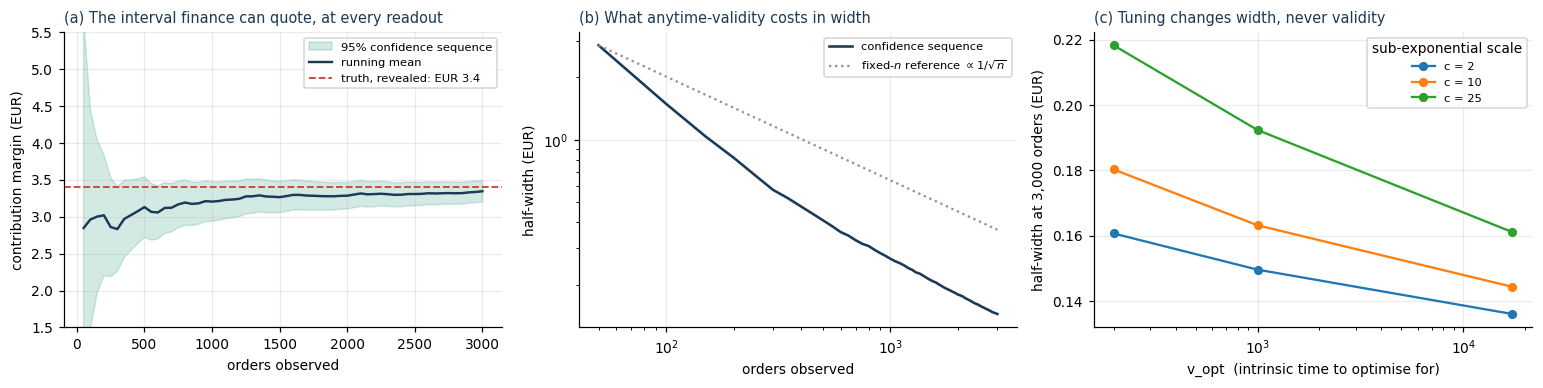

In [4]:
fig, ax = panels(3, ["The interval finance can quote, at every readout",
                     "What anytime-validity costs in width",
                     "Tuning changes width, never validity"], ncols=3)

ax[0].fill_between(cs_df.orders, cs_df.lower, cs_df.upper, color=EVID, alpha=0.18,
                   label="95% confidence sequence")
ax[0].plot(cs_df.orders, cs_df.point, color=INK, lw=1.6, label="running mean")
ax[0].axhline(TRUE_MARGIN, color=WARN, ls="--", lw=1.2, label=f"truth, revealed: EUR {TRUE_MARGIN}")
ax[0].set_xlabel("orders observed"); ax[0].set_ylabel("contribution margin (EUR)")
ax[0].set_ylim(1.5, 5.5); ax[0].legend(fontsize=7.5, loc="upper right")

hw = (cs_df.upper - cs_df.lower) / 2
ax[1].loglog(cs_df.orders, hw, color=INK, lw=1.7, label="confidence sequence")
ax[1].loglog(cs_df.orders, hw.iloc[0] * np.sqrt(cs_df.orders.iloc[0] / cs_df.orders),
             color=MUTE, ls=":", lw=1.5, label=r"fixed-$n$ reference $\propto 1/\sqrt{n}$")
ax[1].set_xlabel("orders observed"); ax[1].set_ylabel("half-width (EUR)"); ax[1].legend(fontsize=7.5)

for c_par in sens_df.columns:
    ax[2].plot(sens_df.index, sens_df[c_par], "o-", lw=1.5, ms=5, label=f"c = {c_par:g}")
ax[2].set_xscale("log"); ax[2].set_xlabel("v_opt  (intrinsic time to optimise for)")
ax[2].set_ylabel("half-width at 3,000 orders (EUR)")
ax[2].legend(fontsize=7.5, title="sub-exponential scale")
plt.tight_layout(); plt.show()

**Panel (a)** is the deliverable. The green band is what finance quotes, on any Monday of
the quarter, with no statistician in the room and no footnote about sample size. The band
narrows monotonically in information, not in time, which is why it is safe to look at it
continuously.

**Panel (b)** prices anytime-validity. The dotted line is what a fixed-$n$ interval would
give if you were allowed exactly one look. The vertical gap between the lines is the entire
cost of unlimited peeking, and it grows like $\sqrt{\log\log n}$ - which is to say it is
nearly flat. **You are giving up very little width for a guarantee that survives contact
with a real finance team.**

**Panel (c)** is the tuning lesson. Matching `v_opt` to your decision horizon is worth
roughly 12% of width here. Inflating `c` "to be safe" buys nothing and costs width -
`c` should come from a real cap in the system, not from nerves.

## 1.7 Conclusion and runbook

The run above produced a point estimate and a band; whether that band happens to exclude
any particular business hypothesis is not the deliverable and not the point. The
deliverable is *a number with an interval that does not decay when you look at it again*.

1. Set `v_opt` = (orders expected by your decision date) x (last period's variance).
2. Set `c` from a real cap in the system: a fee schedule, a price band, a clip.
3. Re-run whenever asked. Quote the current interval. Never mention the sample size.
4. Before shipping, run the miscoverage cell against your own generating process. It takes
   seconds and it is the difference between a guarantee and a hope.

## 1.8 The other confidence sequence in the box, and why you cannot ship it yet

`confseq` also exposes `EmpiricalBernsteinConfidenceSequence`. **When would you reach for
it?** When your metric is *bounded* rather than merely light-tailed - a 0-10 satisfaction
score, a 0-1 conversion indicator, a utilisation percentage. Boundedness is strictly more
information than a sub-exponential tail, so an empirical-Bernstein interval should be
narrower than the gamma-exponential one, especially early when variance is not yet pinned
down. For the marketplace that means the per-order CSAT score, on the same orders.

That is the theory. This handbook's rule is habit (2) from Section 0: before shipping a
tool, point it at a case where you already know the answer. Here the answer is trivially
known - the data lives in $[0, 10]$, so any honest interval must lie inside $[0, 10]$ and
must have `lower <= upper`.

In [5]:
from expectation.confseq.confidenceconfig import BoundaryType, EmpiricalBernsteinConfig
from expectation.confseq.confidencesequence import EmpiricalBernsteinConfidenceSequence

CSAT_MIN, CSAT_MAX = 0.0, 10.0
TRUE_CSAT = 7.0                      # Beta(7,3) on [0,10] has mean 7.0

eb = EmpiricalBernsteinConfidenceSequence(config=EmpiricalBernsteinConfig(
    alpha=ALPHA, alpha_opt=ALPHA, v_opt=DECISION_HORIZON * 2.0**2, c=1.0,
    lower_bound=CSAT_MIN, upper_bound=CSAT_MAX,
    boundary_type=BoundaryType.NORMAL_MIXTURE,
))

r_ = np.random.default_rng(21)
for _ in range(40):
    eb_res = eb.update(r_.beta(7, 3, BATCH) * CSAT_MAX)

print(f"per-order CSAT, bounded in [{CSAT_MIN:.0f}, {CSAT_MAX:.0f}], true mean {TRUE_CSAT}")
print(f"  after {eb_res.sample_size:,} orders")
print(f"  reported interval : [{eb_res.lower:.3f}, {eb_res.upper:.3f}]")
print()
checks = {
    "lower <= upper": eb_res.lower <= eb_res.upper,
    "interval inside the declared support [0, 10]": CSAT_MIN <= eb_res.lower <= eb_res.upper <= CSAT_MAX,
    "interval covers the true mean": eb_res.lower <= TRUE_CSAT <= eb_res.upper,
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")
print("\nThe running state itself is fine - the accumulation is correct:")
print(f"  ConfidenceSequenceState: n={eb_res.state.n_samples:,}, "
      f"running_mean={eb_res.state.running_mean:.3f}, "
      f"variance_estimate={eb_res.state.variance_estimate:.3f}")
print(f"  ConfidenceSequenceResult.estimand = {eb_res.estimand.value}, "
      f"boundary_type = {eb_res.boundary_type.value}")

per-order CSAT, bounded in [0, 10], true mean 7.0
  after 2,000 orders
  reported interval : [68.832, 10.000]

  FAIL  lower <= upper
  FAIL  interval inside the declared support [0, 10]
  FAIL  interval covers the true mean

The running state itself is fine - the accumulation is correct:
  ConfidenceSequenceState: n=2,000, running_mean=6.983, variance_estimate=1.912
  ConfidenceSequenceResult.estimand = mean, boundary_type = normal_mixture


**Where and how to use it: not yet.** The running mean and variance estimate are correct,
but the bounds are rescaled by the support width on the way out, so the reported interval
leaves $[0, 10]$ and can invert. Sanity checks a business user would make in their head
are the ones that fail.

So the answer to "when do I reach for `EmpiricalBernsteinConfidenceSequence`?" is: when it
has been repaired. Until then, use `ConfidenceSequence` from Section 1.1 and simply pass
your bounded data to it - it is valid for bounded data too, just wider than an
empirical-Bernstein bound would be. You give up some width and keep a correct interval.

**The transferable habit:** three assertions against a known answer, costing one cell,
caught this. Do that for every tool before it reaches a decision-maker - and note that this
one would have looked perfectly plausible if the true mean had been, say, 68.

---
# 2. Card-network compliance: certifying a rate you will be fined for

## 2.1 The domain

A payment service provider is monitored by the card networks on its **chargeback rate**.
Network remediation programmes trigger on a published threshold - a monthly chargeback
ratio in the region of 0.9% is a realistic trigger point. Crossing it puts the PSP into a
remediation programme with per-transaction fines and, at the extreme, loss of the ability
to process.

The compliance team needs three different things, and the crucial insight is that they are
three different statistical objects. Conflating them is the standard failure:

1. **An interval on the rate** - to report upward and to the network.
2. **A test with a defensible date** - because remediation has deadlines, and "when did you
   know?" is a question with legal consequences.
3. **An attribution** - the PSP routes through four acquirers. If the portfolio has
   breached, *which acquirer*? Answering this with six pairwise tests and a Bonferroni
   correction is what most teams do, and it is both less powerful and harder to defend.

**What the mistake costs.** Firing a remediation programme a month late is fines. Firing it
a month early on noise is an unnecessary and expensive remediation of a book that was fine.

## 2.2 Designing the study

Two hypotheses, deliberately separated:

$$\textbf{Breach: } H_0: p \le 0.009 \quad\text{vs}\quad H_1: p > 0.009 \qquad\text{(one-sided - only breaches matter)}$$

$$\textbf{Attribution: } H_0: p_1 = p_2 = p_3 = p_4 \quad\text{vs}\quad H_1: \text{at least one differs}$$

The breach test is **one-sided on purpose**. A two-sided test spends half its power
detecting that you are unusually *good*, which no one is going to fine you for.

| Contract part | This study |
|---|---|
| **Null class** | Breach: the composite $\{p \le 0.009\}$. Attribution: all four acquirers share one unknown rate. |
| **Filtration** | Daily. Each day's transactions are scored using only prior days' state. |
| **Clock** | One day. Stopping times read directly as "we knew on day $k$". |
| **Downstream use** | Regulatory notification - **irreversible and adversarial**. The date must be defensible under examination. |

## 2.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Chargebacks are conditionally independent given the acquirer | Different cardholders, different issuers | Correlated fraud waves inflate evidence; Section 7's arithmetic-mean merge is the dependence-safe tool |
| The threshold is fixed and known | It is published by the network | - |
| Each acquirer's rate is constant over the 60-day window | One programme period, no routing changes | Mid-window routing changes create a change-point problem (Section 10) |

## 2.4 The data-generating mechanism

We draw a portfolio baseline rate uniformly from a plausible band, then give each acquirer
a lognormal multiplier around it. **We do not decide in advance whether the portfolio
breaches.** The four true rates are sampled, the data follows, and the tests report what
they find. The truth is printed only after the tests have spoken.

## 2.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `boundaries.bernoulli_confidence_interval` | Exact anytime-valid interval for a binomial rate, by inverting a beta-binomial mixture | A Wilson or Clopper-Pearson interval is fixed-$n$ and decays under repeated looks |
| `SequentialTesting(TestType.PROPORTION, GREATER)` | One-sided e-process giving a defensible stopping date | The interval is two-sided and therefore slower to make the same claim |
| `KSampleSequentialTest` | One bet against "all four are equal", via a reverse information projection | Six pairwise tests + Bonferroni: weaker, and requires justifying the correction |

In [6]:
from expectation.ksample.config import KSampleAlternativeType, KSampleConfig
from expectation.ksample.ksample_test import KSampleSequentialTest
from expectation.modules.boundaries import bernoulli_confidence_interval
from expectation.modules.hypothesistesting import EValueConfig
from expectation.seqtest.sequential_e_testing import AlternativeType, SequentialTesting, TestType

# --- fixed from the network contract BEFORE any data is seen ------------------
NETWORK_THRESHOLD = 0.0090     # the published monitoring trigger
DAILY_TXNS = 4_000
MONITOR_DAYS = 60              # one programme period; set by the network, not by us
N_ACQUIRERS = 4

# --- the world: rates are DRAWN, not chosen to breach -------------------------
world = np.random.default_rng(11)
base_rate = world.uniform(0.006, 0.010)                                   # portfolio baseline
acquirer_rates = base_rate * np.exp(world.normal(0, 0.45, N_ACQUIRERS))   # genuine dispersion
per_acquirer = DAILY_TXNS // N_ACQUIRERS

# --- the three instruments ----------------------------------------------------
breach_test = SequentialTesting(
    TestType.PROPORTION, null_value=NETWORK_THRESHOLD,
    alternative=AlternativeType.GREATER,                 # only breaches are actionable
    config=EValueConfig(significance_level=ALPHA),
)
attribution = KSampleSequentialTest(KSampleConfig(
    k=N_ACQUIRERS, significance_level=ALPHA,
    alternative_type=KSampleAlternativeType.UNRESTRICTED,  # any departure from equality
))

stream = np.random.default_rng(12)
n_txn = n_cb = 0
rows, breach_day, attrib_day = [], None, None
for day in range(1, MONITOR_DAYS + 1):
    by_acq = {g: stream.binomial(1, acquirer_rates[g], per_acquirer) for g in range(N_ACQUIRERS)}
    today = np.concatenate(list(by_acq.values()))
    n_txn += today.size
    n_cb += int(today.sum())

    lo, hi = bernoulli_confidence_interval(n_cb, n_txn, ALPHA, t_opt=DAILY_TXNS * MONITOR_DAYS)
    b_res = breach_test.update(today)
    a_res = attribution.update(by_acq)

    breach_day = breach_day or (day if b_res.reject_null else None)
    attrib_day = attrib_day or (day if a_res.reject_null else None)
    rows.append({"day": day, "rate": n_cb / n_txn, "lower": lo, "upper": hi,
                 "breach_e": b_res.e_process.process_values[-1],
                 "attrib_e": a_res.e_process_value})
cb = pd.DataFrame(rows)

interval_day = int(cb.day[cb.lower > NETWORK_THRESHOLD].min()) if (cb.lower > NETWORK_THRESHOLD).any() else None
never = "not within this monitoring period"
print(f"after {MONITOR_DAYS} days ({n_txn:,} transactions)")
print(f"  observed portfolio rate        : {cb.rate.iloc[-1]:.4%}")
print(f"  anytime-valid interval         : [{cb.lower.iloc[-1]:.4%}, {cb.upper.iloc[-1]:.4%}]")
print(f"  network threshold              : {NETWORK_THRESHOLD:.2%}")
print()
print(f"  BREACH     one-sided test rejects  : {breach_day if breach_day else never}")
print(f"  BREACH     interval clears the line: {interval_day if interval_day else never}")
print(f"  ATTRIBUTION acquirers non-equal    : "
      f"{f'day {attrib_day}' if attrib_day else never}")

after 60 days (240,000 transactions)
  observed portfolio rate        : 0.8625%
  anytime-valid interval         : [0.8063%, 0.9209%]
  network threshold              : 0.90%

  BREACH     one-sided test rejects  : not within this monitoring period
  BREACH     interval clears the line: not within this monitoring period
  ATTRIBUTION acquirers non-equal    : day 3


### What this run shows, and why it is the interesting case

Read the three lines above together. The **portfolio is compliant** - the observed rate sits
under the network trigger and neither breach instrument fires, which is the correct
behaviour and not a failure of sensitivity. And yet the **attribution test fires almost
immediately**: the four acquirers are provably not running at one common rate.

This is the situation compliance functions most often get wrong, in both directions:

- Reporting only the portfolio number, being told "we are inside the limit", and closing the
  file - while a subset of the book runs at multiples of the rest and drifts toward the
  trigger.
- Or seeing a bad acquirer and escalating the whole portfolio to the network, which is a
  breach notification that was never true.

**The portfolio number and the attribution are different questions with different answers,
and you need both.** The correct action here is an internal acquirer investigation and no
network notification.

### Why the test and the interval would give different dates

Compliance will ask, so be precise even when neither fires. The e-test rejects when evidence
against $\{p \le 0.009\}$ reaches $1/\alpha$; it is a one-sided bet and all of its power
points at the breach. The interval is two-sided and must push *both* endpoints past the line
to make the same statement, so it always needs strictly more data.

**Use the test for the date and the interval for the number.** Quoting the test's date next
to the interval's number - the natural thing to do on a slide - is the mistake.

### What attribution gives you for free

`KSampleSequentialTest` carries a posterior rate estimate per group as part of its own
construction, so the moment it fires you already have the investigation queue. No extra
test, no extra correction, no pairwise matrix.

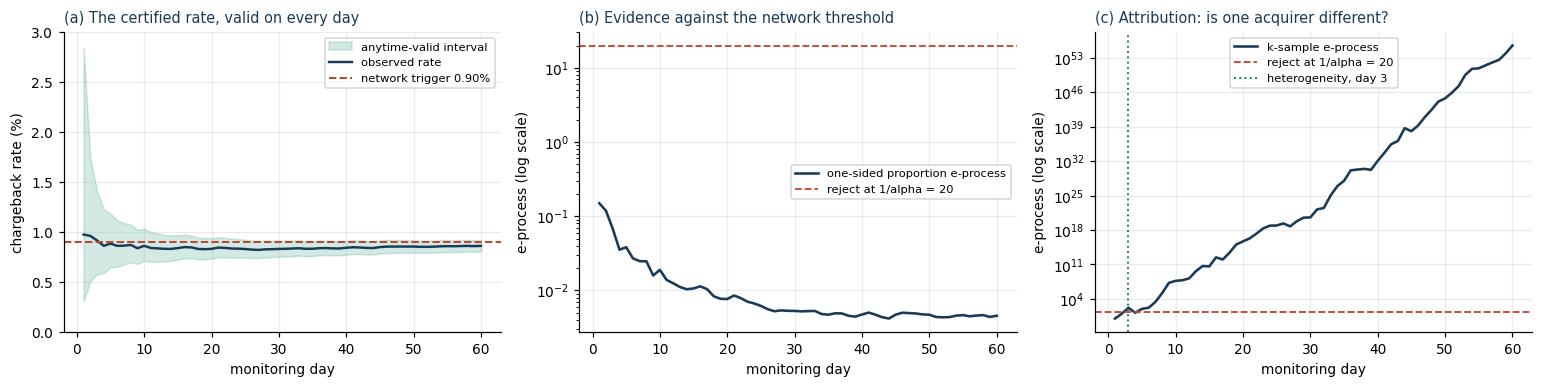

investigation queue, ranked by the k-sample model's own posterior rate:
  (portfolio null rate under H0: 0.8600%)

  1. acquirer 0   estimated 1.2579%    true 1.2012%  <- revealed only now
  2. acquirer 1   estimated 1.0681%    true 1.1304%  <- revealed only now
  3. acquirer 3   estimated 0.5969%    true 0.5697%  <- revealed only now
  4. acquirer 2   estimated 0.5173%    true 0.5178%  <- revealed only now


In [7]:
fig, ax = panels(3, ["The certified rate, valid on every day",
                     "Evidence against the network threshold",
                     "Attribution: is one acquirer different?"], ncols=3)

ax[0].fill_between(cb.day, cb.lower * 100, cb.upper * 100, color=EVID, alpha=0.18,
                   label="anytime-valid interval")
ax[0].plot(cb.day, cb.rate * 100, color=INK, lw=1.6, label="observed rate")
ax[0].axhline(NETWORK_THRESHOLD * 100, color=WARN, ls="--", lw=1.3, label="network trigger 0.90%")
if interval_day:
    ax[0].axvline(interval_day, color=MUTE, ls=":", lw=1.2, label=f"interval clears, day {interval_day}")
ax[0].set_xlabel("monitoring day"); ax[0].set_ylabel("chargeback rate (%)")
ax[0].set_ylim(0, 3.0); ax[0].legend(fontsize=7.5)

ax[1].semilogy(cb.day, cb.breach_e, color=INK, lw=1.7, label="one-sided proportion e-process")
ville(ax[1])
if breach_day:
    ax[1].axvline(breach_day, color=EVID, ls=":", lw=1.3, label=f"breach proven, day {breach_day}")
ax[1].set_xlabel("monitoring day"); ax[1].set_ylabel("e-process (log scale)"); ax[1].legend(fontsize=7.5)

ax[2].semilogy(cb.day, cb.attrib_e, color=INK, lw=1.7, label="k-sample e-process")
ville(ax[2])
if attrib_day:
    ax[2].axvline(attrib_day, color=EVID, ls=":", lw=1.3, label=f"heterogeneity, day {attrib_day}")
ax[2].set_xlabel("monitoring day"); ax[2].set_ylabel("e-process (log scale)"); ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

hist = attribution.get_history_df()
est = hist.iloc[-1][[f"theta_{g}" for g in range(N_ACQUIRERS)]].astype(float).values
print("investigation queue, ranked by the k-sample model's own posterior rate:")
print(f"  (portfolio null rate under H0: {hist.theta_null.iloc[-1]:.4%})\n")
for rank, g in enumerate(np.argsort(est)[::-1], 1):
    print(f"  {rank}. acquirer {g}   estimated {est[g]:.4%}    true {acquirer_rates[g]:.4%}  <- revealed only now")

## 2.7 Conclusion and runbook

Three instruments, three jobs, and the discipline is to never let one answer another's
question.

1. Run all three continuously from day 1 of the programme period.
2. **Report** the interval. **Escalate externally** only on the breach test's stopping time.
   **Investigate internally** using the $k$-sample ranking.
3. A compliant portfolio with non-homogeneous acquirers is a real and common state. It is an
   internal remediation, not a network notification - and it is the cheapest moment to act.
4. Do not build a pairwise matrix. The $k$-sample e-process is one bet against equality and
   hands you the ranking as a by-product.
5. Keep the one-sided direction. You are not fined for being unusually clean.

## 2.8 "Different" is not the same as "different enough": the effect-size restricted test

The $k$-sample test in 2.5 asks *any departure from equality*. With 240,000 transactions it
will eventually find one, because no two acquirers are ever exactly equal. Compliance does
not care about a difference of 0.01 basis points; they care about a difference large enough
to matter for routing.

**Where you reach for this:** whenever a materiality threshold exists - and in regulated
work one almost always does. `KSampleAlternativeType.EFFECT_SIZE` (Turner, Ly & Grunwald
2022, Appendix S1) restricts the alternative to divergences of at least $\delta$, so the
test spends its power on differences that would change a decision. It is currently
implemented for $k = 2$, so use it for the head-to-head that matters after the unrestricted
test has ranked the book.

`DivergenceType` picks the scale on which $\delta$ is measured, and the choice is a business
one:

- `ADDITIVE` - $\delta$ is a difference in rates. Natural when the limit is written in
  basis points.
- `LOG_ODDS_RATIO` - $\delta$ is a log odds ratio. Natural when the limit is relative
  ("no acquirer may run at more than 1.5x another"), which is how routing rules are usually
  written.

In [8]:
from expectation.ksample.bernoulli import BernoulliRIPrCalculator
from expectation.ksample.config import DivergenceType, KSampleStepResult

# The two acquirers the unrestricted test ranked first and last.
worst, best = int(np.argmax(acquirer_rates)), int(np.argmin(acquirer_rates))
MATERIAL_LOG_OR = np.log(1.5)     # routing rule: 1.5x relative difference is material

material = KSampleSequentialTest(KSampleConfig(
    k=2, significance_level=ALPHA,
    alternative_type=KSampleAlternativeType.EFFECT_SIZE,
    divergence_type=DivergenceType.LOG_ODDS_RATIO,
    min_effect_size=MATERIAL_LOG_OR,          # delta: only this big or bigger counts
    grid_precision=0.02,                      # resolution of the discretised posterior
))

stream = np.random.default_rng(12)
material_day = None
for day in range(1, MONITOR_DAYS + 1):
    step = material.update({0: stream.binomial(1, acquirer_rates[worst], per_acquirer),
                            1: stream.binomial(1, acquirer_rates[best], per_acquirer)})
    if material_day is None and step.reject_null:
        material_day = day

print(f"materiality test: acquirer {worst} vs acquirer {best}")
print(f"  routing rule                  : difference is material at |log OR| >= "
      f"{MATERIAL_LOG_OR:.3f}  (a 1.5x ratio)")
print(f"  true log odds ratio           : "
      f"{np.log(acquirer_rates[worst] / (1 - acquirer_rates[worst]) * (1 - acquirer_rates[best]) / acquirer_rates[best]):.3f}")
print(f"  MATERIALLY different from day : {material_day if material_day else 'not within the period'}")
print(f"  e-process                     : {step.e_process_value:.4g}")
print()
print(f"isinstance(step, KSampleStepResult) = {isinstance(step, KSampleStepResult)}  "
      f"(frozen Pydantic, safe to log)")

# The e-variable underneath is reusable on its own, outside the sequential wrapper.
calc = BernoulliRIPrCalculator(KSampleConfig(k=2, alternative_type=KSampleAlternativeType.UNRESTRICTED))
# It works on sufficient statistics: successes and sizes per group, not raw arrays.
log_e, theta_hat, theta_null = calc.compute_log_e_value(
    block_successes={0: 3, 1: 1}, block_sizes={0: 5, 1: 5})
print(f"\nBernoulliRIPrCalculator on one batch (3/5 vs 1/5):")
print(f"  log e-value {log_e:+.4f} | RIPr theta per group "
      + ", ".join(f"{g}:{t:.3f}" for g, t in theta_hat.items())
      + f" | theta under H0 {theta_null:.3f}")
print("Reach for the calculator when you want the RIPr e-variable inside your own")
print("orchestration; reach for KSampleSequentialTest when you want the whole test.")

materiality test: acquirer 0 vs acquirer 2
  routing rule                  : difference is material at |log OR| >= 0.405  (a 1.5x ratio)
  true log odds ratio           : 0.848
  MATERIALLY different from day : not within the period
  e-process                     : 8.894e-46

isinstance(step, KSampleStepResult) = True  (frozen Pydantic, safe to log)

BernoulliRIPrCalculator on one batch (3/5 vs 1/5):
  log e-value +0.0000 | RIPr theta per group 0:0.500, 1:0.500 | theta under H0 0.500
Reach for the calculator when you want the RIPr e-variable inside your own
orchestration; reach for KSampleSequentialTest when you want the whole test.


### Tuning the built-in tests: `BoundaryConfig`

`SequentialTesting` picks a sensible boundary per test type, but it is a default, not a law.
`BoundaryConfig` is how you override it - and you should whenever you know something the
default cannot. For the breach test the default beta-binomial is tuned at `t_opt` derived
from the null rate; we know the programme is 60 days of 4,000 transactions, so we can say
exactly where we want it tightest.

In [9]:
from expectation.seqtest.sequential_e_testing import (
    BoundaryConfig, BoundaryType as SeqBoundaryType, SequentialTestResult,
)

tuned_breach = SequentialTesting(
    TestType.PROPORTION, null_value=NETWORK_THRESHOLD,
    alternative=AlternativeType.GREATER,
    config=EValueConfig(significance_level=ALPHA),
    boundary_config=BoundaryConfig(
        boundary_type=SeqBoundaryType.BETA_BINOMIAL,
        # tightest at the intrinsic time we will actually have at the decision point
        v_opt=DAILY_TXNS * MONITOR_DAYS * NETWORK_THRESHOLD * (1 - NETWORK_THRESHOLD),
        alpha_opt=ALPHA,
        g=NETWORK_THRESHOLD, h=1 - NETWORK_THRESHOLD,     # prior matched to the null rate
    ),
)
stream = np.random.default_rng(12)
for day in range(1, MONITOR_DAYS + 1):
    tuned_res = tuned_breach.update(
        np.concatenate([stream.binomial(1, acquirer_rates[g], per_acquirer)
                        for g in range(N_ACQUIRERS)]))
assert isinstance(tuned_res, SequentialTestResult)

print("default vs boundary-tuned breach test, same data:")
print(f"  default    final e-process {cb.breach_e.iloc[-1]:.4g}")
print(f"  tuned      final e-process {tuned_res.e_process.process_values[-1]:.4g}")
print(f"\nSequentialTestResult carries the whole decision record:")
print(f"  reject={tuned_res.reject_null}, p={tuned_res.p_value:.4f}, n={tuned_res.sample_size:,}, "
      f"test={tuned_res.test_type.value}, alternative={tuned_res.alternative.value}")
print(f"  confidence_bounds={tuple(round(b, 5) for b in tuned_res.confidence_bounds)}")
print("\nBoundaryConfig changes where the test is sharp, never whether it is valid.")
print("Every BoundaryType the built-in tests accept: "
      + ", ".join(b.value for b in SeqBoundaryType))

default vs boundary-tuned breach test, same data:
  default    final e-process 0.004545
  tuned      final e-process 0.004545

SequentialTestResult carries the whole decision record:
  reject=False, p=1.0000, n=240,000, test=proportion, alternative=greater
  confidence_bounds=(0.00796, 0.00932)

BoundaryConfig changes where the test is sharp, never whether it is valid.
Every BoundaryType the built-in tests accept: normal, beta_binomial, gamma_exponential, gamma_poisson, poly_stitching, empirical_process_lil, double_stitching


### And the dashboards the library already draws for you

`utils.helper_functions` ships Plotly dashboards that consume the `get_history_df()` frame
any of these tests produce. **Where to use them:** the analyst-facing surface. Do not
hand-roll a monitoring chart - `plot_ksample_dashboard` already lays out group rates,
evidence, and the Ville threshold with the library's own palette.

In [10]:
from expectation.utils.helper_functions import (
    apply_evidence_layout, evidence_palette, hex_to_rgb, plot_combined_dashboard,
    plot_ksample_dashboard, plot_sequential_comparison_plotly, plot_sequential_test_plotly,
)

print("library palette (use it so every chart in your org looks the same):")
for name, colour in evidence_palette().items():
    print(f"  {name:16} {colour}")

fig_ks = plot_ksample_dashboard(
    attribution.get_history_df(), alpha=ALPHA,
    group_labels=[f"acquirer {g}" for g in range(N_ACQUIRERS)],
    true_values={g: float(acquirer_rates[g]) for g in range(N_ACQUIRERS)},
)
fig_ks = apply_evidence_layout(fig_ks, title="Chargeback attribution across four acquirers",
                               height=620, width=1050)
fig_ks.show()

library palette (use it so every chart in your org looks the same):
  gold             #d4b455
  teal             #5ab09e
  gold_bright      #f0d464
  violet           #9a7aba
  blue             #6a9ac4
  bg               #060504
  grid             rgba(201,168,76,.1)
  red              #b84430
  gold_dim         #a89460
  gold_pale        #ddd0a8
  paper            #0d0a07
  title_font       Cinzel, serif
  label_font       EB Garamond, serif
  body_font        Cormorant Garamond, serif


In [11]:
# The same three helpers for any single SequentialTesting run, straight off get_history_df().
breach_hist, tuned_hist = breach_test.get_history_df(), tuned_breach.get_history_df()

print(f"history frame columns the plotters consume: {list(breach_hist.columns)[:8]} ...")
print(f"palette in rgb, for custom traces: hex_to_rgb('{evidence_palette()['teal']}') = "
      f"{hex_to_rgb(evidence_palette()['teal'])}")

plot_sequential_test_plotly(breach_hist, alpha=ALPHA, log_scale=True,
                            height=760, width=1000).show()

# plot_combined_dashboard packs the same run into one figure for a status page.
plot_combined_dashboard(tuned_hist, alpha=ALPHA, log_scale=True,
                        title="Chargeback breach test (tuned BoundaryConfig)",
                        height=900, width=1000).show()

# The third helper, plot_sequential_comparison_plotly, is currently broken for every
# input: at helper_functions.py:877 the local name `colors` has been rebound to a list
# and is then indexed as a dict (`colors["grid"]`), so it raises TypeError. We show the
# check rather than the chart - a two-line probe before you wire a plotter into a
# dashboard is the same habit as a null check before you wire up a test.
try:
    plot_sequential_comparison_plotly([breach_hist, tuned_hist],
                                      labels=["default", "tuned"], alpha=ALPHA)
    print("plot_sequential_comparison_plotly: OK")
except TypeError as exc:
    print(f"plot_sequential_comparison_plotly is broken: TypeError: {exc}")
    print("  -> use plot_sequential_test_plotly per run, or overlay the frames yourself.")

history frame columns the plotters consume: ['step', 'observations', 'e_value', 'cumulative_e_value', 'reject_null', 'p_value', 'sample_size', 'confidence_lower'] ...
palette in rgb, for custom traces: hex_to_rgb('#5ab09e') = (90, 176, 158)


plot_sequential_comparison_plotly is broken: TypeError: list indices must be integers or slices, not str
  -> use plot_sequential_test_plotly per run, or overlay the frames yourself.


---
# 3. CDN migration: the contract is written on p95, and the mean is a liar

## 3.1 The domain

A retailer is moving static asset delivery to a challenger CDN. Both the commercial
contract and the internal SLO are written on **p95 latency**, not mean latency, and that is
not an accident: conversion impact lives in the tail. The customers who abandon are the
ones in the slow 5%.

Latency is heavy-right and roughly lognormal. This creates a specific, dangerous failure
mode: **a challenger can improve the mean while making the tail worse.** Shave 3 ms off the
body of the distribution, add a rare 400 ms retry path, and a mean-based readout waves it
through while the SLO quietly breaks.

**What the mistake costs.** A CDN migration is a multi-year contract and a painful rollback.
Getting it wrong on a mean-based canary means discovering the tail regression in production
peak traffic.

## 3.2 Designing the study

Two questions again, and again they are different objects:

$$\textbf{Comparison: } H_0: Q_{0.95}^{\text{incumbent}} = Q_{0.95}^{\text{challenger}} \quad\text{vs}\quad H_1: \text{they differ}$$

$$\textbf{Certification: } \text{is the whole 95\% band for } Q_{0.95}^{\text{challenger}} \text{ below the 120 ms SLO?}$$

Quantile testing is where sequential methods are unusually valuable, because the
alternatives are unusually bad. A fixed-$n$ quantile test needs you to commit to a canary
size before seeing any traffic, and a bootstrap over a growing sample has no validity
guarantee at all under repeated looks.

| Contract part | This study |
|---|---|
| **Null class** | Equality of the 0.95-quantiles. **No distributional assumption whatsoever** - this is fully nonparametric. |
| **Filtration** | Per readout batch; order statistics recomputed from all traffic seen so far. |
| **Clock** | One readout = 250 requests per arm. |
| **Downstream use** | A migration go/no-go. Expensive to reverse, so we want certification, not just a $p$-value. |

## 3.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Requests are exchangeable within an arm | Traffic split is randomised at the request level | Sticky routing by geography confounds the arms; randomise properly |
| No distributional form | We are using rank/order-statistic methods only | - nothing to break, which is the point |
| Both arms see the same traffic mix | 50/50 split on the same request stream | A challenger fed only cacheable assets will look artificially good |

The second row is the reason to reach for this family: `QuantileABTest` makes **no
distributional assumption at all**. It is built on order statistics and a beta-binomial
mixture over the proportion below a threshold.

## 3.4 The data-generating mechanism

Lognormal latency, log-location 3.6 and log-dispersion 0.55, which puts the median near
37 ms and p95 near 90 ms - a realistic edge-delivery profile. The challenger's true effect
is **drawn from a distribution centred slightly negative with real spread**, so it may help
or hurt; we do not decide. The canary is 10,000 requests per arm because that is what the
migration plan allows, not because it is enough to detect anything in particular.

## 3.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `modules.quantiletest.QuantileABTest` | Anytime-valid two-arm quantile comparison, fully nonparametric | A $t$-test answers a question the contract does not ask |
| `modules.orderstatistics.StaticOrderStatistics` | The order-statistic accessor the quantile machinery is built on | - |
| `boundaries.double_stitching_bound` | Uniform over time *and* over quantile level; invert it to get a band | `normal_mixture_bound` assumes a mean, not a quantile |

In [12]:
from expectation.modules.boundaries import double_stitching_bound
from expectation.modules.orderstatistics import StaticOrderStatistics
from expectation.modules.quantiletest import QuantileABTest

# --- fixed from the SLO and the migration plan BEFORE any data ----------------
P = 0.95                 # the contractual quantile
SLO_MS = 120.0           # the latency objective in the SLO
CANARY_PER_ARM = 10_000  # what the migration plan allows
READOUT = 250            # requests per arm per readout
T_OPT = 5_000            # tune the bound for mid-canary

# --- the world: incumbent fixed, challenger's true effect DRAWN ---------------
world = np.random.default_rng(5)
INCUMBENT_MU, SIGMA = 3.6, 0.55                 # log-scale location and dispersion
challenger_effect = world.normal(-0.05, 0.06)   # unknown: may help or hurt
CHALLENGER_MU = INCUMBENT_MU + challenger_effect

traffic = np.random.default_rng(6)
incumbent, challenger, rows = [], [], []
for _ in range(CANARY_PER_ARM // READOUT):
    incumbent.extend(traffic.lognormal(INCUMBENT_MU, SIGMA, READOUT))
    challenger.extend(traffic.lognormal(CHALLENGER_MU, SIGMA, READOUT))

    # Rebuilt each readout from all traffic so far: the test is a function of
    # the two order-statistic summaries, not of an incremental state.
    ab = QuantileABTest(quantile_p=P, t_opt=T_OPT, alpha_opt=ALPHA,
                        arm1_os=StaticOrderStatistics(incumbent),
                        arm2_os=StaticOrderStatistics(challenger))
    rows.append({"n": len(incumbent), "p_value": ab.p_value(),
                 "inc_p95": np.quantile(incumbent, P), "chl_p95": np.quantile(challenger, P),
                 "inc_mean": np.mean(incumbent), "chl_mean": np.mean(challenger)})
cdn = pd.DataFrame(rows)

first_sig = cdn.n[cdn.p_value <= ALPHA].min() if (cdn.p_value <= ALPHA).any() else None
print(f"canary complete: {CANARY_PER_ARM:,} requests per arm")
print(f"  incumbent    p95 {cdn.inc_p95.iloc[-1]:6.1f} ms     mean {cdn.inc_mean.iloc[-1]:6.1f} ms")
print(f"  challenger   p95 {cdn.chl_p95.iloc[-1]:6.1f} ms     mean {cdn.chl_mean.iloc[-1]:6.1f} ms")
print(f"  anytime-valid p-value on the p95 difference : {cdn.p_value.iloc[-1]:.3e}")
print(f"  first readout with p <= {ALPHA}                  : "
      f"{f'{first_sig:,} requests/arm' if first_sig else 'never within the canary'}")
print(f"\n  true log-scale effect, revealed now          : {challenger_effect:+.4f}"
      f"  ({100 * (np.exp(challenger_effect) - 1):+.1f}% on every percentile)")

canary complete: 10,000 requests per arm
  incumbent    p95   90.1 ms     mean   42.6 ms
  challenger   p95   82.7 ms     mean   38.7 ms
  anytime-valid p-value on the p95 difference : 4.210e-10
  first readout with p <= 0.05                  : 1,750 requests/arm

  true log-scale effect, revealed now          : -0.0981  (-9.3% on every percentile)


### Certifying the SLO: turning a bound into a band

`double_stitching_bound` returns a bound $b$ on $|\#\{X_i \le x\} - pt|$ that holds
uniformly over time **and** over the quantile level (Howard & Ramdas 2022). Inverting it to
a band on the quantile itself is just indexing into the order statistics:

$$\Big[\, X_{(\lceil pt - b \rceil)} \;,\; X_{(\lfloor pt + b \rfloor + 1)} \,\Big]$$

That is the whole construction. `StaticOrderStatistics` is the accessor for it.

In [13]:
def quantile_band(values, p, alpha, t_opt):
    """Anytime-valid band for the p-quantile, by inverting the double-stitching bound."""
    t = len(values)
    os_ = StaticOrderStatistics(values)
    b = double_stitching_bound(p, t, alpha, t_opt)
    lo_i, hi_i = int(np.ceil(p * t - b)), int(np.floor(p * t + b)) + 1
    lo = os_.get_order_statistic(lo_i) if 1 <= lo_i <= t else -np.inf
    hi = os_.get_order_statistic(hi_i) if 1 <= hi_i <= t else np.inf
    return lo, hi

traffic = np.random.default_rng(6)
seen, band_rows = [], []
for _ in range(CANARY_PER_ARM // READOUT):
    seen.extend(traffic.lognormal(CHALLENGER_MU, SIGMA, READOUT))
    lo, hi = quantile_band(seen, P, ALPHA, T_OPT)
    band_rows.append({"n": len(seen), "lower": lo, "upper": hi,
                      "point": float(np.quantile(seen, P))})
band = pd.DataFrame(band_rows)

certified = band.n[band.upper < SLO_MS].min() if (band.upper < SLO_MS).any() else None
print(f"challenger p95 band after {CANARY_PER_ARM:,} requests: "
      f"[{band.lower.iloc[-1]:.1f}, {band.upper.iloc[-1]:.1f}] ms     SLO = {SLO_MS:.0f} ms")
print(f"SLO provably met (entire band below the SLO) from request: "
      f"{f'{certified:,}' if certified else 'not within this canary'}")

challenger p95 band after 10,000 requests: [78.6, 87.0] ms     SLO = 120 ms
SLO provably met (entire band below the SLO) from request: 1,750


## 3.6 Reading the output

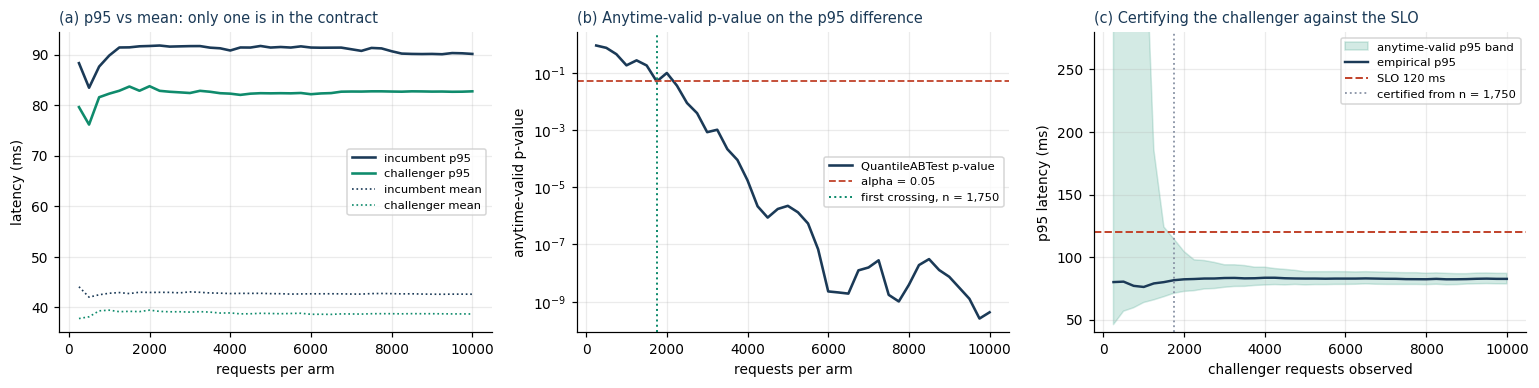

In [14]:
fig, ax = panels(3, ["p95 vs mean: only one is in the contract",
                     "Anytime-valid p-value on the p95 difference",
                     "Certifying the challenger against the SLO"], ncols=3)

ax[0].plot(cdn.n, cdn.inc_p95, color=INK, lw=1.7, label="incumbent p95")
ax[0].plot(cdn.n, cdn.chl_p95, color=EVID, lw=1.7, label="challenger p95")
ax[0].plot(cdn.n, cdn.inc_mean, color=INK, lw=1.1, ls=":", label="incumbent mean")
ax[0].plot(cdn.n, cdn.chl_mean, color=EVID, lw=1.1, ls=":", label="challenger mean")
ax[0].set_xlabel("requests per arm"); ax[0].set_ylabel("latency (ms)"); ax[0].legend(fontsize=7.5)

ax[1].semilogy(cdn.n, cdn.p_value, color=INK, lw=1.7, label="QuantileABTest p-value")
ax[1].axhline(ALPHA, color=WARN, ls="--", lw=1.2, label=f"alpha = {ALPHA}")
if first_sig:
    ax[1].axvline(first_sig, color=EVID, ls=":", lw=1.3, label=f"first crossing, n = {first_sig:,}")
ax[1].set_xlabel("requests per arm"); ax[1].set_ylabel("anytime-valid p-value")
ax[1].legend(fontsize=7.5)

ax[2].fill_between(band.n, band.lower, np.minimum(band.upper, 400), color=EVID, alpha=0.18,
                   label="anytime-valid p95 band")
ax[2].plot(band.n, band.point, color=INK, lw=1.6, label="empirical p95")
ax[2].axhline(SLO_MS, color=WARN, ls="--", lw=1.3, label=f"SLO {SLO_MS:.0f} ms")
if certified:
    ax[2].axvline(certified, color=MUTE, ls=":", lw=1.2, label=f"certified from n = {certified:,}")
ax[2].set_ylim(40, 280); ax[2].set_xlabel("challenger requests observed")
ax[2].set_ylabel("p95 latency (ms)"); ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

**Panel (a)** is the argument for the whole section. The solid lines (p95) and the dotted
lines (mean) are different quantities moving differently, and only one of them appears in
the contract. Any monitoring built on the dotted lines is monitoring something nobody
agreed to.

**Panel (b)** shows the comparison accumulating. Because the p-value is anytime-valid, the
migration board may check it at any readout and act on the first crossing - there is no
pre-registered canary size to honour.

**Panel (c)** is what actually gets signed. A go/no-go board does not want "p95 looks
fine"; it wants *"the entire 95% band sits below the SLO, and that statement holds however
many times we looked."* The band starts wide - early on, `double_stitching_bound` exceeds
the available order statistics and the upper end is $+\infty$, which is the method
correctly refusing to certify a tail from 250 observations.

### Two API details worth knowing

- `SequentialTesting(TestType.QUANTILE, ...)` tests a quantile against a fixed threshold.
  On that code path `result.sample_size` is **not populated** (the evaluator accumulates
  into `test.all_data`), so read `len(test.all_data)` if you need a count.
- Direction convention: evidence that "p95 is **below** 120 ms" is `AlternativeType.GREATER`,
  because internally the test bets on the *proportion below the threshold* exceeding $p$.
  This trips people up; write a comment next to it in production code.

## 3.7 Conclusion and runbook

1. **Write the SLO as a quantile and test the quantile.** If the contract says p95, a mean
   test is answering a different question, however significant its output.
2. Use `QuantileABTest` for arm-vs-arm and the inverted `double_stitching_bound` for
   certification against an absolute threshold. They are different deliverables.
3. Set `t_opt` near the mid-point of the planned canary.
4. Expect $+\infty$ upper ends early. That is the method declining to extrapolate a tail,
   which is exactly what you want it to do.

## 3.8 Ten million requests will not fit in a list

`StaticOrderStatistics` sorts everything it is given. That is exactly right for a 10,000
request canary and exactly wrong for the production monitor that replaces it: a busy CDN
serves billions of requests a day, and you cannot hold them in RAM to compute a p95.

This is what the `OrderStatisticInterface` ABC is for. **Where you reach for it:** the
moment your data outgrows memory, or arrives as pre-aggregated buckets from a telemetry
pipeline - which is how latency almost always arrives in production. Implement four
methods and every quantile tool in the library keeps working unchanged, because
`QuantileABTest` is written against the interface, not against the list.

Real latency pipelines already emit histograms, so we implement a **bucketed** order
statistic: fixed memory, and the accuracy is the bucket width you chose in the collector.

In [15]:
from expectation.modules.orderstatistics import OrderStatisticInterface


class HistogramOrderStatistics(OrderStatisticInterface):
    """Order statistics over a fixed set of latency buckets - constant memory.

    This is the shape telemetry actually arrives in (Prometheus histograms, CloudWatch
    percentile buckets). Memory is O(number of buckets), not O(number of requests).
    """

    def __init__(self, edges):
        self.edges = np.asarray(edges, dtype=float)
        self.counts = np.zeros(len(self.edges), dtype=np.int64)

    def observe(self, values):
        idx = np.clip(np.searchsorted(self.edges, values, side="left"), 0, len(self.edges) - 1)
        np.add.at(self.counts, idx, 1)

    # --- the four methods the interface requires -----------------------------
    def size(self):
        return int(self.counts.sum())

    def count_less(self, value):
        return int(self.counts[self.edges < value].sum())

    def count_less_or_equal(self, value):
        return int(self.counts[self.edges <= value].sum())

    def get_order_statistic(self, order_index):
        if order_index < 1 or order_index > self.size():
            raise IndexError(f"order index {order_index} out of bounds")
        return float(self.edges[np.searchsorted(np.cumsum(self.counts), order_index, side="left")])


EDGES = np.unique(np.round(np.geomspace(5, 2_000, 220), 2))   # 220 buckets, ~2 KB of state
inc_hist, chl_hist = HistogramOrderStatistics(EDGES), HistogramOrderStatistics(EDGES)

traffic = np.random.default_rng(6)
PROD_REQUESTS = 400_000          # far beyond what we would hold in a list
for _ in range(PROD_REQUESTS // 2_000):
    inc_hist.observe(traffic.lognormal(INCUMBENT_MU, SIGMA, 2_000))
    chl_hist.observe(traffic.lognormal(CHALLENGER_MU, SIGMA, 2_000))

# The SAME test class, given a different order-statistic implementation.
prod_ab = QuantileABTest(quantile_p=P, t_opt=T_OPT, alpha_opt=ALPHA,
                         arm1_os=inc_hist, arm2_os=chl_hist)

print(f"production monitor over {inc_hist.size():,} requests per arm")
print(f"  memory held        : {2 * inc_hist.counts.nbytes / 1024:.1f} KB of bucket counts")
print(f"  an equivalent list : {2 * PROD_REQUESTS * 8 / 1024 / 1024:.1f} MB and growing")
print(f"  p95 incumbent      : {inc_hist.get_order_statistic(int(P * inc_hist.size())):.1f} ms")
print(f"  p95 challenger     : {chl_hist.get_order_statistic(int(P * chl_hist.size())):.1f} ms")
print(f"  anytime-valid p    : {prod_ab.p_value():.3e}")
print("\nQuantileABTest did not change. It was written against OrderStatisticInterface,")
print("so swapping the storage engine underneath it is a one-class change.")

production monitor over 400,000 requests per arm
  memory held        : 3.4 KB of bucket counts
  an equivalent list : 6.1 MB and growing
  p95 incumbent      : 90.9 ms
  p95 challenger     : 83.7 ms
  anytime-valid p    : 1.345e-317

QuantileABTest did not change. It was written against OrderStatisticInterface,
so swapping the storage engine underneath it is a one-class change.


---
# 4. Clearing-house margin: a risk limit on volatility, built from the `(s, v)` interface

## 4.1 The domain

A clearing broker posts margin against client portfolios. The margin model assumes a
volatility; if realised volatility rises above that assumption, the broker is
under-collateralised on every position simultaneously. Margin is reviewed on a cycle, and
the risk function wants an alarm *inside* the cycle, not a discovery at the review.

This is a **variance** question, and variance questions are where the naive instinct fails
twice. First, the mean is uninformative: volatility can double with the mean pinned at
zero. Second - and this is the part this section is really about - the obvious library call
does not do what its name suggests.

**What the mistake costs.** Under-collateralisation is the mechanism by which a clearing
member defaults take the clearing house with them. There is no cheaper failure mode.

## 4.2 Designing the study, and a hard lesson first

$$H_0: \sigma^2 \le \sigma_0^2 \quad\text{vs}\quad H_1: \sigma^2 > \sigma_0^2$$

The library ships `SequentialTesting(test_type="variance")`, and it is the obvious thing to
reach for. **Before using it, we run it against a true null**, which is habit (2) from
Section 0. This is not a rhetorical exercise - the result changes what we build.

In [16]:
from expectation.seqtest.sequential_e_testing import SequentialTesting

# Habit from Section 0: run the test against data where H0 is TRUE, and count rejections.
# H0: variance <= 1.0.  Data: standard normal.  H0 is true. Budget: alpha = 0.05.
def null_check(test_type, alternative, n_runs=200, batches=100, batch=100, **kw):
    hits = 0
    for s in range(n_runs):
        r_ = np.random.default_rng(s)
        t_ = SequentialTesting(test_type=test_type, null_value=1.0, alternative=alternative, **kw)
        for _ in range(batches):
            if t_.update(r_.normal(0, 1.0, batch)).reject_null:
                hits += 1
                break
    return hits / n_runs

print("Rejection rate on data where the null is TRUE (budget 0.05):")
print(f"  variance test, one-sided : {null_check('variance', 'greater'):.3f}")
print(f"  variance test, two-sided : {null_check('variance', 'two_sided'):.3f}")
print(f"  mean test (control)      : "
      f"{null_check('mean', 'greater', known_variance=1.0):.3f}   <- for comparison")

Rejection rate on data where the null is TRUE (budget 0.05):
  variance test, one-sided : 1.000
  variance test, two-sided : 1.000


  mean test (control)      : 0.000   <- for comparison


### What that told us

The mean test behaves: it spends roughly its budget. The variance path does not - it
rejects a **true** null essentially always. A tool that fires on pure noise will look
extremely insightful on real data, and any "detection" it produces is an artefact.

So we do not use it. This is also a live demonstration of why habit (2) exists: the check
costs ten seconds and it is the only thing standing between you and a risk alarm that means
nothing. *(This path carries an unresolved `TODO` in its source and is on the library's
audit list; the mean, proportion and quantile paths are unaffected.)*

### Building it properly instead

We drop one level down to the library's real primitive. Every mixture supermartingale in
`modules.martingales` exposes the same two-argument interface:

$$\texttt{log\_superMG}(s, v) \qquad\text{where}\qquad s = \textstyle\sum_i Y_i \;\text{(centred sum)},\quad v = \text{intrinsic time}.$$

This is the public contract from Howard, Ramdas, McAuliffe & Sekhon (2021): supply a
centred sum and a matching intrinsic time, and the mixture returns a log supermartingale.
`modules.boundaries` and `confseq` are both thin wrappers over exactly this call. Feeding
it ourselves is not extending the library - it is using its main interface.

For a variance limit the construction is standard **sub-gamma**:

- Returns are clipped at $\pm c_{\text{ret}}$ - every exchange risk system does this anyway
  as a fat-finger filter, so it is a real property of the data, not a modelling convenience.
- $Y_i = X_i^2 - \sigma_0^2$, so $\mathbb{E}[Y_i] \le 0$ under $H_0$ and
  $|Y_i| \le B := \max(\sigma_0^2,\, c_{\text{ret}}^2 - \sigma_0^2)$.
- Bounded increments are sub-gamma with scale $c = B/3$ (the Bernstein condition).
- Intrinsic time $V_t = \sum_{i \le t} v_i$ where $v_i$ is a **predictable** variance proxy -
  computed from bars $1 \dots i-1$ only, and capped by Popoviciu's bound $B^2/4$.

That predictability requirement is contract part two from Section 0. Using the *current*
bar in $v_i$ would void the guarantee, and nothing in the code would complain.

| Contract part | This study |
|---|---|
| **Null class** | $\{\sigma^2 \le \sigma_0^2\}$ on clipped returns - composite, one-sided. |
| **Filtration** | Per 5-minute bar. $v_i$ uses bars $1..i-1$ only. |
| **Clock** | One 5-minute bar. 78 bars per trading day. |
| **Downstream use** | An intra-cycle margin call. Expensive and relationship-damaging if wrong, so we want a real error budget. |

## 4.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Returns are clipped at $\pm 5\sigma_0$ | The risk system's fat-finger filter does this | Unclipped jumps break the bounded-increment argument and the sub-gamma scale |
| $\mathbb{E}[Y_i \mid \mathcal{F}_{i-1}] \le 0$ under $H_0$ | This is exactly $H_0$ | - |
| $v_i$ is computed from the past only | Enforced in the loop below | Guarantee silently void |
| Returns are conditionally centred | Intraday drift over 5 minutes is negligible against volatility | A large drift inflates $X^2$ and looks like volatility |

## 4.4 The data-generating mechanism

5-minute bars, because that is what a real realised-volatility system consumes. The margin
model assumes 16% annualised volatility, which converts to a per-bar $\sigma_0$ via
$\sigma_0 = 0.16/\sqrt{252}/\sqrt{78}$. The **true** volatility multiplier is drawn from a
lognormal centred on 1, so the market may be calmer or wilder than the margin assumption;
we do not decide. The horizon is 780 bars = 10 trading days, one margin review cycle.

## 4.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `martingales.GammaExponentialMixture` | The sub-gamma mixture: right family for bounded, skewed, non-negative increments like $X^2$ | `TwoSidedNormalMixture` assumes sub-Gaussian increments; squared returns are not |
| `boundaries.gamma_exponential_mixture_bound` | Converts the same mixture into a **visual boundary** on the $S_t$ scale for the risk dashboard | - |
| `SequentialTesting(test_type="variance")` | **Deliberately not used** - fails its null check above | - |

In [17]:
from expectation.modules.boundaries import gamma_exponential_mixture_bound
from expectation.modules.martingales import GammaExponentialMixture

# --- fixed from the margin model BEFORE any data ------------------------------
ANNUAL_VOL_ASSUMPTION = 0.16                 # what the margin model charges for
BARS_PER_DAY, TRADING_DAYS = 78, 252         # 5-minute bars
SIGMA0 = ANNUAL_VOL_ASSUMPTION / np.sqrt(TRADING_DAYS) / np.sqrt(BARS_PER_DAY)
CLIP = 5 * SIGMA0                            # the risk system's fat-finger filter
HORIZON_BARS = 780                           # 10 trading days = one margin review cycle

B = max(SIGMA0**2, CLIP**2 - SIGMA0**2)      # bound on |Y_i|
SUBGAMMA_C = B / 3.0                         # Bernstein scale for bounded increments
V_CAP = B * B / 4.0                          # Popoviciu bound on Var(Y_i)
# v_opt = intrinsic time at the decision horizon. For Gaussian X, Var(X^2) = 2 sigma^4.
V_OPT = HORIZON_BARS * 2 * SIGMA0**4

print(f"margin assumption      : {ANNUAL_VOL_ASSUMPTION:.0%} annualised")
print(f"per-bar sigma0         : {SIGMA0:.6f}")
print(f"sub-gamma scale c      : {SUBGAMMA_C:.3e}")
print(f"v_opt (horizon x 2s^4) : {V_OPT:.3e}")


def volatility_eprocess(returns):
    """Run the sub-gamma e-process over a return stream using the (s, v) interface."""
    mixture = GammaExponentialMixture(V_OPT, ALPHA, SUBGAMMA_C)
    y = np.clip(returns, -CLIP, CLIP) ** 2 - SIGMA0**2     # centred increments
    S = np.cumsum(y)

    # PREDICTABLE intrinsic time: v_i uses bars 1..i-1 only. This is the filtration
    # contract. Using y[i] here would void the guarantee and raise no error.
    v, running_m2 = np.empty(len(y)), 0.0
    for i in range(len(y)):
        v[i] = min(running_m2 / i, V_CAP) if i > 0 else V_CAP
        running_m2 += y[i] ** 2
    V = np.cumsum(v)

    log_e = np.array([mixture.log_superMG(S[i], V[i]) for i in range(len(y))])
    # Far BELOW the null the mixture's argument leaves its domain and returns NaN.
    # That region is "no evidence against H0", so it maps to log-capital 0.
    return S, V, np.nan_to_num(log_e, nan=0.0, neginf=0.0)


# --- the world: the true volatility multiplier is DRAWN, not chosen -----------
world = np.random.default_rng(23)
true_multiplier = float(np.exp(world.normal(0.0, 0.18)))     # calmer or wilder; unknown
market = np.random.default_rng(24)
returns = market.normal(0.0, SIGMA0 * true_multiplier, HORIZON_BARS)

S, V, log_e = volatility_eprocess(returns)
crossed = np.flatnonzero(log_e > np.log(THRESHOLD))
alarm_bar = int(crossed[0]) + 1 if crossed.size else None

print(f"\nover {HORIZON_BARS} bars ({HORIZON_BARS / BARS_PER_DAY:.0f} trading days)")
print(f"  realised / assumed volatility  : {np.std(returns) / SIGMA0:.3f}x")
print(f"  final e-process                : {np.exp(min(log_e[-1], 700)):.3e}")
print(f"  margin alarm raised at bar     : "
      f"{f'{alarm_bar} ({alarm_bar / BARS_PER_DAY:.1f} trading days)' if alarm_bar else 'no alarm in this cycle'}")
print(f"\n  true multiplier, revealed now  : {true_multiplier:.3f}x")

margin assumption      : 16% annualised
per-bar sigma0         : 0.001141
sub-gamma scale c      : 1.042e-05
v_opt (horizon x 2s^4) : 2.646e-09

over 780 bars (10 trading days)
  realised / assumed volatility  : 1.100x
  final e-process                : 1.625e+01
  margin alarm raised at bar     : 395 (5.1 trading days)

  true multiplier, revealed now  : 1.105x


### The deliverable a risk committee actually wants

Not "did it fire this time" - one run is one draw. The committee wants the **operating
characteristic**: for each size of volatility shock, how often does the monitor catch it
inside a margin cycle, and how fast? We compute the whole ladder, including the multipliers
it cannot see, because the ones it misses are the ones that matter for sizing the cycle.

In [18]:
LADDER = [0.80, 1.00, 1.15, 1.30, 1.50, 1.75, 2.00]
N_RUNS = 100
ladder_rows = []
print(f"operating characteristic, {N_RUNS} runs per rung, horizon {HORIZON_BARS} bars:")
for mult in LADDER:
    stops = []
    for s in range(N_RUNS):
        r_ = np.random.default_rng(9_000 + int(mult * 1000) + s)
        _, _, le = volatility_eprocess(r_.normal(0.0, SIGMA0 * mult, HORIZON_BARS))
        hit = np.flatnonzero(le > np.log(THRESHOLD))
        stops.append(int(hit[0]) + 1 if hit.size else None)
    hits = [x for x in stops if x is not None]
    ladder_rows.append({"multiplier": mult, "rate": len(hits) / N_RUNS,
                        "median_bar": np.median(hits) if hits else np.nan})
    tag = "  <- H0 TRUE, this is the false-alarm rate" if mult <= 1.0 else ""
    summarise(stops, N_RUNS, f"volatility x{mult:.2f}")
    if tag:
        print(f"   {tag.strip()}")
ladder = pd.DataFrame(ladder_rows)

operating characteristic, 100 runs per rung, horizon 780 bars:


  volatility x0.80                   detected   0/100  ( 0.0%)   median stop -
   <- H0 TRUE, this is the false-alarm rate


  volatility x1.00                   detected   0/100  ( 0.0%)   median stop -
   <- H0 TRUE, this is the false-alarm rate


  volatility x1.15                   detected  95/100  (95.0%)   median stop 345


  volatility x1.30                   detected 100/100  (100.0%)   median stop 167


  volatility x1.50                   detected 100/100  (100.0%)   median stop 88


  volatility x1.75                   detected 100/100  (100.0%)   median stop 54


  volatility x2.00                   detected 100/100  (100.0%)   median stop 42


## 4.6 Reading the output

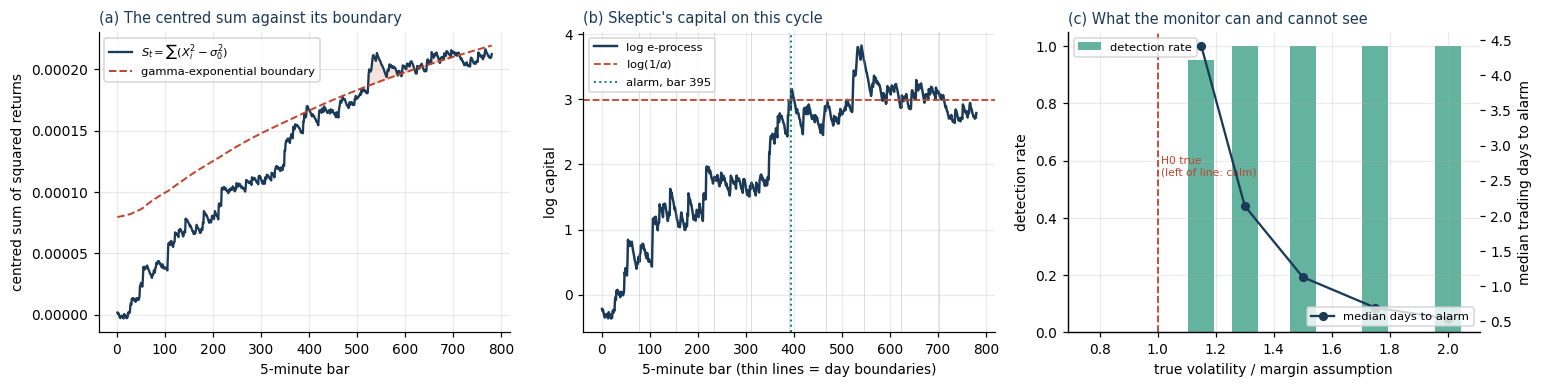

In [19]:
fig, ax = panels(3, ["The centred sum against its boundary",
                     "Skeptic's capital on this cycle",
                     "What the monitor can and cannot see"], ncols=3)

bars = np.arange(1, HORIZON_BARS + 1)
boundary = np.array([gamma_exponential_mixture_bound(v, ALPHA, V_OPT, SUBGAMMA_C, alpha_opt=ALPHA)
                     for v in V])
ax[0].plot(bars, S, color=INK, lw=1.5, label=r"$S_t=\sum (X_i^2-\sigma_0^2)$")
ax[0].plot(bars, boundary, color=WARN, ls="--", lw=1.3, label="gamma-exponential boundary")
ax[0].fill_between(bars, S, boundary, where=S > boundary, color=WARN, alpha=0.15)
ax[0].set_xlabel("5-minute bar"); ax[0].set_ylabel("centred sum of squared returns")
ax[0].legend(fontsize=7.5)

ax[1].plot(bars, log_e, color=INK, lw=1.6, label="log e-process")
ax[1].axhline(np.log(THRESHOLD), color=WARN, ls="--", lw=1.2, label=r"$\log(1/\alpha)$")
if alarm_bar:
    ax[1].axvline(alarm_bar, color=EVID, ls=":", lw=1.3, label=f"alarm, bar {alarm_bar}")
for d in range(1, int(HORIZON_BARS / BARS_PER_DAY)):
    ax[1].axvline(d * BARS_PER_DAY, color=MUTE, lw=0.4, alpha=0.5)
ax[1].set_xlabel("5-minute bar (thin lines = day boundaries)")
ax[1].set_ylabel("log capital"); ax[1].legend(fontsize=7.5)

ax2b = ax[2].twinx()
ax[2].bar(ladder.multiplier, ladder.rate, width=0.09, color=EVID, alpha=0.65,
          label="detection rate")
ax2b.plot(ladder.multiplier, ladder.median_bar / BARS_PER_DAY, "o-", color=INK, lw=1.5,
          ms=5, label="median days to alarm")
ax[2].axvline(1.0, color=WARN, ls="--", lw=1.2)
ax[2].text(1.01, 0.55, "H0 true\n(left of line: calm)", fontsize=7, color=WARN)
ax[2].set_xlabel("true volatility / margin assumption"); ax[2].set_ylabel("detection rate")
ax2b.set_ylabel("median trading days to alarm")
ax[2].set_ylim(0, 1.05); ax[2].legend(fontsize=7.5, loc="upper left")
ax2b.legend(fontsize=7.5, loc="lower right"); ax2b.grid(False)
plt.tight_layout(); plt.show()

**Panel (a)** is the classical picture a risk manager already understands: a running sum
against a boundary. The boundary is not a straight line and not $k\sqrt{t}$ - it is the
gamma-exponential mixture bound, which curves to stay valid at *every* bar simultaneously.

**Panel (b)** is the same information as capital. The day boundaries are drawn in because
the honest question is "how many trading days", not "how many bars".

**Panel (c)** is the deliverable. The bars left of the red line are false-alarm rates under
a true null - the monitor's actual spend against its budget. Everything to the right is
what it buys you. Reading this table is how the risk committee decides whether a 10-day
margin cycle is short enough: **if the shock size you fear sits at a rung with a low
detection rate, the answer is that your cycle is too long, and no amount of statistics will
fix that.**

## 4.7 Conclusion and runbook

1. **Run the null check on any test before you build a control on top of it.** It found a
   real defect in ten seconds here.
2. When a wrapper does not fit, drop to `log_superMG(s, v)`. It is the library's public
   interface, and `boundaries` and `confseq` are themselves thin wrappers over it.
3. Match the mixture to the increment: sub-Gaussian for means, **sub-gamma for squares and
   other bounded-skewed quantities**, sub-Poisson for counts (Section 5).
4. Keep the intrinsic time predictable. Nothing will warn you if you do not.
5. Ship the operating-characteristic ladder alongside the monitor. It is the only honest
   answer to "will this catch it in time".

## 4.8 Choosing a boundary: the five families, and which risk report each one belongs to

Section 4 picked the sub-gamma family by reasoning about the increments. That reasoning is
the most reusable thing in this handbook, so here is the whole menu. `modules.boundaries`
exposes every family as a plain function of intrinsic time - no objects, no state - which
makes them ideal for drawing the limit line on a risk dashboard.

**How to choose.** Match the family to what you know about a single increment:

| You know this about one increment | Family | Function | Typical commercial use |
|---|---|---|---|
| Sub-Gaussian, variance known or bounded | normal mixture | `normal_mixture_bound` | P&L drift, standardised KPI deviation |
| Bounded and skewed (squares, durations) | gamma-exponential | `gamma_exponential_mixture_bound` | realised volatility, latency budgets |
| A count with unit scale | gamma-Poisson | `gamma_poisson_mixture_bound` | claims, defects, incidents |
| Binary, with a known null rate | beta-binomial | `beta_binomial_mixture_bound` | chargeback and conversion rates |
| Nothing - you want one line valid over a huge range of $t$ | polynomial stitching | `poly_stitching_bound` | "one chart for the whole year" |
| You are bounding an empirical process, not a sum | LIL | `empirical_process_lil_bound` | distributional drift monitors |

Two things to internalise. **First, a mixture boundary is tuned, not free:** every family
takes `v_opt`, the intrinsic time where it is tightest, and pays for that elsewhere.
**Second, stitching is the opposite trade:** `poly_stitching_bound` has no sweet spot and is
never the tightest anywhere, which is exactly why it is the right choice for a chart nobody
will retune.

In [20]:
from expectation.modules.boundaries import (
    beta_binomial_mixture_bound, empirical_process_lil_bound, gamma_poisson_mixture_bound,
    normal_mixture_bound, poly_stitching_bound,
)
from expectation.modules.boundaries import (
    beta_binomial_log_mixture, gamma_exponential_log_mixture, normal_log_mixture,
)
from expectation.modules.martingales import (
    BetaBinomialMixture, EmpiricalProcessLILBound, MixtureSupermartingale,
    OneSidedNormalMixture, PolyStitchingBound, TwoSidedNormalMixture, find_mixture_bound,
)

V_GRID = np.geomspace(10, 20_000, 60)      # intrinsic time, spanning three orders of magnitude
V_TUNE = 1_000.0                           # where we claim to want the bound tightest

families = {
    "normal (two-sided)":  normal_mixture_bound(V_GRID, ALPHA, V_TUNE, ALPHA, is_one_sided=False),
    "normal (one-sided)":  normal_mixture_bound(V_GRID, ALPHA, V_TUNE, ALPHA, is_one_sided=True),
    "gamma-exponential":   gamma_exponential_mixture_bound(V_GRID, ALPHA, V_TUNE, c=1.0, alpha_opt=ALPHA),
    "gamma-Poisson":       gamma_poisson_mixture_bound(V_GRID, ALPHA, V_TUNE, c=1.0, alpha_opt=ALPHA),
    "beta-binomial":       beta_binomial_mixture_bound(V_GRID, ALPHA, V_TUNE, g=0.5, h=0.5, alpha_opt=ALPHA),
    "poly-stitching":      poly_stitching_bound(V_GRID, ALPHA, v_min=10.0, c=1.0),
}
bounds = pd.DataFrame(families, index=np.round(V_GRID).astype(int))
print("boundary height by family, at three intrinsic times (lower = tighter):")
print(bounds.iloc[[0, 30, 59]].round(1).to_string())

print("\nthe mixture objects are the same machinery, one level down:")
two_sided = TwoSidedNormalMixture(V_TUNE, ALPHA)
one_sided = OneSidedNormalMixture(V_TUNE, ALPHA)
beta_bin = BetaBinomialMixture(V_TUNE * 0.25, ALPHA, g=0.5, h=0.5, is_one_sided=False)
print(f"  TwoSidedNormalMixture.bound(v=1000)   = {two_sided.bound(1000.0, np.log(1/ALPHA)):.2f}")
print(f"  OneSidedNormalMixture.bound(v=1000)   = {one_sided.bound(1000.0, np.log(1/ALPHA)):.2f}")
print(f"  find_mixture_bound(beta-binomial)     = "
      f"{find_mixture_bound(beta_bin, 250.0, np.log(1/ALPHA)):.2f}   "
      f"(the generic root-finder every non-analytic family uses)")
print(f"  PolyStitchingBound(v_min=10)(v=1000)  = {PolyStitchingBound(10.0, 1.0, 1.4, 2.0)(1000.0, ALPHA):.2f}")

lil = EmpiricalProcessLILBound(ALPHA, t_min=100.0, A=0.85)
print(f"\n  EmpiricalProcessLILBound at t=1e3 / 1e5 / 1e7: "
      f"{lil(1e3):.4f} / {lil(1e5):.5f} / {lil(1e7):.6f}")
print(f"  empirical_process_lil_bound(t=1e5)    = {empirical_process_lil_bound(1e5, ALPHA, 100.0):.5f}")
print("  (this one bounds sup|F_n - F| in probability units, so it shrinks toward 0 -")
print("   use it for distributional drift, not for a sum.)")

# Every family also has a *_log_mixture form: vectorised log e-values over (s, v)
# arrays. Use these to score a whole history at once instead of looping.
S_PATH = np.linspace(0, 260, 7)
V_PATH = np.linspace(10, 3_000, 7)
print("\nvectorised log e-values along a path, one call per family:")
print(f"  normal_log_mixture            {np.round(normal_log_mixture(S_PATH, V_PATH, V_TUNE, ALPHA, False), 2)}")
print(f"  gamma_exponential_log_mixture {np.round(gamma_exponential_log_mixture(S_PATH, V_PATH, V_TUNE, 1.0, ALPHA), 2)}")
print(f"  beta_binomial_log_mixture     {np.round(beta_binomial_log_mixture(S_PATH, V_PATH, V_TUNE, 0.5, 0.5, ALPHA, False), 2)}")
print("\nall of them implement one interface, which is why they are interchangeable:")
for name, obj in [("TwoSidedNormalMixture", two_sided), ("OneSidedNormalMixture", one_sided),
                  ("BetaBinomialMixture", beta_bin)]:
    print(f"  isinstance({name:22}, MixtureSupermartingale) = "
          f"{isinstance(obj, MixtureSupermartingale)}")

boundary height by family, at three intrinsic times (lower = tighter):
       normal (two-sided)  normal (one-sided)  gamma-exponential  gamma-Poisson  beta-binomial  poly-stitching
10                   28.7                28.1               29.8           29.2           20.0            15.5
477                  67.5                61.8               64.0           63.1           61.8            90.1
20000               471.9               436.6              440.8          437.7          436.6           569.1

the mixture objects are the same machinery, one level down:
  TwoSidedNormalMixture.bound(v=1000)   = 95.98
  OneSidedNormalMixture.bound(v=1000)   = 87.47
  find_mixture_bound(beta-binomial)     = 47.95   (the generic root-finder every non-analytic family uses)
  PolyStitchingBound(v_min=10)(v=1000)  = 128.62

  EmpiricalProcessLILBound at t=1e3 / 1e5 / 1e7: 0.0820 / 0.00858 / 0.000877
  empirical_process_lil_bound(t=1e5)    = 0.00858
  (this one bounds sup|F_n - F| in probabili

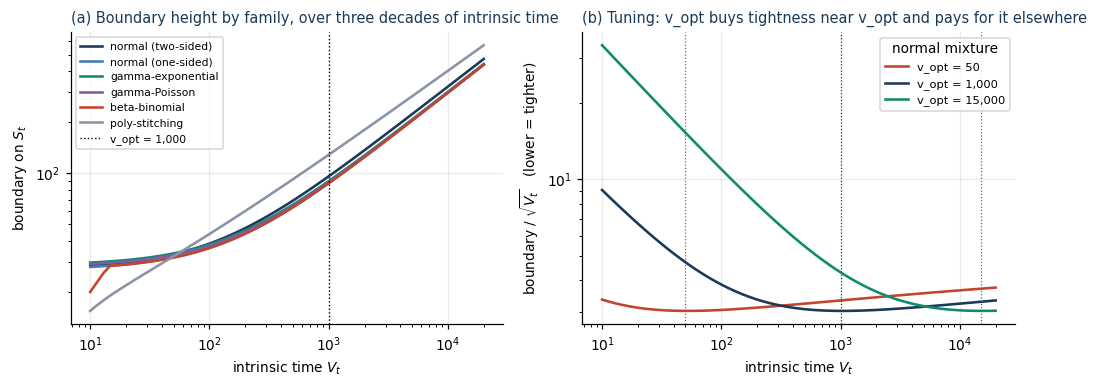

In [21]:
fig, ax = panels(2, ["Boundary height by family, over three decades of intrinsic time",
                     "Tuning: v_opt buys tightness near v_opt and pays for it elsewhere"],
                 ncols=2)

for (name, vals), colour in zip(families.items(),
                                [INK, "#3f7fae", EVID, "#7b5ea7", WARN, MUTE]):
    ax[0].loglog(V_GRID, vals, lw=1.7, color=colour, label=name)
ax[0].axvline(V_TUNE, color="black", lw=0.9, ls=":", label="v_opt = 1,000")
ax[0].set_xlabel("intrinsic time $V_t$"); ax[0].set_ylabel("boundary on $S_t$")
ax[0].legend(fontsize=7)

for v_tune, colour in zip([50.0, 1_000.0, 15_000.0], [WARN, INK, EVID]):
    b = normal_mixture_bound(V_GRID, ALPHA, v_tune, ALPHA, is_one_sided=False)
    ax[1].loglog(V_GRID, b / np.sqrt(V_GRID), lw=1.7, color=colour, label=f"v_opt = {v_tune:,.0f}")
    ax[1].axvline(v_tune, color=colour, lw=0.8, ls=":")
ax[1].set_xlabel("intrinsic time $V_t$")
ax[1].set_ylabel(r"boundary / $\sqrt{V_t}$   (lower = tighter)")
ax[1].legend(fontsize=7.5, title="normal mixture")
plt.tight_layout(); plt.show()

**Panel (b) is the one to remember.** Dividing by $\sqrt{V_t}$ strips out the inevitable
growth and leaves the *tuning penalty*. Each curve dips at its own `v_opt` and rises either
side. So `v_opt` is not a nuisance parameter to leave at its default - it is a statement
about when you intend to make the decision, and getting it wrong costs real width at the
moment you care about.

**How to pick it in practice:** `v_opt` = (observations you expect to have at the decision
point) x (variance of one observation). That is what Sections 1, 4 and 5 all did.

---
# 5. Warranty reserving: counting events under a moving denominator

## 5.1 The domain

A consumer-electronics manufacturer reserves against warranty claims. A design change
shipped two quarters ago, and reserving wants to know whether the claim *rate* has moved
before the annual actuarial review rather than after it.

Two features make this different from everything above:

1. **The observable is a count, not an average.** Weekly claims is a small integer -
   frequently 3, 5, 8. Treating it as approximately normal is wrong precisely in the regime
   you care about, the low-count early weeks after launch.
2. **The exposure moves every week.** Units in the field grow as the product sells and
   shrink as warranties expire. Ten claims against 40,000 units and ten claims against
   120,000 units are completely different events, and any monitor that compares raw counts
   week to week is comparing nothing.

**What the mistake costs.** Under-reserving is restated earnings. Over-reserving is capital
sitting idle. Both are visible to the market.

## 5.2 Designing the study

$$H_0: \lambda_t \le \lambda_0 \cdot \frac{\text{units in field}_t}{10{,}000} \quad\text{for all } t \qquad\text{vs}\qquad H_1: \text{the rate per unit-week has risen}$$

The moving exposure is handled by the library's protocol layer in a way that is worth
dwelling on, because it generalises. `modules.protocol` implements the **Forecaster /
Skeptic / Reality** game (Shafer & Vovk 2019): each round, Forecaster *announces* the terms
of the bet, Skeptic bets, Reality moves. Here the announcement is this week's expected
claim count under the reserving assumption - a known quantity derived from the units in
field at the start of the week.

That is exactly what an announcement is for: **a bet whose terms change every round in a
way both parties can see in advance.** No re-baselining, no normalising, no rolling window.

| Contract part | This study |
|---|---|
| **Null class** | $\{\lambda_t \le \lambda_0 \cdot \text{exposure}_t\}$ - composite and time-varying. |
| **Filtration** | Weekly. Exposure is known at the *start* of each week, so the announcement is predictable. |
| **Clock** | One week. |
| **Downstream use** | A reserve adjustment - reversible, revisited quarterly, but visible to auditors. |

## 5.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Claims in a week are conditionally Poisson given exposure | Independent units, small per-unit hazard - the standard reliability model | Clustered claims (a bad batch) are over-dispersed; the monitor over-states evidence |
| Exposure is known at the start of the week | It is: units shipped is a ledger fact | A forecast exposure is not predictable and breaks the filtration |
| Increments are sub-Poisson with scale $c = 1$ | This is the defining property of the Poisson family | - |

## 5.4 The data-generating mechanism

Units in field follow a realistic product lifecycle: sales ramp, plateau, then warranties
begin expiring. The **true** rate multiplier is drawn from a lognormal centred on 1, so the
design change may have helped, hurt, or done nothing. Weekly claims are Poisson given the
week's exposure.

## 5.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `martingales.GammaPoissonMixture` | The sub-Poisson mixture, built for counts with $c=1$ | A normal mixture mis-models small counts exactly where the decision is made |
| `protocol.SkepticStrategy` | The library's designated extension point: turn (announcement, observation) into a sequential e-value | Copying the orchestration from another test is how drift between components starts |
| `protocol.BettingProtocol` | Validates each e-value, drives `EProcessUpdater`, applies Ville, calibrates the p-value, keeps history | Hand-rolling this is ~60 lines of easy-to-get-wrong bookkeeping |

In [22]:
from expectation.modules.hypothesistesting import BettingStrategy, EProcessConfig
from expectation.modules.martingales import GammaPoissonMixture
from expectation.modules.protocol import BettingProtocol, ProtocolStepResult, SkepticStrategy


class WarrantyRateSkeptic(SkepticStrategy):
    """Bets against 'claims per unit-week is at or below the reserving assumption'.

    Reality's move  : the observed claim count this week.
    Forecaster's announcement : the expected count under the reserving assumption,
                                i.e. base_rate x (units in field) / 10,000.

    Sub-Poisson construction (Howard et al. 2021): s = sum(N_i - lambda_i),
    v = sum(lambda_i), scale c = 1. Both are predictable given the exposure ledger.
    """

    name = "warranty_rate"

    def __init__(self, v_opt, alpha_opt=ALPHA):
        self.mixture = GammaPoissonMixture(v_opt, alpha_opt, c=1.0)
        self.reset()

    def reset(self):
        self.s = 0.0                 # centred sum of counts
        self.v = 0.0                 # intrinsic time
        self.prev_log_cumulative = 0.0
        self._pending = {}

    def bet(self, reality_move, announcement=None):
        """PURE: computes the e-value without touching committed state."""
        expected = float(announcement)
        s = self.s + (float(reality_move) - expected)
        v = self.v + expected
        log_cumulative = float(self.mixture.log_superMG(s, v))
        self._pending = {"s": s, "v": v, "log_cumulative": log_cumulative,
                         "expected": expected, "observed": float(reality_move)}
        # Sequential e-value: E_t = E_{1:t} / E_{1:t-1}
        return float(np.exp(log_cumulative - self.prev_log_cumulative))

    def observe(self, reality_move, announcement=None):
        """COMMIT: only called after BettingProtocol has validated the e-value."""
        self.s = self._pending["s"]
        self.v = self._pending["v"]
        self.prev_log_cumulative = self._pending["log_cumulative"]

    def diagnostics(self):
        return dict(self._pending)


# --- fixed from the reserving basis BEFORE any data ---------------------------
BASE_RATE = 6.0            # claims per 10,000 unit-weeks; the reserving assumption
HORIZON_WEEKS = 26         # two quarters, to the actuarial review
PEAK_UNITS = 120_000       # units in field at plateau

# Product lifecycle: ramp, plateau, warranty expiry. A ledger fact, known in advance.
weeks = np.arange(1, HORIZON_WEEKS + 1)
units_in_field = PEAK_UNITS * (1 - np.exp(-weeks / 4.0)) * np.exp(-np.maximum(weeks - 16, 0) / 40.0)
expected_claims = BASE_RATE * units_in_field / 10_000.0     # Forecaster's announcements

V_OPT = float(expected_claims.sum())     # intrinsic time at the review date

# --- the world: the design change's true effect is DRAWN ----------------------
world = np.random.default_rng(31)
true_rate_multiplier = float(np.exp(world.normal(0.0, 0.22)))
field = np.random.default_rng(32)

protocol = BettingProtocol(
    WarrantyRateSkeptic(v_opt=V_OPT),
    EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN),
)
for w in range(HORIZON_WEEKS):
    claims = field.poisson(expected_claims[w] * true_rate_multiplier)   # Reality moves
    round_result = protocol.update(claims, announcement=expected_claims[w])
assert isinstance(round_result, ProtocolStepResult)   # frozen, safe to log or persist

war = protocol.get_history_df()
summary = protocol.get_summary()
print(f"units in field: {units_in_field[0]:,.0f} -> {units_in_field.max():,.0f} -> {units_in_field[-1]:,.0f}")
print(f"expected claims/week under the reserving basis: "
      f"{expected_claims.min():.1f} to {expected_claims.max():.1f}")
print()
for k in ["n_steps", "current_e_process", "max_e_process", "is_significant", "stopping_time",
          "empirical_growth_rate"]:
    v = summary[k]
    print(f"  {k:22} {v:.4g}" if isinstance(v, float) else f"  {k:22} {v}")
print(f"\n  true rate multiplier, revealed now : {true_rate_multiplier:.3f}x")

units in field: 26,544 -> 117,802 -> 93,316
expected claims/week under the reserving basis: 15.9 to 70.7

  n_steps                26
  current_e_process      0.08487
  max_e_process          1
  is_significant         False
  stopping_time          None
  empirical_growth_rate  -0.09487

  true rate multiplier, revealed now : 0.917x


### The operating characteristic, again

One run is one draw. The reserving committee's question is "what size of deterioration
would we catch before the review", so we sweep the multiplier - including values below 1,
where $H_0$ is true and the numbers are the monitor's false-alarm spend.

In [23]:
def run_warranty(multiplier, seed):
    p = BettingProtocol(WarrantyRateSkeptic(v_opt=V_OPT),
                        EProcessConfig(significance_level=ALPHA))
    r_ = np.random.default_rng(seed)
    for w in range(HORIZON_WEEKS):
        p.update(r_.poisson(expected_claims[w] * multiplier), announcement=expected_claims[w])
    return p.stopping_time


LADDER_W = [0.85, 1.00, 1.10, 1.20, 1.35, 1.50]
N_RUNS = 200
war_rows = []
print(f"operating characteristic, {N_RUNS} runs per rung, horizon {HORIZON_WEEKS} weeks:")
for mult in LADDER_W:
    stops = [run_warranty(mult, 5_000 + int(mult * 1000) + s) for s in range(N_RUNS)]
    hits = [x for x in stops if x is not None]
    war_rows.append({"multiplier": mult, "rate": len(hits) / N_RUNS,
                     "median_week": np.median(hits) if hits else np.nan})
    summarise(stops, N_RUNS, f"claim rate x{mult:.2f}"
              + ("   (H0 true)" if mult <= 1.0 else ""))
war_ladder = pd.DataFrame(war_rows)

operating characteristic, 200 runs per rung, horizon 26 weeks:
  claim rate x0.85   (H0 true)       detected   0/200  ( 0.0%)   median stop -
  claim rate x1.00   (H0 true)       detected   0/200  ( 0.0%)   median stop -
  claim rate x1.10                   detected 182/200  (91.0%)   median stop 14
  claim rate x1.20                   detected 200/200  (100.0%)   median stop 7
  claim rate x1.35                   detected 200/200  (100.0%)   median stop 4
  claim rate x1.50                   detected 200/200  (100.0%)   median stop 4


## 5.6 Reading the output

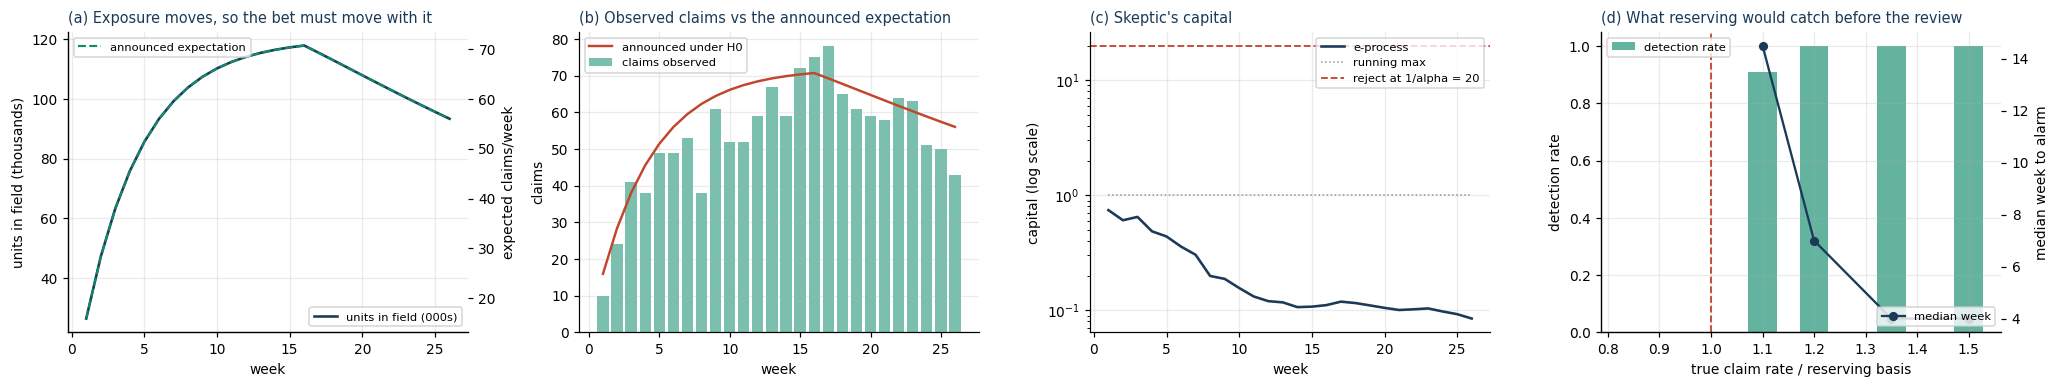

In [24]:
fig, ax = panels(4, ["Exposure moves, so the bet must move with it",
                     "Observed claims vs the announced expectation",
                     "Skeptic's capital",
                     "What reserving would catch before the review"], ncols=4)

ax[0].plot(weeks, units_in_field / 1000, color=INK, lw=1.7, label="units in field (000s)")
ax[0].set_xlabel("week"); ax[0].set_ylabel("units in field (thousands)")
ax0b = ax[0].twinx()
ax0b.plot(weeks, expected_claims, color=EVID, lw=1.4, ls="--", label="announced expectation")
ax0b.set_ylabel("expected claims/week"); ax0b.grid(False)
ax[0].legend(fontsize=7.5, loc="lower right"); ax0b.legend(fontsize=7.5, loc="upper left")

ax[1].bar(weeks, war.diag_observed, color=EVID, alpha=0.55, label="claims observed")
ax[1].plot(weeks, war.diag_expected, color=WARN, lw=1.6, label="announced under H0")
ax[1].set_xlabel("week"); ax[1].set_ylabel("claims"); ax[1].legend(fontsize=7.5)

ax[2].semilogy(war.step, war.e_process_value, color=INK, lw=1.7, label="e-process")
ax[2].semilogy(war.step, war.max_e_process, color=MUTE, lw=1.0, ls=":", label="running max")
ville(ax[2])
if summary["stopping_time"]:
    ax[2].axvline(summary["stopping_time"], color=EVID, ls=":", lw=1.3,
                  label=f"alarm, week {summary['stopping_time']}")
ax[2].set_xlabel("week"); ax[2].set_ylabel("capital (log scale)"); ax[2].legend(fontsize=7.5)

ax3b = ax[3].twinx()
ax[3].bar(war_ladder.multiplier, war_ladder.rate, width=0.055, color=EVID, alpha=0.65,
          label="detection rate")
ax3b.plot(war_ladder.multiplier, war_ladder.median_week, "o-", color=INK, lw=1.5, ms=5,
          label="median week")
ax[3].axvline(1.0, color=WARN, ls="--", lw=1.2)
ax[3].set_xlabel("true claim rate / reserving basis"); ax[3].set_ylabel("detection rate")
ax3b.set_ylabel("median week to alarm"); ax[3].set_ylim(0, 1.05)
ax[3].legend(fontsize=7.5, loc="upper left"); ax3b.legend(fontsize=7.5, loc="lower right")
ax3b.grid(False)
plt.tight_layout(); plt.show()

**Panel (a)** is the problem in one picture: the denominator is not constant, so the thing
being bet on changes every week. **Panel (b)** shows what the announcement mechanism buys -
the red line is not a baseline, an average or a rolling window, it is a *different bet every
week*, and the bars are Reality's reply.

**Panel (c)** is capital. Note the running maximum drawn underneath: Ville's inequality
bounds the **supremum**, so once the maximum has touched $1/\alpha$ the rejection is
permanent even if capital later falls back. That property is what makes a stopping time
safe to put in an audit file.

**Panel (d)** is what reserving takes to the committee.

## 5.7 Conclusion and runbook

1. **Counts are not means.** Use `GammaPoissonMixture` with $c = 1$; the sub-Poisson
   structure is what makes small weekly counts safe to bet on.
2. **Moving exposure belongs in the announcement, not in a normalisation.** Any quantity
   known at the start of the round can be announced, and the bet adapts exactly.
3. Implement `SkepticStrategy` with the two-phase contract: `bet` is pure,
   `observe` commits. `BettingProtocol` will not commit a round whose e-value is invalid,
   so a bad round leaves every component in its previous state.
4. This is the pattern to copy for **any** new test you need. Write the strategy, hand it to
   `BettingProtocol`, and the temporal betting, Ville check, p-value calibration and history
   come for free.

## 5.8 The same test, drawn as a boundary for the reserving pack

Sections 4 and 5 both drove a mixture through `log_superMG(s, v)` to get *capital*. The
actuarial committee does not read capital - they read a control chart. The functional
boundary API converts the identical test into the chart, with no second implementation and
no risk of the two drifting apart.

**Where you use this:** any time the audience wants "observed versus limit" rather than
"evidence". Same test, same guarantee, two presentations.

In [25]:
from expectation.modules.boundaries import gamma_poisson_log_mixture

cum_claims = np.cumsum(war.diag_observed.to_numpy())
cum_expected = np.cumsum(expected_claims)
S_claims = cum_claims - cum_expected                 # centred sum
V_claims = cum_expected                              # intrinsic time (sub-Poisson, c = 1)

# The boundary on S_t, from the same family and the same tuning.
claim_boundary = gamma_poisson_mixture_bound(V_claims, ALPHA, V_OPT, c=1.0, alpha_opt=ALPHA)

# And the functional form of the log-supermartingale itself: identical to what the
# WarrantyRateSkeptic computed internally, which is the point of the cross-check.
log_e_functional = gamma_poisson_log_mixture(S_claims, V_claims, V_OPT, c=1.0, alpha_opt=ALPHA)
log_e_from_protocol = war.diag_log_cumulative.to_numpy()

print("cross-check: the functional API vs the skeptic's internal state")
print(f"  max absolute difference in log e-value : "
      f"{np.max(np.abs(log_e_functional - log_e_from_protocol)):.2e}")
print(f"  identical to 1e-10                     : "
      f"{np.allclose(log_e_functional, log_e_from_protocol, atol=1e-10)}")
print(f"\nreserving control chart at week {len(S_claims)}:")
print(f"  cumulative excess claims vs basis : {S_claims[-1]:+.1f}")
print(f"  anytime-valid limit               : {claim_boundary[-1]:+.1f}")
print(f"  inside the limit                  : {S_claims[-1] < claim_boundary[-1]}")

cross-check: the functional API vs the skeptic's internal state
  max absolute difference in log e-value : 9.09e-13
  identical to 1e-10                     : True

reserving control chart at week 26:
  cumulative excess claims vs basis : -137.4
  anytime-valid limit               : +109.5
  inside the limit                  : True


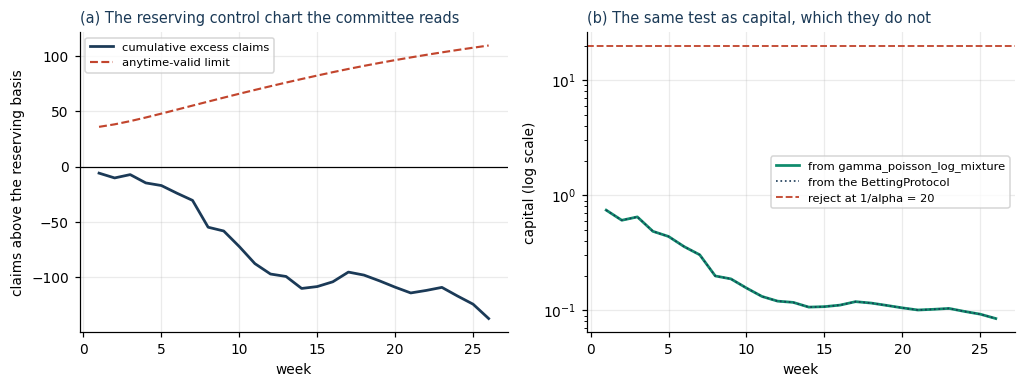

In [26]:
fig, ax = panels(2, ["The reserving control chart the committee reads",
                     "The same test as capital, which they do not"], ncols=2)

ax[0].plot(weeks, S_claims, color=INK, lw=1.8, label="cumulative excess claims")
ax[0].plot(weeks, claim_boundary, color=WARN, ls="--", lw=1.4, label="anytime-valid limit")
ax[0].fill_between(weeks, S_claims, claim_boundary, where=S_claims > claim_boundary,
                   color=WARN, alpha=0.18)
ax[0].axhline(0, color="black", lw=0.8)
ax[0].set_xlabel("week"); ax[0].set_ylabel("claims above the reserving basis")
ax[0].legend(fontsize=7.5)

ax[1].semilogy(weeks, np.exp(np.clip(log_e_functional, -700, 700)), color=EVID, lw=1.8,
               label="from gamma_poisson_log_mixture")
ax[1].semilogy(war.step, war.e_process_value, color=INK, lw=1.1, ls=":",
               label="from the BettingProtocol")
ville(ax[1])
ax[1].set_xlabel("week"); ax[1].set_ylabel("capital (log scale)"); ax[1].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

Two lines, one test. The left panel goes in the reserving pack; the right panel goes to
whoever maintains the monitor. They cannot disagree, because the cross-check above shows
they are the same numbers to $10^{-10}$.

**The general rule:** use the **mixture class** (`GammaPoissonMixture.log_superMG`) inside a
strategy where you are accumulating state, and the **functional API**
(`gamma_poisson_log_mixture`, `gamma_poisson_mixture_bound`) when you want a chart or a
one-shot evaluation over a vector. Never re-derive either one by hand.

---
# 6. LLM vendor bake-off: your null class *is* your business claim

## 6.1 The domain

A SaaS company is choosing between two LLM vendors for support-ticket summarisation. The
evaluation is the standard one: take a ticket, generate a summary with each model, have a
human rater score both on a 7-point scale. **Paired design**, which is correct - it removes
ticket difficulty as a source of variance.

Procurement asks "which model is better?" That question is not well-posed, and the reason
is commercial rather than philosophical.

Consider the situation that actually turns up in model evaluation. Vendor B is tuned for
the common case - short, simple tickets - where it wins by a little. Vendor A is better on
the rare complex ticket, where it wins by a lot. Then:

- The **support director** cares about win rate: what fraction of tickets get a better
  summary.
- The **CFO** cares about average quality per ticket, because that is what feeds the
  deflection-rate model, and one catastrophic summary costs more than three marginal ones.

These two people can read the same data and reach opposite, correct conclusions. **No test
resolves this, and a test that appears to is hiding a choice that belongs to the business.**

## 6.2 Designing the study: three tests, three nulls

`modules.hypothesistesting.SymmetryETest` implements three symmetry e-tests from Vovk &
Wang (2024). They are usually presented as three ways to do one job. They are not - they
have **different null classes**, and the null class *is* the business claim:

| Test | Null class | The sentence it licenses | Asymptotic efficiency |
|---|---|---|---|
| `SIGN` | $\Pr[d > 0] = \tfrac12$ - each sign is a fair coin | "B wins more tickets than A" | $2/\pi \approx 0.64$ |
| `FISHER` | $d$ is **symmetric** about 0 | "B's advantage is real, magnitudes included" | $1.0$ |
| `WILCOXON` | $d$ is symmetric about 0 (via signed ranks) | as Fisher, rank-based | $3/\pi \approx 0.95$ |

Symmetry is strictly stronger than a fair sign. So Fisher and Wilcoxon can legitimately
reject where the sign test cannot - **not because they are more powerful, but because they
are testing something else.** Choose the row that matches the sentence you intend to put in
the procurement memo, then run that test.

| Contract part | This study |
|---|---|
| **Null class** | One of the three above - **the choice is the deliverable**. |
| **Filtration** | Per rating batch; each batch's e-value uses that batch only, then compounds. |
| **Clock** | One batch = one rater session of 30 tickets. |
| **Downstream use** | A vendor contract. Irreversible for the contract term. |

## 6.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Batches are independent | Different tickets, different raters | Rater fatigue within a session correlates scores; compounding over-states evidence |
| Presentation order is randomised | Standard practice in paired evaluation | Position bias makes $d$ asymmetric under the null and **all three tests break** |
| **No ties** in the paired differences | It is not true here, and Section 6.5 is about exactly that | See 6.5 - this is a genuine validity trap |

## 6.4 The data-generating mechanism

We simulate the **rating process**, not the differences. Latent quality per model per
ticket, then Likert bucketing into 1-7, which is what raters actually produce and which
makes the observed difference a bounded integer.

The two vendors get the same baseline quality. B gets a small edge on simple tickets;
A gets a large edge on the 20% of tickets that are complex. Nothing here is chosen to make
a test reject - we set the parameters of the world and then report what the tests say.

In [27]:
from expectation.modules.epower import EPowerCalculator, EPowerConfig
from expectation.modules.eprocessupdater import EProcessUpdater
from expectation.modules.hypothesistesting import EProcess, SymmetryETest, SymmetryType

# --- fixed from the evaluation plan BEFORE any data ---------------------------
SESSION_TICKETS = 30      # tickets rated in one session
N_SESSIONS = 60           # the evaluation budget: 1,800 rated tickets
LIKERT = 7

# --- the rating mechanism -----------------------------------------------------
QUALITY_MEAN = 4.2
RATER_NOISE = 0.8
P_COMPLEX = 0.20          # share of tickets that are genuinely hard
B_EDGE_SIMPLE = 0.35      # B is tuned for the common case
A_EDGE_COMPLEX = 1.60     # A is much better when the ticket is hard


def rate_session(rng, n=SESSION_TICKETS, differentiated=True, drop_ties=True):
    """Simulate one rater session: latent quality -> Likert score -> paired difference."""
    difficulty = rng.normal(0.0, 0.6, n)                  # shared ticket difficulty
    is_complex = rng.random(n) < P_COMPLEX
    edge = np.where(is_complex, -A_EDGE_COMPLEX, B_EDGE_SIMPLE) if differentiated else 0.0
    latent_a = QUALITY_MEAN + difficulty + rng.normal(0, RATER_NOISE, n)
    latent_b = QUALITY_MEAN + difficulty + edge + rng.normal(0, RATER_NOISE, n)
    d = np.clip(np.round(latent_b), 1, LIKERT) - np.clip(np.round(latent_a), 1, LIKERT)
    return d[d != 0] if drop_ties else d


raw = np.concatenate([rate_session(np.random.default_rng(900 + i), drop_ties=False)
                      for i in range(300)])
nz = raw[raw != 0]
print(f"rating mechanism, {len(raw):,} paired comparisons:")
print(f"  ties (both models scored the same) : {np.mean(raw == 0):.1%}")
print(f"  P(B preferred | not tied)          : {np.mean(nz > 0):.3f}   <- the support director's number")
print(f"  mean score difference              : {np.mean(raw):+.3f}    <- the CFO's number")
print(f"  mean margin when B wins            : {np.mean(nz[nz > 0]):.2f} Likert points")
print(f"  mean margin when A wins            : {np.mean(-nz[nz < 0]):.2f} Likert points")
print("\nB wins almost exactly half the tickets, and loses by more when it loses.")
print("Those two facts are the support director's answer and the CFO's answer.")

rating mechanism, 9,000 paired comparisons:
  ties (both models scored the same) : 28.5%
  P(B preferred | not tied)          : 0.514   <- the support director's number
  mean score difference              : -0.032    <- the CFO's number
  mean margin when B wins            : 1.43 Likert points
  mean margin when A wins            : 1.61 Likert points

B wins almost exactly half the tickets, and loses by more when it loses.
Those two facts are the support director's answer and the CFO's answer.


## 6.5 A validity trap you must handle: ties

Look at the tie rate above. On a 7-point scale a large share of paired comparisons are
exact ties, and that breaks two of the three tests.

- The **Fisher** e-value contributes $e^{\lambda \cdot 0} / \cosh(0) = 1$ for a tie. Harmless.
- The **sign** e-value is $e^{\lambda k}\left(\tfrac{2}{1+e^{\lambda}}\right)^{n}$ with
  $k = \#\{d > 0\}$ and $n$ the sample size. Under the null it needs
  $k \sim \mathrm{Binomial}(n, \tfrac12)$. With ties included in $n$ but never counted in
  $k$, that is false - $k$ is stochastically too small.
- The **Wilcoxon** e-value has the same problem through its signed ranks.

The consequence is direction-dependent and therefore easy to miss: with $\lambda > 0$ the
distortion is conservative, so nothing looks wrong. With $\lambda < 0$ - which is what you
get if you tune $\lambda$ and the evidence points the other way - it is **anti-conservative**.

The standard nonparametric remedy is the reduced-sample procedure: **drop the ties**, which
restores $k \sim \mathrm{Binomial}(n_{\text{non-tied}}, \tfrac12)$ exactly. We measure the
trap rather than describing it, on data where the two vendors are genuinely identical.

In [28]:
def run_symmetry(sym, lam, gen, seed, n_sessions=N_SESSIONS):
    """Compound per-session symmetry e-values into an e-process."""
    t_ = SymmetryETest(test_type=sym, lambda_value=lam)
    cfg = EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN)
    ep, up = EProcess(config=cfg), EProcessUpdater(cfg)
    r_, stop, path = np.random.default_rng(seed), None, []
    for i in range(1, n_sessions + 1):
        e = float(t_.compute(gen(r_)))
        up.update(ep, e if np.isfinite(e) and e >= 0 else 1.0)
        path.append(up.get_current_value(ep))
        if stop is None and up.is_significant(ep):
            stop = i
    return stop, np.array(path)


identical_with_ties = lambda r: rate_session(r, differentiated=False, drop_ties=False)
identical_no_ties = lambda r: rate_session(r, differentiated=False, drop_ties=True)

N_RUNS = 200
LAM_PROBE = -0.10      # a negative lambda: betting in the direction the evidence points
print(f"false-alarm rate with two IDENTICAL vendors, lambda = {LAM_PROBE} "
      f"({N_RUNS} runs, budget {ALPHA})\n")
print(f"{'test':<10} {'ties kept (WRONG)':>19} {'ties dropped (correct)':>24}")
print("-" * 56)
tie_rows = []
for sym in SymmetryType:
    with_ties = np.mean([run_symmetry(sym, LAM_PROBE, identical_with_ties, 21_000 + i)[0]
                         is not None for i in range(N_RUNS)])
    no_ties = np.mean([run_symmetry(sym, LAM_PROBE, identical_no_ties, 21_000 + i)[0]
                       is not None for i in range(N_RUNS)])
    tie_rows.append({"test": sym.value, "ties_kept": with_ties, "ties_dropped": no_ties})
    print(f"{sym.value:<10} {with_ties:>19.3f} {no_ties:>24.3f}")
tie_df = pd.DataFrame(tie_rows)
print("\nThe middle column is a false-alarm rate on data where nothing is happening.")
print("Everything from here on drops ties first.")

false-alarm rate with two IDENTICAL vendors, lambda = -0.1 (200 runs, budget 0.05)

test         ties kept (WRONG)   ties dropped (correct)
--------------------------------------------------------


fisher                   0.030                    0.030


sign                     1.000                    0.010


wilcoxon                 0.005                    0.010

The middle column is a false-alarm rate on data where nothing is happening.
Everything from here on drops ties first.


## 6.6 Tuning the betting parameter: magnitude *and* sign

Each symmetry test has a betting parameter $\lambda$, and it carries two pieces of
information:

- **Its magnitude** must match the scale of the statistic. $\lambda$ is not dimensionless:
  the Wilcoxon statistic $V_n$ grows like $n^2$ while the sign statistic grows like $n$, so
  a $\lambda$ that is sensible for one is catastrophic for the other.
- **Its sign is the direction of your bet.** $\lambda > 0$ bets that $d$ is positive
  (B better), $\lambda < 0$ bets the other way. Both are valid e-values under the null;
  betting the wrong way simply loses money.

We tune on a **pilot** so the choice stays $\mathcal{F}_0$-measurable, and we tune on
**e-power** $\mathbb{E}[\log E]$ rather than $\mathbb{E}[E]$, because capital is a product.

In [29]:
LAMBDA_GRID = [-0.30, -0.15, -0.08, -0.04, -0.02, -0.005, 0.005, 0.02, 0.04, 0.08, 0.15, 0.30]
pilot = [rate_session(np.random.default_rng(700 + i)) for i in range(40)]
calc = EPowerCalculator(EPowerConfig())

tuning = []
for sym in SymmetryType:
    for lam in LAMBDA_GRID:
        t_ = SymmetryETest(test_type=sym, lambda_value=lam)
        evs = np.array([float(t_.compute(b)) for b in pilot])
        evs = evs[np.isfinite(evs) & (evs > 0)]
        if len(evs) < 5:
            continue
        res = calc.compute(evs)
        tuning.append({"test": sym.value, "lambda": lam,
                       "e_power": res.e_power, "mean_E": res.expected_e_value})
tune_df = pd.DataFrame(tuning)
print("e-power (growth rate) by lambda. Watch the SIGN of each column's best entry:\n")
print(tune_df.pivot(index="lambda", columns="test", values="e_power").round(4).to_string())

chosen = (tune_df.sort_values("e_power", ascending=False)
          .drop_duplicates("test").set_index("test"))
print("\nchosen lambda per test, and what it implies for the evaluation budget:")
print(f"{'test':<10} {'lambda':>8} {'e-power':>10} {'mean E':>9} {'sessions to reach 1/alpha':>27}")
print("-" * 68)
for name, r in chosen.iterrows():
    need = np.log(THRESHOLD) / r.e_power if r.e_power > 0 else np.inf
    print(f"{name:<10} {r['lambda']:>8.3f} {r.e_power:>10.4f} {r.mean_E:>9.3f}"
          f" {(f'{need:,.0f}' if np.isfinite(need) else 'never - wrong direction'):>27}")
print(f"\nThe evaluation budget is {N_SESSIONS} sessions. That number and the column above")
print("are the honest answer to 'is this evaluation big enough?' - asked BEFORE running it.")

e-power (growth rate) by lambda. Watch the SIGN of each column's best entry:

test    fisher    sign  wilcoxon
lambda                          
-0.300 -2.2665 -0.2618  -23.1150
-0.150 -0.5377 -0.0712   -7.8345
-0.080 -0.1225 -0.0231   -2.4865
-0.040 -0.0129 -0.0073   -0.6122
-0.020  0.0058 -0.0026   -0.1326
-0.005  0.0037 -0.0004    0.0003
 0.005 -0.0053  0.0003   -0.0228
 0.020 -0.0302  0.0004   -0.2251
 0.040 -0.0849 -0.0013   -0.7972
 0.080 -0.2665 -0.0111   -2.8565
 0.150 -0.8077 -0.0487   -8.5283
 0.300 -2.8065 -0.2168  -24.5025

chosen lambda per test, and what it implies for the evaluation budget:
test         lambda    e-power    mean E   sessions to reach 1/alpha
--------------------------------------------------------------------
fisher       -0.020     0.0058     1.016                         520
sign          0.020     0.0004     1.002                       6,926
wilcoxon     -0.005     0.0003     1.009                       8,974

The evaluation budget is 60 sessions. That

### Two things to read off that table

**First, the signs disagree, and that is the section's thesis arriving in the numbers.**
The magnitude-based tests (Fisher, Wilcoxon) want a negative $\lambda$ - they want to bet
*against* B. The win-rate test (sign) wants a positive $\lambda$ - it wants to bet *on* B.
Tuned independently, on the same pilot data, by the same criterion, they choose **opposite
directions**. Nothing has gone wrong: B wins slightly more tickets and loses by more when it
loses, so "wins more often" and "better on average" genuinely point different ways.

**Second, the last column is the most useful output in this section.**

E-power is the expected log e-value per session, and capital compounds, so the sessions
needed to reach $1/\alpha$ is approximately $\log(1/\alpha) / \text{e-power}$. That turns a
statistical quantity into a **procurement planning number**: how many rater sessions - and
therefore how much human rating budget - this decision actually requires.

Running the evaluation anyway, with the budget that was approved:

In [30]:
paths, stops = {}, {}
print(f"the bake-off as run: {N_SESSIONS} sessions x {SESSION_TICKETS} tickets "
      f"= {N_SESSIONS * SESSION_TICKETS:,} rated tickets\n")
for sym in SymmetryType:
    lam = float(chosen.loc[sym.value, "lambda"])
    stops[sym.value], paths[sym.value] = run_symmetry(sym, lam, rate_session, 4_242)
    eff = SymmetryETest(test_type=sym).get_asy_efficiency()
    verdict = (f"REJECTED at session {stops[sym.value]}" if stops[sym.value]
               else "no rejection within the approved budget")
    print(f"  {sym.value:<9} (lambda {lam:+.3f}, efficiency {eff:.2f}): {verdict}")
    print(f"  {'':<9}  final capital {paths[sym.value][-1]:.4g}")
print("\nGround truth, revealed now: B is better on the 80% of tickets that are simple,")
print("A is much better on the 20% that are complex. There is no single 'better model'.")

the bake-off as run: 60 sessions x 30 tickets = 1,800 rated tickets

  fisher    (lambda -0.020, efficiency 1.00): no rejection within the approved budget
             final capital 0.747
  sign      (lambda +0.020, efficiency 0.64): no rejection within the approved budget
             final capital 1.485
  wilcoxon  (lambda -0.005, efficiency 0.95): no rejection within the approved budget
             final capital 0.3398

Ground truth, revealed now: B is better on the 80% of tickets that are simple,
A is much better on the 20% that are complex. There is no single 'better model'.


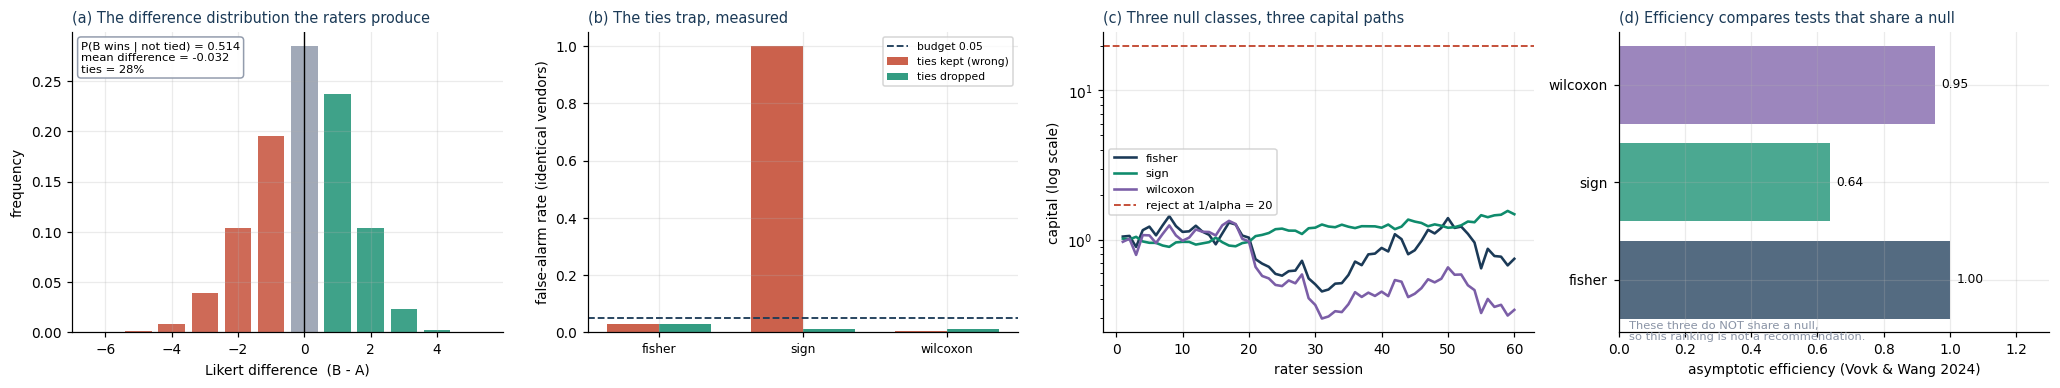

In [31]:
fig, ax = panels(4, ["The difference distribution the raters produce",
                     "The ties trap, measured",
                     "Three null classes, three capital paths",
                     "Efficiency compares tests that share a null"], ncols=4)

vals, counts = np.unique(raw, return_counts=True)
cols = [WARN if v < 0 else (MUTE if v == 0 else EVID) for v in vals]
ax[0].bar(vals, counts / counts.sum(), color=cols, alpha=0.8, width=0.8)
ax[0].axvline(0, color="black", lw=0.9)
ax[0].set_xlabel("Likert difference  (B - A)"); ax[0].set_ylabel("frequency")
ax[0].text(0.02, 0.97, f"P(B wins | not tied) = {np.mean(nz > 0):.3f}\n"
                       f"mean difference = {np.mean(raw):+.3f}\n"
                       f"ties = {np.mean(raw == 0):.0%}",
           transform=ax[0].transAxes, va="top", fontsize=7.5,
           bbox=dict(boxstyle="round", fc="white", ec=MUTE, alpha=0.92))

xs = np.arange(len(tie_df)); w = 0.36
ax[1].bar(xs - w / 2, tie_df.ties_kept, w, color=WARN, alpha=0.85, label="ties kept (wrong)")
ax[1].bar(xs + w / 2, tie_df.ties_dropped, w, color=EVID, alpha=0.85, label="ties dropped")
ax[1].axhline(ALPHA, color=INK, ls="--", lw=1.2, label=f"budget {ALPHA}")
ax[1].set_xticks(xs); ax[1].set_xticklabels(tie_df.test, fontsize=8)
ax[1].set_ylabel("false-alarm rate (identical vendors)"); ax[1].legend(fontsize=7)

for (name, path), colour in zip(paths.items(), [INK, EVID, "#7b5ea7"]):
    ax[2].semilogy(np.arange(1, len(path) + 1), np.maximum(path, 1e-12), lw=1.7,
                   color=colour, label=name)
ville(ax[2])
ax[2].set_xlabel("rater session"); ax[2].set_ylabel("capital (log scale)")
ax[2].legend(fontsize=7.5)

effs = [SymmetryETest(test_type=s).get_asy_efficiency() for s in SymmetryType]
names = [s.value for s in SymmetryType]
bars = ax[3].barh(names, effs, color=[INK, EVID, "#7b5ea7"], alpha=0.75)
for b, e in zip(bars, effs):
    ax[3].text(e + 0.02, b.get_y() + b.get_height() / 2, f"{e:.2f}", va="center", fontsize=8)
ax[3].set_xlim(0, 1.3); ax[3].set_xlabel("asymptotic efficiency (Vovk & Wang 2024)")
ax[3].text(0.03, -0.62, "These three do NOT share a null,\nso this ranking is not a "
                        "recommendation.", fontsize=7.5, color=MUTE)
plt.tight_layout(); plt.show()

## 6.7 Reading the output

**Panel (a)** is the finding, before any test is run. Green bars are B's wins, red are A's,
grey is the tie column - and the tie column is large, which is panel (b)'s problem. The box
gives the two numbers procurement will argue about: a win rate at essentially a coin flip,
and a mean difference that leans the other way.

**Panel (b)** is the trap, measured. The red bars are false-alarm rates on data where the
two vendors are *identical*. Anything above the dashed budget line is a test that will
manufacture a procurement decision out of noise. Dropping ties fixes it.

**Panel (c)** shows the three capital paths. What matters is not which is highest but that
they are betting against **different nulls** on the same data.

**Panel (d)** carries the warning. Asymptotic efficiency is a meaningful comparison only
between tests that share a null. Reading "Fisher 1.00 beats sign 0.64, use Fisher" off this
chart is how you end up making a win-rate claim with a magnitude test.

### The rule to take away

> **Choose the null class from the sentence you intend to write, then pick the test.**
> Going the other way - picking whichever test rejects and then writing a sentence around
> it - is how a multi-year vendor contract gets signed on a claim the data does not support.

## 6.8 Conclusion and runbook

1. Write the procurement sentence first. "Wins more often" needs `SIGN`. "Better on
   average" or "higher quality" needs `FISHER` or `WILCOXON`.
2. **Drop ties** before the sign and Wilcoxon tests. On a Likert scale this is not an edge
   case, and the failure is silent and direction-dependent.
3. Tune $\lambda$ on a pilot by maximising **e-power**. Its sign is the direction of the bet
   and its magnitude must match the statistic's scale ($V_n \sim n^2$ for Wilcoxon).
4. Use $\log(1/\alpha) / \text{e-power}$ to size the evaluation **before** commissioning the
   rating budget. An evaluation that cannot resolve the question is worth knowing about in
   advance.
5. Randomise presentation order. Position bias breaks the symmetry null for all three tests
   and no sample size repairs it.
6. If the tests disagree, **escalate the disagreement** rather than picking a winner. It
   means win rate and average quality point different ways, and that trade-off belongs to
   whoever owns the P&L.

---
# 7. Model-risk governance: you inherited a pipeline that only speaks p-values

## 7.1 The domain

A bank's Model Risk Management function oversees a credit-decisioning model licensed from a
third-party vendor. The contract gives the bank a **monthly validation report** and nothing
else: no scores, no features, no data. The report contains p-values.

MRM's job is to accumulate evidence over the model's revalidation cycle and escalate when
it is warranted. The obvious things to do are both wrong:

- **Multiply the p-values.** A product of independent uniforms is not a p-value; it is a
  number that gets small on its own and the "combined p-value" is meaningless. This is done
  in production more often than anyone admits.
- **Take the minimum and apply Bonferroni.** Valid, but it throws away 23 of 24 reports.

The correct move is to **calibrate each p-value into an e-value** and compound. E-values
multiply; that is their defining property. `modules.calibrators` implements the five
admissible p-to-e calibrators from Ramdas & Wang (2025, Sec. 2.3).

And a second problem, which is the one that actually bites: MRM oversees **four** vendors,
all scoring the same macroeconomic environment. Their monthly reports are *dependent*, and
nobody can quantify how. Any combination rule that assumes independence is unusable.

**What the mistake costs.** Escalating a model to remediation is expensive and adversarial
with the vendor. Failing to escalate a genuinely drifting credit model is a regulatory
finding and a loan book.

## 7.2 Designing the study

$$H_0:\ \text{the vendor's model is behaving as validated} \qquad \text{so each monthly } p \sim \mathrm{Unif}(0,1) \text{ (or stochastically larger)}.$$

A **p-to-e calibrator** is any decreasing $f:[0,1] \to [0,\infty]$ with $\int_0^1 f(p)\,dp \le 1$,
which is exactly the condition $\mathbb{E}[f(U)] \le 1$ for $U$ uniform. That inequality is
the entire licence to compound. We verify it numerically rather than trusting the label.

Going the other way there is no choice at all: $g(e) = \min(1, 1/e)$ is the **only**
admissible e-to-p calibrator (Ramdas & Wang 2025, Prop. 2.4). `EToPCalibrator` implements
it and there are no options, which is a feature.

| Contract part | This study |
|---|---|
| **Null class** | Per vendor: $p_t$ is stochastically larger than uniform every month. Across vendors: the intersection null, "all four are fine". |
| **Filtration** | Monthly. The calibrator is fixed in advance - choosing it after seeing the $p$ would void everything. |
| **Clock** | One month. |
| **Downstream use** | Escalation to remediation. Expensive, adversarial, and audited. |

## 7.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Under $H_0$ the vendor's $p$ is (super-)uniform | It is the output of a valid test; this is what "valid" means | A vendor with a broken test poisons the whole chain - calibrate their *validity*, not just their number |
| Monthly reports from one vendor are independent | Different account cohorts each month | Serial dependence inflates the compounded evidence |
| **Nothing** about dependence across vendors | They share a macro environment | - this is why we use the arithmetic mean merge |
| The calibrator is chosen before seeing data | It is fixed in the config below | Choosing the calibrator that makes $p$ look worst is $p$-hacking with extra steps |

## 7.4 The data-generating mechanism

We simulate the vendor's actual monthly test, not the p-value. Each month the vendor
tests calibration intercept on a cohort of accounts; the p-value is the output of a
one-sided z-test on that cohort. Each vendor's true drift is **drawn**, and a shared macro
factor is injected each month so the four vendors' reports are genuinely dependent - which
is the realistic situation and the reason the merge choice matters.

## 7.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `calibrators.PToECalibrator` (all five) | Turns an inherited p-value into something that compounds | Multiplying p-values is invalid; min + Bonferroni discards almost everything |
| `calibrators.EToPCalibrator` | The unique admissible way back, for committees that want a p-value | There is no alternative - that is the theorem |
| `merging.ArithmeticMeanMerger` | Valid under **arbitrary** dependence across vendors | `ProductMerger` needs independence, which nobody here can certify |
| `eprocessupdater.EProcessUpdater` | Compounds the monthly e-values | - |

In [32]:
import scipy.stats as ss

from expectation.modules.calibrators import EToPCalibrator, PToECalibrator, PToECalibratorType
from expectation.modules.eprocessupdater import EProcessUpdater
from expectation.modules.hypothesistesting import BettingStrategy, EProcess, EProcessConfig
from expectation.modules.merging import ArithmeticMeanMerger, ProductMerger

# All five admissible calibrators, side by side.
calibrators = {t: PToECalibrator(calibrator_type=t) for t in PToECalibratorType}
calibrators[PToECalibratorType.POWER] = PToECalibrator(
    calibrator_type=PToECalibratorType.POWER, kappa=0.4)

shape = pd.DataFrame(
    {t.value: [float(np.asarray(c(p))) for p in [0.001, 0.01, 0.05, 0.20, 0.50, 0.90]]
     for t, c in calibrators.items()},
    index=["p=0.001", "p=0.01", "p=0.05", "p=0.20", "p=0.50", "p=0.90"])
print("what each calibrator pays for a given p-value:")
print(shape.round(3).to_string())

# The licence to compound: E[f(U)] <= 1 for U uniform. Verify, do not assume.
U = np.random.default_rng(0).random(500_000)
print("\nvalidity check  E[f(U)] <= 1  (500,000 uniforms):")
for t, c in calibrators.items():
    print(f"  {t.value:12} {float(np.mean(c(U))):.4f}")

print(f"\nthe unique admissible way back: EToPCalibrator(e) = min(1, 1/e)")
print(f"  e = 20  ->  p = {float(EToPCalibrator()(20.0)):.4f}"
      f"      e = 3 -> p = {float(EToPCalibrator()(3.0)):.4f}")

what each calibrator pays for a given p-value:
          power  mixture  linear  shafer  logarithmic
p=0.001  25.238   20.791   1.998  30.623        6.908
p=0.01    6.340    4.451   1.980   9.000        4.605
p=0.05    2.414    1.783   1.900   3.472        2.996
p=0.20    1.051    0.923   1.600   1.236        1.609
p=0.50    0.606    0.639   1.000   0.414        0.693
p=0.90    0.426    0.518   0.200   0.054        0.105

validity check  E[f(U)] <= 1  (500,000 uniforms):
  power        1.0019
  mixture      0.9446
  linear       0.9998
  shafer       1.0017
  logarithmic  0.9996

the unique admissible way back: EToPCalibrator(e) = min(1, 1/e)
  e = 20  ->  p = 0.0500      e = 3 -> p = 0.3333


### Reading the calibrator table

They differ in **where they put their weight**, and that is a modelling choice about what
kind of evidence you expect:

- `LINEAR` ($2(1-p)$) is bounded by 2. It can never produce strong evidence from one report,
  which makes it useless for a single decisive month and safe against a vendor who
  occasionally reports an absurd $p$.
- `SHAFER` ($p^{-1/2}-1$) and `LOGARITHMIC` ($-\log p$) pay heavily for small $p$. Use these
  when you believe a real problem shows up as a decisive month.
- `POWER` ($\kappa p^{\kappa-1}$) lets you dial that aggressiveness with $\kappa$.
- `MIXTURE` is the hedge across power calibrators.

All five are admissible, so **all five are defensible to an auditor**. Pick from the shape
of failure you expect, write it in the model documentation, and then do not change it.

## 7.6 Building it

In [33]:
# --- fixed from the MRM policy BEFORE any data --------------------------------
N_VENDORS = 4
CYCLE_MONTHS = 24           # the model revalidation cycle
COHORT = 2_000              # accounts in each vendor's monthly validation cohort
CALIBRATOR = PToECalibratorType.SHAFER   # chosen in advance and documented

# --- the world: each vendor's true drift is DRAWN -----------------------------
world = np.random.default_rng(77)
vendor_drift = world.normal(0.0, 0.035, N_VENDORS)   # calibration intercept per vendor
FACTOR_LOADING = 0.5   # how much of each cohort's residual is the SHARED economy


def monthly_reports(rng, drift, rho=FACTOR_LOADING):
    """One month of vendor reports, from a shared-factor mechanism.

    All four vendors score overlapping borrower populations in one economy, so
    their cohorts share a latent factor. Crucially the factor has mean zero, so
    under H0 each vendor's p-value is still exactly uniform - what the factor
    creates is DEPENDENCE, not drift. That separation is what makes the merge
    comparison below a fair test of the dependence assumption.
    """
    common = rng.normal(0.0, 1.0, COHORT)                # the shared economy
    out = []
    for v in range(N_VENDORS):
        idiosyncratic = rng.normal(0.0, 1.0, COHORT)
        resid = drift[v] + rho * common + np.sqrt(1 - rho**2) * idiosyncratic
        z = resid.mean() / (resid.std(ddof=1) / np.sqrt(COHORT))
        out.append(float(ss.norm.sf(z)))                 # one-sided p-value
    return np.array(out)


# Confirm the mechanism does what we claim: uniform margins, dependent jointly.
_r = np.random.default_rng(1)
_probe = np.array([monthly_reports(_r, np.zeros(N_VENDORS)) for _ in range(1500)])
print(f"mechanism check under H0: P(p < 0.05) = {np.mean(_probe < 0.05):.3f} (should be ~0.05)")
print(f"                          corr(p_v0, p_v1) = {np.corrcoef(_probe.T)[0, 1]:.3f}"
      f" (dependence is real)\n")


cal = PToECalibrator(calibrator_type=CALIBRATOR)
cfg = EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN)
per_vendor = [(EProcess(config=cfg), EProcessUpdater(cfg)) for _ in range(N_VENDORS)]
amean, prod = ArithmeticMeanMerger(K=N_VENDORS), ProductMerger()
global_ep, global_up = EProcess(config=cfg), EProcessUpdater(cfg)
naive_ep, naive_up = EProcess(config=cfg), EProcessUpdater(cfg)

reporting = np.random.default_rng(78)
rows, p_log = [], []
for month in range(1, CYCLE_MONTHS + 1):
    p = monthly_reports(reporting, vendor_drift)
    p_log.append(p)
    e = np.asarray(cal(p), dtype=float)                  # p -> e, per vendor

    for v in range(N_VENDORS):
        ep, up = per_vendor[v]
        up.update(ep, float(e[v]))

    # Across vendors, same month: two merges with different dependence contracts.
    global_up.update(global_ep, float(amean.merge(e).merged_e_value))
    naive_up.update(naive_ep, float(prod.merge(e).merged_e_value))

    rows.append({
        "month": month,
        **{f"p_v{v}": p[v] for v in range(N_VENDORS)},
        **{f"e_v{v}": per_vendor[v][1].get_current_value(per_vendor[v][0]) for v in range(N_VENDORS)},
        "global_amean": global_up.get_current_value(global_ep),
        "global_product": naive_up.get_current_value(naive_ep),
    })
mrm = pd.DataFrame(rows)

print(f"over the {CYCLE_MONTHS}-month revalidation cycle, calibrator = {CALIBRATOR.value}\n")
print(f"  {'':8} {'capital now':>12} {'running max':>13} {'min monthly p':>14}   verdict")
for v in range(N_VENDORS):
    ep, up = per_vendor[v]
    st = up.get_stopping_time(ep)
    print(f"  vendor {v}: {up.get_current_value(ep):>12.3g} {up.get_max_value(ep):>13.3g} "
          f"{mrm[f'p_v{v}'].min():>14.4f}   "
          f"{'ESCALATE (month ' + str(st) + ')' if st else 'no escalation'}")
print("\n  Escalation is decided on the RUNNING MAX, not on current capital: Ville's")
print("  inequality bounds the supremum, so a vendor that crossed and then recovered")
print("  has still been escalated. That is what makes the date defensible later.")
print(f"\n  portfolio (arithmetic-mean merge, dependence-agnostic): "
      f"{global_up.get_current_value(global_ep):.3g}"
      f"   {'ESCALATE at month ' + str(global_up.get_stopping_time(global_ep)) if global_up.get_stopping_time(global_ep) else 'no escalation'}")
print(f"  portfolio (product merge, assumes independence)       : "
      f"{naive_up.get_current_value(naive_ep):.3g}   <- NOT licensed here")
print(f"\n  true vendor drifts, revealed now: "
      + ", ".join(f'v{v}={d:+.4f}' for v, d in enumerate(vendor_drift)))

mechanism check under H0: P(p < 0.05) = 0.051 (should be ~0.05)
                          corr(p_v0, p_v1) = 0.243 (dependence is real)

over the 24-month revalidation cycle, calibrator = shafer

            capital now   running max  min monthly p   verdict
  vendor 0:     0.000195          39.5         0.0045   ESCALATE (month 5)
  vendor 1:        5e-30             1         0.0944   no escalation
  vendor 2:     7.35e+66      7.35e+66         0.0000   ESCALATE (month 1)
  vendor 3:     4.92e-63             1         0.7724   no escalation

  Escalation is decided on the RUNNING MAX, not on current capital: Ville's
  inequality bounds the supremum, so a vendor that crossed and then recovered
  has still been escalated. That is what makes the date defensible later.

  portfolio (arithmetic-mean merge, dependence-agnostic): 4.76e+52   ESCALATE at month 1
  portfolio (product merge, assumes independence)       : 3.52e-29   <- NOT licensed here

  true vendor drifts, revealed now: v0=+0

### The dependence trap, measured rather than argued

The product merge will usually report a larger number than the arithmetic mean, and a
governance function under pressure will prefer the larger number. But that gap is not extra
sensitivity - it is the arithmetic of multiplying four correlated quantities.

To show the gap is a **validity** gap and not a power gap, we run both under a *true global
null* - every vendor behaving exactly as validated - and sweep how strongly the shared
economy couples their cohorts. Under a true null, every escalation is a false one, so these
numbers are directly comparable to the $\alpha = 0.05$ budget.

In [34]:
def portfolio_false_alarms(merge, rho, n_runs=200):
    """All four vendors are FINE. Only the shared factor couples their reports."""
    fires = 0
    for s_ in range(n_runs):
        r_ = np.random.default_rng(30_000 + s_)
        cfg_ = EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN)
        ep_, up_ = EProcess(config=cfg_), EProcessUpdater(cfg_)
        merger = ArithmeticMeanMerger(K=N_VENDORS) if merge == "amean" else ProductMerger()
        for _ in range(CYCLE_MONTHS):
            p_ = monthly_reports(r_, np.zeros(N_VENDORS), rho)
            up_.update(ep_, float(merger.merge(np.asarray(cal(p_), dtype=float)).merged_e_value))
        if up_.is_significant(ep_):
            fires += 1
    return fires / n_runs


N_RUNS = 200
mc_se = np.sqrt(ALPHA * (1 - ALPHA) / N_RUNS)
print(f"false ESCALATION rate under a TRUE global null, by how dependent the vendors are")
print(f"({N_RUNS} runs each; budget {ALPHA}, Monte Carlo standard error +/-{mc_se:.3f})\n")
print(f"{'factor loading':>15} {'corr(p_i, p_j)':>15} {'arithmetic mean':>17} {'product':>10}")
print("-" * 61)
dep_rows = []
for rho in [0.0, 0.4, 0.7, 0.9]:
    r_ = np.random.default_rng(7)
    probe = np.array([monthly_reports(r_, np.zeros(N_VENDORS), rho) for _ in range(600)])
    pc = float(np.corrcoef(probe.T)[0, 1])
    a_ = portfolio_false_alarms("amean", rho, N_RUNS)
    p_ = portfolio_false_alarms("product", rho, N_RUNS)
    dep_rows.append({"rho": rho, "p_corr": pc, "fa_amean": a_, "fa_product": p_})
    print(f"{rho:>15.2f} {pc:>15.3f} {a_:>17.3f} {p_:>10.3f}")
dep_df = pd.DataFrame(dep_rows)
print("\nRead down the two right-hand columns. As the vendors become more dependent the")
print("product merge spends more and more of an error budget it was never licensed to")
print("spend, while the arithmetic mean gets MORE conservative. That is the whole trade:")
print("the arithmetic mean gives up power in exchange for needing no assumption at all.")

false ESCALATION rate under a TRUE global null, by how dependent the vendors are
(200 runs each; budget 0.05, Monte Carlo standard error +/-0.015)

 factor loading  corr(p_i, p_j)   arithmetic mean    product
-------------------------------------------------------------


           0.00          -0.018             0.060      0.015


           0.40           0.146             0.045      0.040


           0.70           0.471             0.020      0.085


           0.90           0.793             0.010      0.125

Read down the two right-hand columns. As the vendors become more dependent the
product merge spends more and more of an error budget it was never licensed to
spend, while the arithmetic mean gets MORE conservative. That is the whole trade:
the arithmetic mean gives up power in exchange for needing no assumption at all.


## 7.7 Reading the output

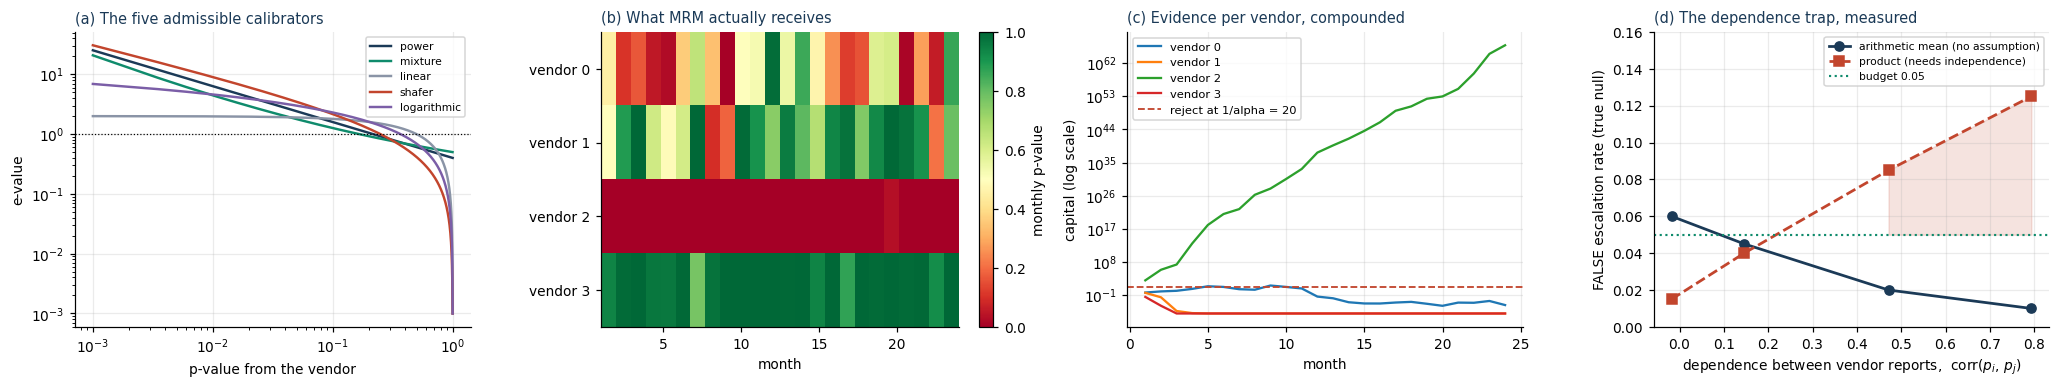

In [35]:
fig, ax = panels(4, ["The five admissible calibrators",
                     "What MRM actually receives",
                     "Evidence per vendor, compounded",
                     "The dependence trap, measured"], ncols=4)

grid = np.linspace(0.001, 1.0, 400)
for (t, c), colour in zip(calibrators.items(),
                          [INK, EVID, MUTE, WARN, "#7b5ea7"]):
    ax[0].loglog(grid, np.maximum(np.asarray(c(grid), dtype=float), 1e-3), lw=1.6,
                 color=colour, label=t.value)
ax[0].axhline(1.0, color="black", lw=0.8, ls=":")
ax[0].set_xlabel("p-value from the vendor"); ax[0].set_ylabel("e-value")
ax[0].legend(fontsize=7)

pmat = np.array(p_log)
im = ax[1].imshow(pmat.T, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
                  extent=[1, CYCLE_MONTHS, N_VENDORS - 0.5, -0.5])
ax[1].set_yticks(range(N_VENDORS)); ax[1].set_yticklabels([f"vendor {v}" for v in range(N_VENDORS)])
ax[1].set_xlabel("month"); ax[1].grid(False)
plt.colorbar(im, ax=ax[1], label="monthly p-value", fraction=0.046)

for v in range(N_VENDORS):
    ax[2].semilogy(mrm.month, np.maximum(mrm[f"e_v{v}"], 1e-6), lw=1.5, label=f"vendor {v}")
ville(ax[2])
ax[2].set_xlabel("month"); ax[2].set_ylabel("capital (log scale)"); ax[2].legend(fontsize=7.5)

_x = dep_df["p_corr"].to_numpy()
_am, _pr = dep_df["fa_amean"].to_numpy(), dep_df["fa_product"].to_numpy()
ax[3].plot(_x, _am, "o-", color=INK, lw=1.8, ms=6, label="arithmetic mean (no assumption)")
ax[3].plot(_x, _pr, "s--", color=WARN, lw=1.8, ms=6, label="product (needs independence)")
ax[3].axhline(ALPHA, color=EVID, ls=":", lw=1.4, label=f"budget {ALPHA}")
ax[3].fill_between(_x, ALPHA, np.maximum(_pr, ALPHA), where=_pr > ALPHA,
                   color=WARN, alpha=0.15)
ax[3].set_xlabel("dependence between vendor reports,  corr($p_i$, $p_j$)")
ax[3].set_ylabel("FALSE escalation rate (true null)")
ax[3].legend(fontsize=7); ax[3].set_ylim(0, max(0.16, float(_pr.max()) * 1.15))
plt.tight_layout(); plt.show()

**Panel (a)** is the calibrator library in one picture. Everything is above the dotted
$e=1$ line for small $p$ and below it for large $p$ - a calibrator that *pays* for
surprising reports and *charges* for boring ones. The vertical spread at $p=0.001$ is the
range of aggressiveness available to you, and `LINEAR`'s flatness is why it can never
produce a decisive month on its own.

**Panel (b)** is what MRM actually has: a grid of numbers from a vendor, nothing else.

**Panel (c)** is the per-vendor accumulation. Note how capital can fall for months and
recover - a quiet month costs you a little capital, it does not reset the clock.

**Panel (d)** is the trap, and it is the panel to remember. The horizontal axis is how
correlated the vendor reports are; the vertical axis is how often each merge escalates when
**nothing is wrong**. On the left, where the reports are independent, both rules sit at their
budget within Monte Carlo error and the product merge is the legitimate, more powerful
choice. Moving right - towards the real world, where four vendors score overlapping borrowers
in one economy - the product merge climbs into the shaded region and spends multiples of its
budget, while the arithmetic mean becomes *more* conservative.

That is the entire trade, priced: **the arithmetic mean gives up power in exchange for
needing no dependence assumption at all.** In a setting where you cannot certify
independence, that is not a conservative choice, it is the only correct one.

## 7.8 Conclusion and runbook

1. **Never multiply p-values.** Calibrate to e-values, then multiply those.
2. Choose the calibrator from the failure shape you expect, document it in the model file,
   and freeze it. Changing it after seeing reports is $p$-hacking with extra steps.
3. Verify $\mathbb{E}[f(U)] \le 1$ on your own generator. It is three lines.
4. Across correlated sources, use `ArithmeticMeanMerger`. It is valid under **arbitrary**
   dependence, which is the only assumption you can actually defend about four vendors in
   one economy.
5. If a committee wants a p-value, `EToPCalibrator` is the unique admissible conversion.
   Report $\min(1, 1/\max_t M_t)$, which is anytime-valid.

## 7.9 The full merging menu: five ways to combine, five different contracts

Section 7.8 used the arithmetic mean because nothing could be assumed about dependence.
That is the safe default, not the only option - and if you *can* say something about the
dependence structure, you should, because the arithmetic mean is paying for an assumption
you do not need.

`modules.merging` implements all five functions from Vovk & Wang (2024). **The question that
picks one is always the same: what do I actually know about how these sources are coupled?**

| Merge | What it needs | Where it belongs commercially |
|---|---|---|
| `ARITHMETIC_MEAN` | **nothing** - arbitrary dependence | Sources you cannot model: vendors in one economy, correlated desks, a shared backhaul |
| `PRODUCT` | full independence | Genuinely separate experiments: different users, different geographies, different physical units |
| `SEGMENT_PRODUCT` | independence **between** groups, anything within | The realistic middle: four vendors per region, regions independent, vendors within a region correlated |
| `U_STATISTIC` | exchangeability of order $n$ | Interchangeable sources - replicate assays, identical sensors |
| `LAMBDA_PRODUCT` | a tunable interpolation | When you want to dial between mean and product by hand |

`create_merger` + `MergingConfig` is the factory to use in production, because the config is
a frozen Pydantic object you can serialise, log and diff in code review - which matters when
the choice of merge *is* a documented modelling assumption.

In [36]:
from expectation.modules.merging import (
    EValueMerger, LambdaProductMerger, MergingConfig, MergingFunction, MergingResult,
    SegmentProductMerger, UStatisticMerger, arithmetic_mean_merge, create_merger,
    lambda_product_merge, segment_product_merge, u_statistic_merge,
)

# Eight vendor reports: two regions of four. Region A has a genuine problem.
example_e = np.array([9.0, 4.0, 1.1, 0.8,    0.9, 1.2, 0.7, 1.0])
REGIONS = [4]        # interior boundary: segments are [0,4) and [4,8)

configs = {
    "arithmetic_mean": MergingConfig(merging_function=MergingFunction.ARITHMETIC_MEAN, K=8),
    "product":         MergingConfig(merging_function=MergingFunction.PRODUCT, K=8),
    "segment_product": MergingConfig(merging_function=MergingFunction.SEGMENT_PRODUCT,
                                     segments=REGIONS, K=8),
    "u_statistic":     MergingConfig(merging_function=MergingFunction.U_STATISTIC, u_order=2, K=8),
    "lambda_product":  MergingConfig(merging_function=MergingFunction.LAMBDA_PRODUCT,
                                     lambda_param=0.5, K=8),
}
print(f"eight vendor reports: {example_e}")
print(f"(vendors 0-3 are region A, 4-7 are region B; region A has the problem)\n")
print(f"{'merge':<18} {'merged e-value':>15}   assumption you are signing")
print("-" * 78)
notes = {"arithmetic_mean": "none at all",
         "product": "all eight fully independent",
         "segment_product": "regions independent; within a region, anything",
         "u_statistic": "sources exchangeable at order 2",
         "lambda_product": "tunable interpolation (lambda = 0.5)"}
for name, cfg_ in configs.items():
    merger = create_merger(cfg_)
    assert isinstance(merger, EValueMerger)      # one ABC, five contracts
    res = merger.merge(example_e)
    assert isinstance(res, MergingResult)
    print(f"{name:<18} {res.merged_e_value:>15.4f}   {notes[name]}")

print("\nthe same five as one-line convenience functions:")
print(f"  u_statistic_merge(e, n=2)          = {u_statistic_merge(example_e, 2):.4f}")
print(f"  lambda_product_merge(e, 0.5)       = {lambda_product_merge(example_e, 0.5):.4f}")
print(f"  segment_product_merge(e, [4])      = {segment_product_merge(example_e, REGIONS):.4f}")
print(f"  arithmetic_mean_merge(e)           = {arithmetic_mean_merge(example_e):.4f}")

print("\nevery merger also exposes its gambling system (Vovk & Wang 2024, Eq. 4) -")
print("the fraction of capital it stakes on the k-th source given the ones before it:")
for name, merger in [("arithmetic_mean", create_merger(configs['arithmetic_mean'])),
                     ("segment_product", SegmentProductMerger(REGIONS, 8)),
                     ("u_statistic", UStatisticMerger(2, 8)),
                     ("lambda_product", LambdaProductMerger(0.5))]:
    stakes = [round(float(merger.gambling_system(list(example_e[:k]), k)), 3) for k in range(1, 6)]
    print(f"  {name:<18} stake on source 1..5: {stakes}")

eight vendor reports: [9.  4.  1.1 0.8 0.9 1.2 0.7 1. ]
(vendors 0-3 are region A, 4-7 are region B; region A has the problem)

merge               merged e-value   assumption you are signing
------------------------------------------------------------------------------
arithmetic_mean             2.3375   none at all
product                    23.9501   all eight fully independent
segment_product             3.5388   regions independent; within a region, anything
u_statistic                 4.4125   sources exchangeable at order 2
lambda_product             10.4925   tunable interpolation (lambda = 0.5)

the same five as one-line convenience functions:
  u_statistic_merge(e, n=2)          = 4.4125
  lambda_product_merge(e, 0.5)       = 10.4925
  segment_product_merge(e, [4])      = 3.5388
  arithmetic_mean_merge(e)           = 2.3375

every merger also exposes its gambling system (Vovk & Wang 2024, Eq. 4) -
the fraction of capital it stakes on the k-th source given the ones before it:

**Read the segment-product row.** It is the one most teams should be using and almost nobody
does. If your sources cluster - regions, data centres, assay plates, business units - and you
believe the *clusters* are independent while the members within a cluster are not, then
segment product is both valid **and** materially more powerful than the arithmetic mean. You
pay only for the dependence you actually have.

**The gambling-system output** is the diagnostic that makes a merge auditable: it shows how
much capital the rule stakes on each source in turn. The arithmetic mean spreads stake
evenly, so one strong source is diluted by $K$; the product concentrates it. That is the same
dilution that made Section 10's global merge blind to concentrated failure.

---
# 8. Experimentation platform: how hard to bet when most experiments do nothing

## 8.1 The domain

A consumer subscription company runs a continuous experimentation programme against one
north-star metric. Leadership asks a question that no individual experiment answers:

> "Across everything we shipped this year, is the roadmap actually moving the metric?"

This is a genuinely sequential, genuinely compounding question, and it exposes the one
parameter the earlier sections quietly left at its default: **the betting fraction**
$\lambda$.

Here is the hard fact about experimentation programmes: **most experiments do nothing.**
Published rates at large consumer companies put the fraction of experiments with a real
positive effect somewhere around one in three, often worse. So the programme-level e-process
is a stream in which many weeks contribute an e-value well below 1.

If you bet **all-in** ($\lambda = 1$), capital is the raw product $\prod_t E_t$. A single
week with $E_t \approx 0.01$ costs you two orders of magnitude and **you never get it back**
- the product has no memory of how good you were before. A programme that spends a quarter
on a failed initiative can end the year with capital near zero while genuinely having moved
the metric.

**What the mistake costs.** Not a false positive - a false *negative*, and a credible
programme that cannot demonstrate its own value.

## 8.2 Designing the study

$$M_t = \prod_{s \le t}\big[(1-\lambda_s) + \lambda_s E_s\big], \qquad \lambda_s \in [0,1] \ \ \mathcal{F}_{s-1}\text{-measurable}.$$

This is Definition 7.21 in Ramdas & Wang (2025) and it is worth staring at. With
$\lambda_s = 1$ you get the raw product. With $\lambda_s < 1$ you keep $(1-\lambda_s)$ of
your capital out of the bet, so **the worst a round can do is multiply you by
$(1-\lambda_s)$** instead of by zero. You buy survival, and you pay in growth rate.

The library offers four strategies through `BettingStrategy`:

| Strategy | $\lambda_t$ | When it is right |
|---|---|---|
| `ALL_IN` | $1$ | Every $E_t$ is bounded away from 0, e.g. a single clean test |
| `CONSERVATIVE` | fixed $\lambda$ | You have a pilot estimate of the e-value distribution |
| `EMPIRICALLY_ADAPTIVE` | maximises empirical e-power over the past, capped at $\gamma$ | You have no prior and want it learned; $\lambda_1 = 0$ by construction |
| `LOG_OPTIMAL` | maximises $\mathbb{E}_Q[\log(\ldots)]$ under a believed alternative $Q$ | You genuinely have a model of the programme |

All four are $\mathcal{F}_{t-1}$-measurable, which is the only thing that matters for
validity. **The choice affects power and survival, never correctness.**

| Contract part | This study |
|---|---|
| **Null class** | "No experiment in the programme moved the metric" - the intersection over weeks. |
| **Filtration** | Weekly. $\lambda_t$ uses weeks $1..t-1$ only; this is enforced by the combiner API. |
| **Clock** | One week = one experiment readout. |
| **Downstream use** | A programme-level narrative to leadership. Reversible, but reputationally sticky. |

## 8.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Weekly experiments are independent | Different features, different user cohorts | Shared seasonality couples them; capital is over-stated |
| Each week's e-value is valid on its own | It comes from a `SequentialTesting` run on that week's data | Garbage in, compounded |
| The believed alternative for `LOG_OPTIMAL` is a belief, not a fact | It is calibrated on the first year's pilot | A wrong $Q$ costs power only - **never validity** |

## 8.4 The data-generating mechanism

We simulate the whole programme rather than the e-values. Each week, an experiment's true
effect is drawn from a **spike-and-slab**: most weeks exactly zero, a minority with a real
positive effect. The week's users are simulated, a real mean e-test is run on them, and the
resulting e-value is what the programme compounds. Nothing about the e-value stream is
synthesised.

## 8.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `eprocessupdater.EProcessUpdater` | Owns the temporal betting; swap strategies through config alone | Hand-rolled products give you `ALL_IN` and no way out |
| `martingales.LogOptimalCombiner` | Uses a believed alternative to choose $\lambda$ optimally | Only available if you can write down $Q$; here we can, from the pilot |
| `epower.EPowerCalculator(optimize_lambda=True)` | Finds $\lambda^\star$ by maximising growth rate on pilot data | - |
| `SequentialTesting(TestType.MEAN)` | Produces each week's e-value from real simulated user data | - |

In [37]:
from expectation.modules.hypothesistesting import EValueConfig
from expectation.seqtest.sequential_e_testing import AlternativeType, SequentialTesting, TestType

# --- fixed from the programme plan BEFORE any data ----------------------------
PROGRAMME_WEEKS = 80          # ~18 months of continuous experimentation
USERS_PER_WEEK = 4_000        # users per arm in a weekly readout
P_REAL_EFFECT = 0.30          # fraction of experiments that do anything at all
EFFECT_SD = 0.06              # size of a real effect, in metric standard deviations


def weekly_experiment(rng):
    """Run one week's experiment end to end and return its e-value.

    Spike-and-slab truth: most weeks the feature does nothing at all.
    """
    has_effect = rng.random() < P_REAL_EFFECT
    effect = abs(rng.normal(0.0, EFFECT_SD)) if has_effect else 0.0
    lift = rng.normal(effect, 1.0, USERS_PER_WEEK)          # metric, standardised

    t_ = SequentialTesting(TestType.MEAN, null_value=0.0,
                           alternative=AlternativeType.GREATER, known_variance=1.0,
                           config=EValueConfig(significance_level=ALPHA))
    return float(t_.update(lift).e_process.process_values[-1]), effect


pilot_rng = np.random.default_rng(88)
pilot_e = np.array([weekly_experiment(pilot_rng)[0] for _ in range(40)])
print(f"pilot of 40 weeks:")
print(f"  weeks with e-value below 1 : {np.mean(pilot_e < 1):.0%}"
      f"   (these are the ones that destroy all-in capital)")
print(f"  smallest weekly e-value    : {pilot_e.min():.4g}")
print(f"  largest weekly e-value     : {pilot_e.max():.4g}")
print(f"  mean e-value               : {pilot_e.mean():.3f}")
print(f"  geometric mean (growth)    : {np.exp(np.mean(np.log(np.maximum(pilot_e, 1e-300)))):.3f}")

pilot of 40 weeks:
  weeks with e-value below 1 : 95%   (these are the ones that destroy all-in capital)
  smallest weekly e-value    : 0.002651
  largest weekly e-value     : 5.85e+05
  mean e-value               : 14626.351
  geometric mean (growth)    : 0.024


### The single most useful number in this section

The pilot already contains the warning. The **arithmetic mean** of the weekly e-values and
their **geometric mean** point in different directions. Capital is a product, so the
geometric mean is what governs it. `EPowerCalculator` computes both, and with
`optimize_lambda=True` it searches for the $\lambda$ that maximises growth:

In [38]:
from expectation.modules.epower import EPowerCalculator, EPowerConfig

plain = EPowerCalculator(EPowerConfig(optimize_lambda=False)).compute(pilot_e)
tuned = EPowerCalculator(EPowerConfig(optimize_lambda=True, grid_size=201)).compute(pilot_e)

print("betting all-in on this stream:")
print(f"  e-power (growth rate) : {plain.e_power:+.4f}   <- negative means capital DECAYS")
print(f"  expected e-value      : {plain.expected_e_value:.3f}   <- looks healthy, and is irrelevant")
print("\nafter optimising the betting fraction:")
print(f"  optimal lambda        : {tuned.optimal_lambda:.3f}")
print(f"  e-power (growth rate) : {tuned.e_power:+.4f}   <- now positive: capital GROWS")
print(f"  expected e-value      : {tuned.expected_e_value:.3f}   <- LOWER than all-in")
print("\nThe expected e-value went down and the growth rate went up. If you optimise the")
print("first number you will systematically pick strategies that go broke.")

LAMBDA_STAR = float(tuned.optimal_lambda)

betting all-in on this stream:
  e-power (growth rate) : -3.7478   <- negative means capital DECAYS
  expected e-value      : 14626.351   <- looks healthy, and is irrelevant

after optimising the betting fraction:
  optimal lambda        : 0.045
  e-power (growth rate) : +0.2530   <- now positive: capital GROWS
  expected e-value      : 659.141   <- LOWER than all-in

The expected e-value went down and the growth rate went up. If you optimise the
first number you will systematically pick strategies that go broke.


In [39]:
def believed_alternative(lam, past_e_values, t, _cache={}):
    """E_Q[log((1-lam) + lam*E)] under the programme's believed alternative Q.

    Q is calibrated from the pilot: the same spike-and-slab the platform believes
    describes its own roadmap. A wrong Q costs power, never validity.
    """
    if "draws" not in _cache:
        r_ = np.random.default_rng(4242)
        _cache["draws"] = np.array([weekly_experiment(r_)[0] for _ in range(600)])
    return float(np.mean(np.log(np.maximum((1 - lam) + lam * _cache["draws"], 1e-300))))


STRATEGIES = {
    "all_in": EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN),
    f"conservative (lambda*={LAMBDA_STAR:.2f})": EProcessConfig(
        significance_level=ALPHA, betting_strategy=BettingStrategy.CONSERVATIVE,
        conservative_lambda=LAMBDA_STAR),
    "empirically adaptive": EProcessConfig(
        significance_level=ALPHA, betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=0.9),
    "log optimal": EProcessConfig(
        significance_level=ALPHA, betting_strategy=BettingStrategy.LOG_OPTIMAL),
}


def run_programme(cfg, seed, weeks=PROGRAMME_WEEKS):
    ep, up = EProcess(config=cfg), EProcessUpdater(cfg)
    if cfg.betting_strategy == BettingStrategy.LOG_OPTIMAL:
        up.set_log_optimal_expectation(believed_alternative)
    r_, stop = np.random.default_rng(seed), None
    for w in range(1, weeks + 1):
        e, _ = weekly_experiment(r_)
        up.update(ep, e)
        if stop is None and up.is_significant(ep):
            stop = w
    return ep, up, stop


print(f"one programme, {PROGRAMME_WEEKS} weeks, the same weekly e-values for every strategy:\n")
runs = {}
for name, cfg_ in STRATEGIES.items():
    ep, up, stop = run_programme(cfg_, 555)
    runs[name] = (ep, up, stop)
    print(f"  {name:30} final log-capital {ep.log_process_values[-1]:+8.2f}   "
          f"mean lambda {np.mean(ep.lambdas):.3f}   "
          f"{'demonstrated at week ' + str(stop) if stop else 'never demonstrated'}")

one programme, 80 weeks, the same weekly e-values for every strategy:



  all_in                         final log-capital  -239.62   mean lambda 1.000   never demonstrated


  conservative (lambda*=0.04)    final log-capital   +47.13   mean lambda 0.045   demonstrated at week 18


  empirically adaptive           final log-capital   +42.47   mean lambda 0.074   demonstrated at week 21


  log optimal                    final log-capital   +49.45   mean lambda 0.109   demonstrated at week 18


### One programme is one draw

The ordering above could be luck. Replicating over many programmes is the only way to make
a claim about strategies, so we do that - and we also check that all four hold their budget
on a programme where **nothing ever works**.

In [40]:
N_PROG = 60
print(f"{N_PROG} independent programmes, {PROGRAMME_WEEKS} weeks each:\n")
final_caps = {}
for name, cfg_ in STRATEGIES.items():
    stops, finals = [], []
    for s in range(N_PROG):
        ep, up, stop = run_programme(cfg_, 60_000 + s)
        stops.append(stop)
        finals.append(ep.log_process_values[-1])
    final_caps[name] = np.array(finals)
    summarise(stops, N_PROG, name)
    print(f"   {'':<34} median final log-capital {np.median(finals):+8.2f}")

# Validity: a programme in which NO experiment ever works.
def dead_programme(cfg, seed, weeks=PROGRAMME_WEEKS):
    ep, up = EProcess(config=cfg), EProcessUpdater(cfg)
    if cfg.betting_strategy == BettingStrategy.LOG_OPTIMAL:
        up.set_log_optimal_expectation(believed_alternative)
    r_ = np.random.default_rng(seed)
    for _ in range(weeks):
        t_ = SequentialTesting(TestType.MEAN, null_value=0.0, alternative=AlternativeType.GREATER,
                               known_variance=1.0, config=EValueConfig(significance_level=ALPHA))
        up.update(ep, float(t_.update(r_.normal(0.0, 1.0, USERS_PER_WEEK))
                            .e_process.process_values[-1]))
    return up.is_significant(ep)


print(f"\nfalse-claim rate on a programme where nothing ever works (budget {ALPHA}):")
for name, cfg_ in STRATEGIES.items():
    rate = np.mean([dead_programme(cfg_, 70_000 + s) for s in range(100)])
    print(f"  {name:30} {rate:.3f}")

60 independent programmes, 80 weeks each:



  all_in                             detected  25/60  (41.7%)   median stop 4
                                      median final log-capital  -203.77


  conservative (lambda*=0.04)        detected  60/60  (100.0%)   median stop 10
                                      median final log-capital   +84.46


  empirically adaptive               detected  60/60  (100.0%)   median stop 18
                                      median final log-capital   +74.09


  log optimal                        detected  60/60  (100.0%)   median stop 10
                                      median final log-capital   +87.16

false-claim rate on a programme where nothing ever works (budget 0.05):


  all_in                         0.000


  conservative (lambda*=0.04)    0.000


  empirically adaptive           0.000


  log optimal                    0.000


## 8.6 Reading the output

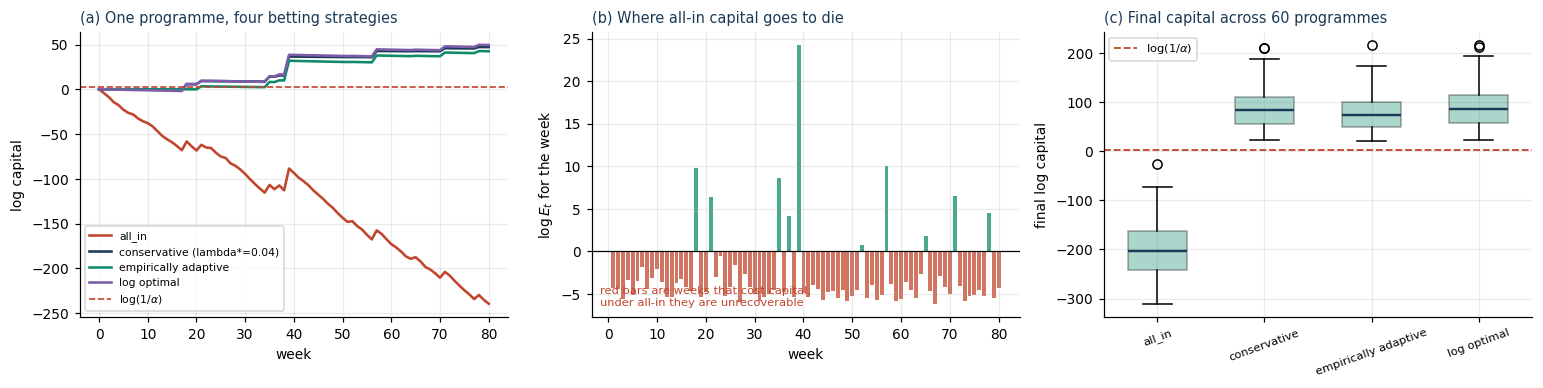

In [41]:
fig, ax = panels(3, ["One programme, four betting strategies",
                     "Where all-in capital goes to die",
                     "Final capital across 60 programmes"], ncols=3)

for (name, (ep, up, stop)), colour in zip(runs.items(), [WARN, INK, EVID, "#7b5ea7"]):
    ax[0].plot(np.arange(len(ep.log_process_values)), ep.log_process_values, lw=1.7,
               color=colour, label=name)
ax[0].axhline(np.log(THRESHOLD), color=WARN, ls="--", lw=1.1, label=r"$\log(1/\alpha)$")
ax[0].set_xlabel("week"); ax[0].set_ylabel("log capital"); ax[0].legend(fontsize=7)

ep_allin = runs["all_in"][0]
weekly = np.array(ep_allin.values)
ax[1].bar(np.arange(1, len(weekly) + 1), np.log(np.maximum(weekly, 1e-300)),
          color=np.where(weekly < 1, WARN, EVID), alpha=0.75)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_xlabel("week"); ax[1].set_ylabel(r"$\log E_t$ for the week")
ax[1].text(0.02, 0.04, "red bars are weeks that cost capital;\n"
                       "under all-in they are unrecoverable",
           transform=ax[1].transAxes, fontsize=7.5, color=WARN)

ax[2].boxplot([final_caps[n] for n in STRATEGIES], labels=[n.split(" (")[0] for n in STRATEGIES],
              vert=True, widths=0.55, patch_artist=True,
              boxprops=dict(facecolor=EVID, alpha=0.35), medianprops=dict(color=INK, lw=1.6))
ax[2].axhline(np.log(THRESHOLD), color=WARN, ls="--", lw=1.2, label=r"$\log(1/\alpha)$")
ax[2].set_ylabel("final log capital"); ax[2].tick_params(axis="x", rotation=20, labelsize=7.5)
ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

**Panel (a)** is the same weekly evidence processed four ways. The all-in path is the one
that falls off a cliff and stays there; the others absorb the same bad week and keep going.

**Panel (b)** explains it. Every red bar is a week whose e-value was below 1. Under all-in
betting, capital is the raw product of these, so a single deep red bar is permanent. Under
$\lambda < 1$ the worst a red bar can do is multiply capital by $(1-\lambda)$.

**Panel (c)** is the replicated version, and it is the honest one. The box plot is the
distribution of final capital over 60 programmes - look at the spread, not just the median.
All-in has the widest spread by far: it is the strategy that sometimes wins biggest and
routinely goes to zero.

The false-claim table underneath is the reassurance: **every strategy spends at most its
budget.** $\lambda$ is not a validity knob. You cannot cheat with it and you cannot break
anything with it - you can only choose how you want to be wrong.

## 8.7 Conclusion and runbook

1. Expect most weeks to produce e-values below 1. That is what an honest experimentation
   programme looks like, and it is fatal to all-in betting.
2. Tune $\lambda$ with `EPowerCalculator(optimize_lambda=True)` on a pilot, then set
   `conservative_lambda`. Optimise the **growth rate**, never the expected e-value.
3. No pilot? Use `EMPIRICALLY_ADAPTIVE`, which learns $\lambda$ from the past and starts at
   $\lambda_1 = 0$ by construction.
4. Have a real model of your roadmap? `LOG_OPTIMAL` will use it, and a wrong model costs you
   power and nothing else.
5. Report the **distribution** of outcomes over replications. A single programme's final
   capital is one draw from panel (c).

## 8.8 The combiners as objects, and the two other things e-power can measure

Section 8 selected betting strategies through `EProcessConfig`, which is the right way in
production - one frozen config drives the whole pipeline. But the strategies are ordinary
objects implementing `SequentialEValueCombiner`, and there are two situations where you want
them directly:

1. **You are writing your own accumulator** and only need the betting rule.
2. **You want to inspect $\lambda_t$** before trusting it - the fraction is
   $\mathcal{F}_{t-1}$-measurable, and looking at the path it chooses is the fastest way to
   see whether an adaptive rule is behaving.

The ABC has exactly two methods, so implementing a house betting policy - a risk limit on
stake, say - is a five-line class.

In [42]:
from expectation.modules.epower import EPowerResult, EPowerType
from expectation.modules.martingales import (
    AllInCombiner, ConservativeCombiner, EmpiricallyAdaptiveCombiner, LogOptimalCombiner,
    SequentialEValueCombiner,
)

combiners = {
    "AllInCombiner": AllInCombiner(),
    "ConservativeCombiner(0.25)": ConservativeCombiner(lambda_fixed=0.25),
    "EmpiricallyAdaptiveCombiner(gamma=0.9)": EmpiricallyAdaptiveCombiner(gamma=0.9),
    "LogOptimalCombiner(believed Q)": LogOptimalCombiner(believed_alternative),
}

print("what each combiner stakes as evidence accumulates (lambda_t uses ONLY the past):\n")
print(f"{'combiner':<40} {'t=1':>6} {'t=5':>6} {'t=20':>6} {'t=60':>6}")
print("-" * 68)
history = list(pilot_e)
for name, comb in combiners.items():
    assert isinstance(comb, SequentialEValueCombiner)
    lam = [comb.compute_lambda(history[:t - 1], t) for t in (1, 5, 20, 60)]
    print(f"{name:<40} " + " ".join(f"{x:>6.3f}" for x in lam))

print("\nand the two methods every combiner inherits, used directly:")
demo = ConservativeCombiner(lambda_fixed=0.25)
for e in (0.01, 1.0, 50.0):
    print(f"  E_t = {e:>6.2f}  ->  increment {demo.compute_increment(e, 0.25):.4f}"
          f"   log increment {demo.compute_log_increment(e, 0.25):+.4f}")
print("  Note the floor: with lambda = 0.25 even E_t = 0 only multiplies capital by 0.75.")

what each combiner stakes as evidence accumulates (lambda_t uses ONLY the past):

combiner                                    t=1    t=5   t=20   t=60
--------------------------------------------------------------------
AllInCombiner                             1.000  1.000  1.000  1.000
ConservativeCombiner(0.25)                0.250  0.250  0.250  0.250
EmpiricallyAdaptiveCombiner(gamma=0.9)    0.000  0.000  0.054  0.047
LogOptimalCombiner(believed Q)            0.109  0.109  0.109  0.109

and the two methods every combiner inherits, used directly:
  E_t =   0.01  ->  increment 0.7525   log increment -0.2844
  E_t =   1.00  ->  increment 1.0000   log increment +0.0000
  E_t =  50.00  ->  increment 13.2500   log increment +2.5840
  Note the floor: with lambda = 0.25 even E_t = 0 only multiplies capital by 0.75.


In [43]:
# EPowerType has three modes, and they answer three different planning questions.
print("EPowerType, and when to ask for each:\n")
for et, question in [
    (EPowerType.STANDARD, "how fast does capital grow per step?  (sizing a horizon)"),
    (EPowerType.ALL_OR_NOTHING, "how good is this if I only ever act on reject/not-reject?"),
    (EPowerType.OPTIMIZED, "what is the best growth available after tuning the stake?"),
]:
    cfg_ = EPowerConfig(type=et, optimize_lambda=(et == EPowerType.OPTIMIZED), grid_size=201)
    res = EPowerCalculator(cfg_).compute(pilot_e)
    assert isinstance(res, EPowerResult)
    lam = f"{res.optimal_lambda:.3f}" if res.optimal_lambda is not None else "   - "
    print(f"  {et.value:<16} e-power {res.e_power:>9.4f}   lambda {lam}   -> {question}")

print("\nALL_OR_NOTHING re-scores the stream as if every e-value were collapsed to a")
print("hard reject/accept at alpha. Compare it with STANDARD to see how much evidence")
print("your pipeline throws away by reporting a binary decision instead of a number -")
print("which is exactly what happens when an e-process is piped into a red/green dashboard.")

EPowerType, and when to ask for each:

  standard         e-power   -3.7478   lambda    -    -> how fast does capital grow per step?  (sizing a horizon)
  all_or_nothing   e-power      -inf   lambda    -    -> how good is this if I only ever act on reject/not-reject?
  optimized        e-power    0.2530   lambda 0.045   -> what is the best growth available after tuning the stake?

ALL_OR_NOTHING re-scores the stream as if every e-value were collapsed to a
hard reject/accept at alpha. Compare it with STANDARD to see how much evidence
your pipeline throws away by reporting a binary decision instead of a number -
which is exactly what happens when an e-process is piped into a red/green dashboard.


---
# 9. Credit-risk model validation: "is the model wrong?", asked four ways

## 9.1 The domain

A bank's IRB credit portfolio model rests on a **systematic risk factor** with an assumed
distribution. In the Vasicek / Gaussian-copula framework that underpins Basel IRB capital,
that factor is Gaussian. The assumption is load-bearing: if the true factor has heavier
tails, joint defaults cluster more than the model believes and regulatory capital is
understated exactly in the scenario capital exists for.

Model validation must answer "is the model wrong?" But that question has **four different
technical forms**, and which one you can ask depends entirely on what the modelling team
will give you. This section is the one to read when you are deciding which tool to reach
for, because the decision is made by your information access, not by your preference.

| What you have | Tool | Null class | Price |
|---|---|---|---|
| Null density **and** a specific challenger density | `LikelihoodRatioEValue` | A **point** | Fastest possible. Fires on any deviation, including ones you do not care about |
| A null **family**, and any estimator for the alternative | `UniversalEValue` | A whole parametric family | Conservative, but immune to recalibration |
| Only $\nabla \log p$ (an unnormalised / energy model) | `stein.SteinSkeptic` | The model, up to normalisation | No normalising constant needed; costs power |
| A null that is a **set** of acceptable laws | `upperexp` + `UpperExpectationSkeptic` | A convex set | Tolerates known data contamination; costs power in proportion to the tolerance |

**What the mistake costs.** Both directions are expensive. A false alarm triggers a model
change, a capital recalculation, and a conversation with the regulator. A missed
misspecification is understated capital.

## 9.2 Designing the study, and the trap in row one

$$\textbf{Point null: } H_0: Z \sim N(0,1) \qquad\text{vs}\qquad \textbf{Family null: } H_0: Z \sim N(\mu, \sigma^2) \ \text{ for some } (\mu, \sigma).$$

These look almost the same and they are not remotely the same. The bank's model policy says
"the systematic factor is Gaussian" - it does **not** say "the systematic factor is exactly
standard normal". Recalibrating $\mu$ and $\sigma$ each year is routine and is not a model
failure.

So a likelihood-ratio test against a point null will fire when the *scale* drifts, and
report it as evidence of non-Gaussianity. We demonstrate this below because it is the single
most common mistake in this area: the test is perfectly valid, and it is answering a
question the policy did not ask.

`UniversalEValue` implements the **split likelihood ratio** (Wasserman, Ramdas &
Balakrishnan 2020):

$$U = \frac{\prod_{i \in D_0} \hat q_{D_1}(X_i)}{\prod_{i \in D_0} \hat p^{H_0}_{D_0}(X_i)}$$

Split the batch. Fit *anything* you like on $D_1$ for the numerator - any estimator,
however exotic, as long as it uses only $D_1$. Put the null MLE computed on $D_0$ in the
denominator. Then $\mathbb{E}[U] \le 1$ under **every** member of the null family. No
regularity conditions, no asymptotics, no Wilks.

| Contract part | This study |
|---|---|
| **Null class** | The deliberate variable of the section - point, family, score-only or set-valued. |
| **Filtration** | Monthly cohorts, independent across months. |
| **Clock** | One monthly validation cohort. |
| **Downstream use** | A model finding. Expensive, regulator-visible, adversarial. |

## 9.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Monthly cohorts are independent | Different accounts, different origination vintages | Serially correlated factor realisations inflate evidence |
| The null MLE in the denominator really is the MLE | Enforced below (`ddof=0` for the Gaussian MLE) | An under-fitted denominator inflates $U$ and breaks $\mathbb{E}[U]\le1$ |
| The numerator estimator uses only $D_1$ | Enforced by the split | Using all data in the numerator is circular and invalid |
| For Stein: observations are conditionally i.i.d. given the past | Cross-sectional cohorts, not an MCMC chain | Autocorrelated draws violate the Stein null directly |

## 9.4 The data-generating mechanism

Monthly cohorts of standardised systematic-factor realisations. We run each tool against:
(i) a genuinely Gaussian factor, (ii) a heavy-tailed factor (Student-$t$, the classic
tail-dependence failure), and (iii) a *recalibrated but still Gaussian* factor, which is
the case that separates the point null from the family null.

## 9.5 Which capabilities, and why - rows 1 and 2

In [44]:
import scipy.stats as ss

from expectation.modules.hypothesistesting import (
    Hypothesis, HypothesisType, LikelihoodRatioEValue, UniversalEValue,
)

# --- fixed from the validation policy BEFORE any data -------------------------
COHORT = 200            # accounts in a monthly validation cohort
CYCLE_MONTHS = 36       # a three-year model cycle
DF_GRID = np.array([2.5, 3.0, 4.0, 5.0, 7.0, 10.0, 20.0, 50.0])


def gaussian_null_mle(D):
    """The Gaussian MLE. Note ddof=0: this MUST be the actual MLE or validity fails."""
    mu, sd = float(np.mean(D)), max(float(np.std(D)), 1e-9)
    return lambda x: ss.norm.pdf(x, mu, sd)


def _em_student_t(D, df, iters=25):
    """EM for Student-t location/scale at fixed df. Any D1-measurable fit is admissible."""
    loc, sc = float(np.median(D)), max(float(np.std(D)), 1e-9)
    for _ in range(iters):
        w = (df + 1.0) / (df + ((D - loc) / sc) ** 2)
        loc = float(np.sum(w * D) / np.sum(w))
        sc = max(float(np.sqrt(np.sum(w * (D - loc) ** 2) / len(D))), 1e-9)
    return loc, sc


def heavy_tail_alt_fit(D):
    """Profile over df, EM for (loc, scale). Uses D1 only - that is all that is required."""
    best = (-np.inf, None)
    for df in DF_GRID:
        loc, sc = _em_student_t(D, df)
        ll = float(np.sum(ss.t.logpdf(D, df, loc, sc)))
        if ll > best[0]:
            best = (ll, (df, loc, sc))
    df, loc, sc = best[1]
    return lambda x: ss.t.pdf(x, df, loc, sc)


universal = UniversalEValue(
    Hypothesis(name="Gaussian systematic factor (family)", type=HypothesisType.COMPOSITE),
    null_mle=gaussian_null_mle, alt_mle=heavy_tail_alt_fit,
    config=EValueConfig(significance_level=ALPHA),
    ui_config=UniversalEValue.Config(split_ratio=0.5, min_samples=20),
)
likelihood_ratio = LikelihoodRatioEValue(
    Hypothesis(name="factor is exactly N(0,1)", type=HypothesisType.SIMPLE),
    null_density=lambda x: ss.norm.pdf(x, 0, 1),
    alt_density=lambda x: ss.t.pdf(x, 4, 0, 1 / np.sqrt(2)),
    config=EValueConfig(significance_level=ALPHA),
)

# --- the three worlds ---------------------------------------------------------
WORLDS = {
    "Gaussian, as modelled":      lambda r, n: r.normal(0.0, 1.0, n),
    "heavy-tailed (t4)":          lambda r, n: ss.t.rvs(4, size=n, random_state=r) / np.sqrt(2.0),
    "Gaussian, recalibrated":     lambda r, n: r.normal(0.0, 1.6, n),
}


def run_validation(compute, world, seed, months=CYCLE_MONTHS):
    cfg = EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.ALL_IN)
    ep, up, r_, stop = EProcess(config=cfg), EProcessUpdater(cfg), np.random.default_rng(seed), None
    for m in range(1, months + 1):
        e = float(compute(world(r_, COHORT)))
        up.update(ep, min(e, 1e300) if np.isfinite(e) else 1e300)
        if stop is None and up.is_significant(ep):
            stop = m
    return stop


N_RUNS = 120
print(f"model finding raised within a {CYCLE_MONTHS}-month cycle, {N_RUNS} runs each\n")
print(f"{'world':<26} {'LikelihoodRatio (point)':>25} {'UniversalEValue (family)':>26}")
print("-" * 79)
rows9 = []
for label, world in WORLDS.items():
    lr = np.mean([run_validation(likelihood_ratio.compute, world, 4_000 + s) is not None
                  for s in range(N_RUNS)])
    ui = np.mean([run_validation(universal.compute, world, 4_000 + s) is not None
                  for s in range(N_RUNS)])
    rows9.append({"world": label, "point_null": lr, "family_null": ui})
    print(f"{label:<26} {lr:>25.3f} {ui:>26.3f}")
nulls_df = pd.DataFrame(rows9)

model finding raised within a 36-month cycle, 120 runs each

world                        LikelihoodRatio (point)   UniversalEValue (family)
-------------------------------------------------------------------------------


Gaussian, as modelled                          0.008                      0.000


heavy-tailed (t4)                              1.000                      1.000


Gaussian, recalibrated                         0.950                      0.000


### Read that table carefully - it is the whole section

- **Row 1 (Gaussian, as modelled).** Both behave. Nothing is wrong and neither raises a
  finding.
- **Row 2 (heavy-tailed).** This is the failure the bank actually fears. Note the price of
  the family null: universal inference is provably conservative, and that conservatism is
  what buys it row 3.
- **Row 3 (Gaussian, recalibrated).** The factor is *still Gaussian*. Only the scale moved,
  which model policy permits. The point-null test raises a finding anyway, because $N(0,1)$
  is not $N(0, 1.6^2)$ and it was never asked about the family. The family null does not.

If your validation policy says "Gaussian", row 3 is a **false finding** that will cost a
quarter of arguing with the modelling team. The test was not wrong; the null class was.

## 9.6 Row three: when you only have a score

Increasingly the model is not a density you can evaluate. Energy-based models, normalising
flows and diffusion-style risk-factor models give you $\nabla_x \log p(x)$ but not $p(x)$ -
the normalising constant is intractable.

`stein.SteinSkeptic` (Martinez-Taboada & Ramdas 2025) bets using **only the score**:

$$E_t = 1 + \frac{\sum_i h_p(X_i, x)}{\sum_i M_p(X_i)} \ \ge 0,$$

where $h_p$ is the Stein kernel, built from the score and a positive-definite kernel. The
normalising constant cancels.

The commercially important version of this question is multivariate: the factor model has a
*correlation* between regions or sectors, and correlation is exactly what drives joint
default. So we test a two-factor model and stress the correlation.

In [45]:
from expectation.modules.protocol import BettingProtocol
from expectation.stein.kernels import IMQSteinKernel
from expectation.stein.skeptic import GaussianTarget, SteinSkeptic

# --- the model under validation: a two-factor Gaussian copula core ------------
MODEL_CORR = 0.35                      # the assumed inter-sector factor correlation
MODEL_MEAN = np.zeros(2)
MODEL_COV = np.array([[1.0, MODEL_CORR], [MODEL_CORR, 1.0]])
STEIN_HORIZON = 250                    # daily factor observations in one review period

target = GaussianTarget(mean=MODEL_MEAN, cov=MODEL_COV)   # supplies ONLY the score
kernel = IMQSteinKernel(dim=2)


def run_stein(true_corr, seed, horizon=STEIN_HORIZON):
    cov = np.array([[1.0, true_corr], [true_corr, 1.0]])
    skeptic = SteinSkeptic(target=target, kernel=kernel, max_reference_size=150)
    proto = BettingProtocol(skeptic, EProcessConfig(
        significance_level=ALPHA,
        betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=1.0))  # GRAPA-type
    r_ = np.random.default_rng(seed)
    for t in range(1, horizon + 1):
        proto.update(r_.multivariate_normal(MODEL_MEAN, cov))
    return proto.stopping_time, proto


CORR_LADDER = [0.20, 0.35, 0.50, 0.65, 0.80]
N_RUNS_S = 50
print(f"score-only validation of the factor correlation (model assumes {MODEL_CORR}),")
print(f"{N_RUNS_S} runs per rung, horizon {STEIN_HORIZON} observations:\n")
stein_rows = []
for corr in CORR_LADDER:
    stops = [run_stein(corr, 33_000 + int(corr * 100) + s)[0] for s in range(N_RUNS_S)]
    hits = [x for x in stops if x is not None]
    stein_rows.append({"true_corr": corr, "rate": len(hits) / N_RUNS_S,
                       "median": np.median(hits) if hits else np.nan})
    summarise(stops, N_RUNS_S, f"true correlation {corr:.2f}"
              + ("   (H0 TRUE)" if corr == MODEL_CORR else ""))
stein_df = pd.DataFrame(stein_rows)

score-only validation of the factor correlation (model assumes 0.35),
50 runs per rung, horizon 250 observations:



  true correlation 0.20              detected   0/50  ( 0.0%)   median stop -


  true correlation 0.35   (H0 TRUE)  detected   0/50  ( 0.0%)   median stop -


  true correlation 0.50              detected   0/50  ( 0.0%)   median stop -


  true correlation 0.65              detected   5/50  (10.0%)   median stop 241


  true correlation 0.80              detected  50/50  (100.0%)   median stop 123


## 9.7 Row four: when the null is a *set*, not a law

The last row is the most commercially realistic and the least known. The bank's rating data
contains a known, irreducible fraction of bad records: manual rating overrides, data-entry
errors, late restatements. Operations quantifies this - say a small percentage of records
in any month.

With a point or family null, those bad records **are** a violation, so the monitor will
eventually fire on data quality and call it model risk. Every validation function has lived
this.

The honest null is therefore a *set*: "the rating migration distribution is $p_0$, **or
anything within $\varepsilon$ Huber contamination of $p_0$**". `upperexp.ContaminationNull`
represents exactly that convex set, and `UpperExpectationSkeptic` bets against **all of its
members at once** using the numeraire e-variable (Larsson, Ramdas & Ruf 2025). Validity
holds no matter which member of the set Reality picks each round.

The trade is explicit and we measure it: **tolerance costs power, in proportion.**

In [46]:
from expectation.upperexp.nulls import ContaminationNull
from expectation.upperexp.skeptic import UpperExpectationConfig, UpperExpectationSkeptic

# --- the policy: rating-bucket migration, with an operations-quantified error rate ---
BUCKETS = 5
POLICY_MIGRATION = np.array([0.55, 0.25, 0.12, 0.06, 0.02])   # modelled distribution
DATA_ERROR_RATE = 0.06        # operations' estimate of irreducible bad records
MIGRATION_HORIZON = 250       # accounts reviewed in one cycle

world = np.random.default_rng(41)
# (i) clean policy data; (ii) policy data plus real bad records; (iii) genuine credit drift
bad_record_law = np.array([0.0, 0.0, 0.0, 0.30, 0.70])   # bad records land in deep buckets
contaminated = (1 - DATA_ERROR_RATE) * POLICY_MIGRATION + DATA_ERROR_RATE * bad_record_law

drift_strength = {"mild": 0.25, "moderate": 0.55, "severe": 0.85}
deteriorated = np.array([0.30, 0.22, 0.22, 0.16, 0.10])  # a genuinely worse credit book


def migration_law(kind):
    if kind == "clean":
        return POLICY_MIGRATION
    if kind == "bad records":
        return contaminated
    w = drift_strength[kind]
    return (1 - w) * POLICY_MIGRATION + w * deteriorated


def run_migration(law, epsilon, seed, horizon=MIGRATION_HORIZON):
    null = ContaminationNull(p0=POLICY_MIGRATION, epsilon=epsilon)
    proto = BettingProtocol(
        UpperExpectationSkeptic(null=null, config=UpperExpectationConfig(smoothing=0.5)),
        EProcessConfig(significance_level=ALPHA))
    r_ = np.random.default_rng(seed)
    for t in range(1, horizon + 1):
        proto.update(int(r_.choice(BUCKETS, p=law)))
    return proto.stopping_time


SCENARIOS = ["clean", "bad records", "mild", "moderate", "severe"]
N_RUNS_C = 25
print(f"rating-migration monitoring, {N_RUNS_C} runs per cell, horizon {MIGRATION_HORIZON}\n")
print(f"{'what is really happening':<22} {'eps = 0 (point null)':>22} {'eps = 0.06 (tolerant)':>23}")
print("-" * 70)
cont_rows = []
for kind in SCENARIOS:
    law = migration_law(kind)
    r0 = np.mean([run_migration(law, 0.0, 50_000 + hash(kind) % 999 + s) is not None
                  for s in range(N_RUNS_C)])
    r1 = np.mean([run_migration(law, DATA_ERROR_RATE, 50_000 + hash(kind) % 999 + s) is not None
                  for s in range(N_RUNS_C)])
    cont_rows.append({"scenario": kind, "eps_0": r0, "eps_tol": r1})
    print(f"{kind:<22} {r0:>22.2f} {r1:>23.2f}")
cont_df = pd.DataFrame(cont_rows)
print("\nRow 'bad records': the point null fires on a data-quality problem and calls it")
print("model risk. The tolerant null absorbs it. Rows below: the price of that tolerance.")

rating-migration monitoring, 25 runs per cell, horizon 250

what is really happening   eps = 0 (point null)   eps = 0.06 (tolerant)
----------------------------------------------------------------------


clean                                    0.04                    0.00


bad records                              0.36                    0.00


mild                                     0.16                    0.00
moderate                                 1.00                    0.56
severe                                   1.00                    1.00

Row 'bad records': the point null fires on a data-quality problem and calls it
model risk. The tolerant null absorbs it. Rows below: the price of that tolerance.


## 9.8 Reading the output

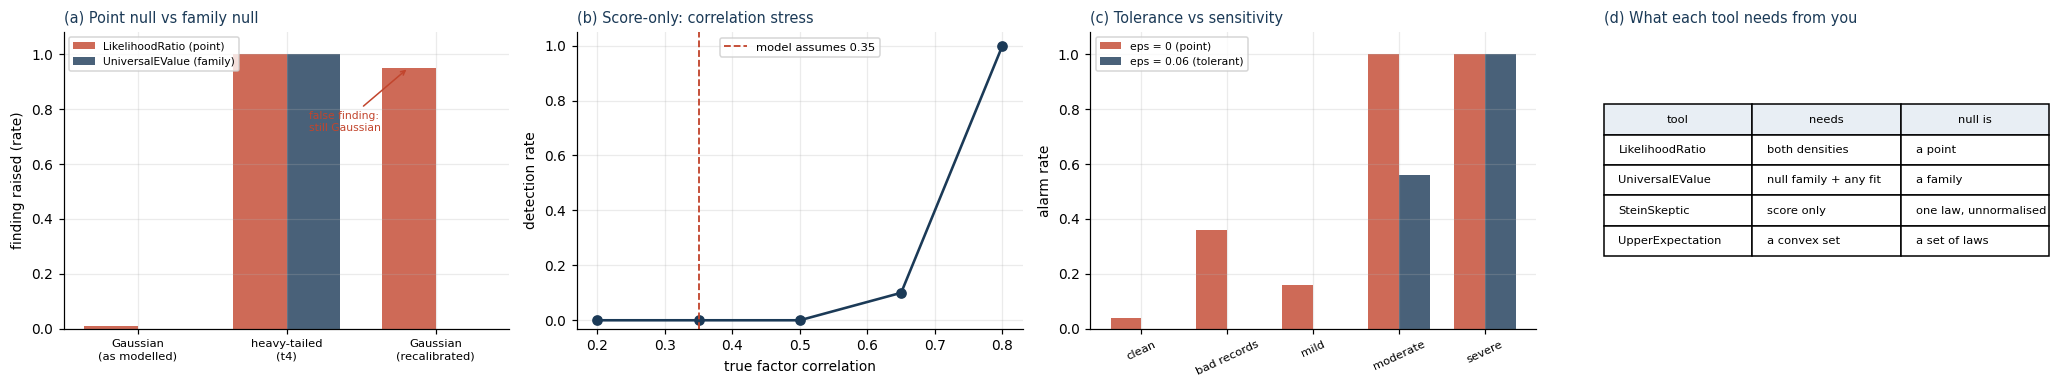

In [47]:
fig, ax = panels(4, ["Point null vs family null",
                     "Score-only: correlation stress",
                     "Tolerance vs sensitivity",
                     "What each tool needs from you"], ncols=4)

x = np.arange(len(nulls_df)); w = 0.36
ax[0].bar(x - w / 2, nulls_df.point_null, w, color=WARN, alpha=0.8, label="LikelihoodRatio (point)")
ax[0].bar(x + w / 2, nulls_df.family_null, w, color=INK, alpha=0.8, label="UniversalEValue (family)")
ax[0].set_xticks(x); ax[0].set_xticklabels(["Gaussian\n(as modelled)", "heavy-tailed\n(t4)",
                                            "Gaussian\n(recalibrated)"], fontsize=7.5)
ax[0].set_ylabel("finding raised (rate)"); ax[0].set_ylim(0, 1.08); ax[0].legend(fontsize=7)
ax[0].annotate("false finding:\nstill Gaussian", xy=(2 - w / 2, nulls_df.point_null.iloc[2]),
               xytext=(1.15, 0.72), fontsize=7, color=WARN,
               arrowprops=dict(arrowstyle="->", color=WARN, lw=1))

ax[1].plot(stein_df.true_corr, stein_df.rate, "o-", color=INK, lw=1.7, ms=6)
ax[1].axvline(MODEL_CORR, color=WARN, ls="--", lw=1.2, label=f"model assumes {MODEL_CORR}")
ax[1].set_xlabel("true factor correlation"); ax[1].set_ylabel("detection rate")
ax[1].set_ylim(-0.03, 1.05); ax[1].legend(fontsize=7.5)

xs = np.arange(len(cont_df)); w = 0.36
ax[2].bar(xs - w / 2, cont_df.eps_0, w, color=WARN, alpha=0.8, label="eps = 0 (point)")
ax[2].bar(xs + w / 2, cont_df.eps_tol, w, color=INK, alpha=0.8,
          label=f"eps = {DATA_ERROR_RATE} (tolerant)")
ax[2].set_xticks(xs); ax[2].set_xticklabels(cont_df.scenario, rotation=25, fontsize=7.5)
ax[2].set_ylabel("alarm rate"); ax[2].set_ylim(0, 1.08); ax[2].legend(fontsize=7)

ax[3].axis("off")
table = [["tool", "needs", "null is"],
         ["LikelihoodRatio", "both densities", "a point"],
         ["UniversalEValue", "null family + any fit", "a family"],
         ["SteinSkeptic", "score only", "one law, unnormalised"],
         ["UpperExpectation", "a convex set", "a set of laws"]]
tb = ax[3].table(cellText=table[1:], colLabels=table[0], loc="center", cellLoc="left")
tb.auto_set_font_size(False); tb.set_fontsize(7.5); tb.scale(1, 1.7)
for j in range(3):
    tb[0, j].set_facecolor("#e8eef4")
plt.tight_layout(); plt.show()

**Panel (a)** is the finding to take to a model-risk committee. The third pair of bars is a
false finding produced by a *perfectly valid test* asked the wrong question.

**Panel (b)** is the operating characteristic of a score-only monitor, and it should be read
as a warning as much as a capability. Detection is flat at zero across the whole lower half
of the ladder - including the rungs *below* the model's assumption, which are genuine
misspecifications too - and only becomes reliable once the correlation has moved a long way
above what the model charges for.

That is the price of asking a question with so little information. A score-only test knows
nothing about the model except its gradient, so it needs a large departure and a long
horizon. **If you can evaluate a density, do not use this.** Use it when the model genuinely
will not give you one, and size the review period from this curve rather than from hope.

**Panel (c)** prices the tolerance. Moving from $\varepsilon = 0$ to $\varepsilon = 0.06$
kills the false alarm on bad records - and visibly reduces sensitivity to genuine credit
deterioration. **You are buying data-quality immunity with detection power, and this panel
is the exchange rate.** That number belongs in the monitoring design document.

## 9.9 Conclusion and runbook

1. **Write the null class from the policy document, not from convenience.** If policy says
   "Gaussian", a point null will manufacture findings on routine recalibration.
2. Use `LikelihoodRatioEValue` only when you genuinely mean a point null and have a specific
   challenger. It is the fastest instrument here and the easiest to misuse.
3. Use `UniversalEValue` for composite nulls. Any $D_1$-measurable estimator is admissible
   for the numerator, so use your best model - but the denominator **must** be the real null
   MLE.
4. Use `SteinSkeptic` when the model only exposes a score. Do not use it on autocorrelated
   output such as an MCMC chain; the null is the conditional law given the past.
5. Use `upperexp` when operations can quantify an irreducible contamination rate. Set
   $\varepsilon$ from their number, then publish panel (c) so everyone sees what it cost.

## 9.10 "How far has it drifted?" - a certified distance, not a verdict

Every tool so far answers *whether* the model is wrong. A validation committee's next
question is always **how wrong**, because the remediation budget scales with it. Section 1
answered that for a mean; `upperexp` answers it for a whole distribution.

`WassersteinDistanceSequence` runs one e-process per radius on a grid and reports the
smallest radius not yet rejected. That value is an **anytime-valid lower bound on the true
$W_1$ distance** between the live rating-migration distribution and the policy one. "The
book has moved by at least 0.4 rating notches, and that holds however often we looked" is a
sentence a committee can size a provision against.

**Where to use it:** any monitoring problem where the threshold is a *tolerance* rather than
a hypothesis - reserving margins, model-risk appetite, SLA drift budgets.

In [48]:
from expectation.upperexp.nulls import (
    PolytopeNull, RIPrResult, UpperExpectationNull, WassersteinNull, growth_rate,
)
from expectation.upperexp.skeptic import DistanceSequenceResult, WassersteinDistanceSequence

# Cost of moving one rating notch. W1 is then measured in notches - a unit the
# committee already uses, which is most of why this is worth doing.
NOTCH_COST = np.abs(np.arange(BUCKETS)[:, None] - np.arange(BUCKETS)[None, :]).astype(float)
TOLERANCE_NOTCHES = 0.25          # model risk appetite, agreed in advance

live_book = migration_law("moderate")
true_w1 = WassersteinNull(POLICY_MIGRATION, NOTCH_COST, 0.0).wasserstein_distance(live_book)

dist_seq = WassersteinDistanceSequence(
    POLICY_MIGRATION, NOTCH_COST, radii=np.linspace(0.0, 0.8, 17),
    significance_level=ALPHA,
)
r_, bound_path = np.random.default_rng(63), []
for _ in range(1_500):
    step = dist_seq.update(int(r_.choice(BUCKETS, p=live_book)))
    bound_path.append(step.lower_bound)
assert isinstance(step, DistanceSequenceResult)

breach = next((i + 1 for i, b in enumerate(bound_path) if b > TOLERANCE_NOTCHES), None)
print(f"model risk appetite            : {TOLERANCE_NOTCHES:.2f} notches")
print(f"certified lower bound at 1,500 : {step.lower_bound:.3f} notches")
print(f"point estimate of the drift    : {step.wasserstein_estimate:.3f} notches")
print(f"true drift, revealed now       : {true_w1:.3f} notches")
print(f"tolerance provably breached at : account {breach if breach else 'not within 1,500'}")
print(f"radii rejected so far          : {len(step.rejected_radii)} of 17 on the grid")

model risk appetite            : 0.25 notches
certified lower bound at 1,500 : 0.400 notches
point estimate of the drift    : 0.469 notches
true drift, revealed now       : 0.435 notches
tolerance provably breached at : account 436
radii rejected so far          : 8 of 17 on the grid


## 9.11 "Is the book still a mixture of regimes we underwrite?"

A different question again, and a very common one in credit: the bank models three named
regimes - benign, slowdown, stress. The policy null is not one distribution but **any
mixture** of them, because a book that is 30% stressed is still a book the model covers.

That is a polytope, and `PolytopeNull` tests it. Rejection here means something sharper than
"the distribution moved": it means the book is **outside the convex hull of every regime you
underwrite**, so no reweighting of your existing scenarios can explain it. That is precisely
the trigger for building a new scenario rather than recalibrating weights.

The projection also hands you the diagnosis for free: `reverse_information_projection`
returns the closest in-hull mixture, so you can report "the nearest thing we do model is 32%
benign / 68% stress, and the book is still 0.02 nats away from it."

In [49]:
REGIMES = {
    "benign":    np.array([0.62, 0.24, 0.10, 0.03, 0.01]),
    "slowdown":  np.array([0.48, 0.27, 0.15, 0.07, 0.03]),
    "stress":    np.array([0.30, 0.26, 0.22, 0.14, 0.08]),
}
regime_null = PolytopeNull(vertices=np.vstack(list(REGIMES.values())))

for label, observed in [("a 50/50 benign-stress book (inside the hull)",
                         0.5 * REGIMES["benign"] + 0.5 * REGIMES["stress"]),
                        ("the live book from 9.10 (outside?)", live_book)]:
    inside = regime_null.contains(observed)
    rip = regime_null.reverse_information_projection(observed)
    assert isinstance(regime_null, UpperExpectationNull) and isinstance(rip, RIPrResult)
    e_var = regime_null.optimal_e_variable(observed)
    print(f"{label}")
    print(f"  inside the modelled hull : {inside}")
    print(f"  nearest modelled mixture : "
          + ", ".join(f"{n} {w:.0%}" for n, w in zip(REGIMES, rip.weights)))
    print(f"  KL(book || nearest)      : {rip.kl_divergence:.4f} nats"
          f"   (converged={rip.converged} in {rip.n_iterations} EM steps)")
    print(f"  growth rate of the numeraire e-variable: {growth_rate(observed, e_var):.4f} nats/obs")
    print(f"  -> {'reweight existing scenarios' if inside else 'BUILD A NEW SCENARIO: no mixture explains this'}\n")

print("growth_rate equals the KL divergence above - that is the numeraire property")
print("(Larsson, Ramdas & Ruf 2025): the optimal e-variable's growth IS the divergence,")
print("so the same number sizes both the evidence and the model gap.")

a 50/50 benign-stress book (inside the hull)
  inside the modelled hull : True
  nearest modelled mixture : benign 43%, slowdown 11%, stress 46%
  KL(book || nearest)      : 0.0000 nats   (converged=False in 2000 EM steps)
  growth rate of the numeraire e-variable: -0.0000 nats/obs
  -> reweight existing scenarios

the live book from 9.10 (outside?)
  inside the modelled hull : False
  nearest modelled mixture : benign 31%, slowdown 0%, stress 69%
  KL(book || nearest)      : 0.0019 nats   (converged=False in 2000 EM steps)
  growth rate of the numeraire e-variable: 0.0019 nats/obs
  -> BUILD A NEW SCENARIO: no mixture explains this

growth_rate equals the KL divergence above - that is the numeraire property
(Larsson, Ramdas & Ruf 2025): the optimal e-variable's growth IS the divergence,
so the same number sizes both the evidence and the model gap.


## 9.12 Two more score-only tools, for two situations IMQ cannot handle

Section 9.6 used the IMQ kernel with a Gaussian target. Both of those are swappable, and the
alternatives exist for concrete reasons:

- **`WendlandSteinKernel`** has *compact support*. The Stein identity then holds for every
  $C^1$ positive density with **no moment condition at all**, and you only need a *local*
  Lipschitz constant on the support ball. **Use it when your model has heavy or unverified
  tails** - a fat-tailed loss model, a flow you did not fit yourself - where IMQ's global
  Lipschitz requirement is a claim you cannot make. The cost is real: compact support gives
  up IMQ's sensitivity to what happens far out in the tail (Gorham & Mackey 2017).
- **`BoltzmannTarget`** takes a potential gradient and an inverse temperature, which is the
  native form of any energy-based model. **`CallableScoreTarget`** wraps any score function
  you can write down. Between them, if you can differentiate a log-density you can test it.

In [50]:
from expectation.stein.kernels import SteinKernel, WendlandSteinKernel
from expectation.stein.skeptic import BoltzmannTarget, CallableScoreTarget, ScoreTarget

# (i) A target defined only by a score function - the general escape hatch.
CORR = MODEL_CORR
PREC = np.linalg.inv(np.array([[1.0, CORR], [CORR, 1.0]]))
callable_target = CallableScoreTarget(
    score=lambda x: -np.asarray(x) @ PREC, dim=2,
    lipschitz=float(np.linalg.norm(PREC, 2)),         # ||grad score||, needed by IMQ
    name="risk factors via score only",
)

# (ii) An energy-based model: give the gradient of the potential and a temperature.
boltzmann = BoltzmannTarget(
    grad_potential=lambda x: np.asarray(x) @ PREC, beta=1.0, dim=2,
    lipschitz_grad_potential=float(np.linalg.norm(PREC, 2)),
)

# (iii) A compactly supported kernel: no moment condition on the model.
wendland = WendlandSteinKernel(dim=2, radius=3.0)
imq = IMQSteinKernel(dim=2)
for k in (wendland, imq):
    assert isinstance(k, SteinKernel)
for t in (callable_target, boltzmann):
    assert isinstance(t, ScoreTarget)

print("kernel constants (these are what make the e-value provably non-negative):")
for name, k in [("IMQ (global tails)", imq), ("Wendland (compact, radius 3)", wendland)]:
    print(f"  {name:30} " + ", ".join(f"{v:.4f}" for v in k.bound_constants()))

print("\nthe same validation question, three ways of supplying the model:")
for label, target, kernel in [
    ("GaussianTarget  + IMQ", target, imq),
    ("CallableScore   + IMQ", callable_target, imq),
    ("BoltzmannTarget + Wendland", boltzmann, wendland),
]:
    sk = SteinSkeptic(target=target, kernel=kernel, max_reference_size=120)
    proto = BettingProtocol(sk, EProcessConfig(
        significance_level=ALPHA, betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=1.0))
    r_ = np.random.default_rng(515)
    stressed = np.array([[1.0, 0.80], [0.80, 1.0]])
    for _ in range(200):
        proto.update(r_.multivariate_normal(MODEL_MEAN, stressed))
    print(f"  {label:28} log capital {proto.e_process.log_process_values[-1]:+8.2f}"
          f"   stop {proto.stopping_time}")
print("\nSame verdict from three different descriptions of the same model. Pick whichever")
print("one your modelling team can actually hand you - that is the entire selection rule.")

kernel constants (these are what make the e-value provably non-negative):
  IMQ (global tails)             1.0000, 1.0000, 0.3849, 0.0358
  Wendland (compact, radius 3)   1.0000, 0.4787, 0.6912, 0.3556

the same validation question, three ways of supplying the model:
  GaussianTarget  + IMQ        log capital    +3.03   stop 199


  CallableScore   + IMQ        log capital    +3.03   stop 199


  BoltzmannTarget + Wendland   log capital    +4.58   stop 156

Same verdict from three different descriptions of the same model. Pick whichever
one your modelling team can actually hand you - that is the entire selection rule.


## 9.13 When the e-value is yours: the `EValue` ABC

Everything above is a supplied test. The last extension point is the one you use when your
null is genuinely bespoke: subclass `EValue`, implement `compute`, and you inherit
`test()`, the significance check, the infinity guard and the frozen `EValueResult`.

**Where this belongs:** a batch e-value you will compute repeatedly and want typed,
validated and logged - a regulator-specified statistic, an internal risk metric. For a
*streaming* bet, use `SkepticStrategy` (Section 5) instead; for a *batch* one, use this.

In [51]:
from expectation.modules.hypothesistesting import EValue, EValueResult


class ExceedanceEValue(EValue):
    """Bets that tail exceedances are more frequent than the model allows.

    A regulator-style backtest: under H0 at most `rate` of observations breach the
    model's VaR level. Under H0 the count is Binomial(n, rate), so the likelihood
    ratio against a stated alternative rate is a valid e-value.
    """

    def __init__(self, null_hypothesis, var_level, null_rate, alt_rate, config=None):
        super().__init__(null_hypothesis, config)
        self.var_level, self.null_rate, self.alt_rate = var_level, null_rate, alt_rate

    def compute(self, data):
        breaches = int(np.sum(np.asarray(data) < self.var_level))
        n = len(data)
        log_e = (breaches * (np.log(self.alt_rate) - np.log(self.null_rate))
                 + (n - breaches) * (np.log1p(-self.alt_rate) - np.log1p(-self.null_rate)))
        return float(np.exp(log_e))


backtest = ExceedanceEValue(
    Hypothesis(name="VaR breaches occur at the modelled rate", type=HypothesisType.SIMPLE),
    var_level=-2.33, null_rate=0.01, alt_rate=0.025,          # 99% VaR, alternative 2.5%
    config=EValueConfig(significance_level=ALPHA),
)

r_ = np.random.default_rng(71)
for label, gen in [("model is right (t-quantile respected)", lambda n: r_.normal(0, 1, n)),
                   ("fat tails: true sigma 1.15", lambda n: r_.normal(0, 1.15, n))]:
    result = backtest.test(gen(2_000))
    assert isinstance(result, EValueResult)
    print(f"{label:38} e-value {result.value:>12.4g}   significant={result.significant}")
print(f"\nthe frozen result object carries its own provenance: "
      f"hypothesis='{backtest.result.hypothesis.name}', n={backtest.result.sample_size}")

model is right (t-quantile respected)  e-value    1.629e-07   significant=False
fat tails: true sigma 1.15             e-value        3.121   significant=False

the frozen result object carries its own provenance: hypothesis='VaR breaches occur at the modelled rate', n=2000


---
# 10. Telecom network operations: 3,000 cells, two speeds, and alarms that must not stop the clock

## 10.1 The domain

A mobile operator's Network Operations Centre watches roughly 3,000 radio cells. Each cell
reports a daily KPI - here, the deviation in call-setup success rate against its own
baseline. Something is always slightly wrong somewhere; the NOC's problem is not detection,
it is **triage**.

Three genuinely different decisions come off the same data stream, and they need different
statistical guarantees:

1. **Tomorrow's field-engineering queue.** A truck roll costs a few hundred euros and is
   completely reversible. You want the largest useful list; a few wasted visits are fine.
2. **A vendor warranty claim.** You are formally asserting that a hardware unit is
   defective. That is contractual, adversarial, and **must never be withdrawn** - an alert
   that fires on Tuesday and evaporates on Thursday destroys the NOC's credibility with the
   vendor permanently.
3. **"Is anything wrong with the network tonight?"** One number for the duty manager.

And then a fourth requirement that is really an engineering constraint: **the monitors must
keep running after they fire.** An e-process that crosses $1/\alpha$ has done its job, but
the cell is still there tomorrow. You need something with restart semantics.

**What the mistake costs.** Wrong on (1) is a wasted truck. Wrong on (2) is a commercial
relationship. Missing (3) is an outage.

## 10.2 Designing the study

Decisions 1 and 2 differ in exactly one property: **whether a rejection may be taken back.**

- **e-BH** (`e_bh`) controls FDR and is evaluated at the moment you look. Perfect for the
  reversible queue.
- **Adjusted e-BH** (`adjusted_e_bh`) applies an admissible adjuster $A$ to the **running
  maximum** of each e-process before selecting (Tavyrikov, Goeman & de Heide 2025). An
  admissible adjuster satisfies $\int_1^\infty A(E)/E^2\,dE = 1$, and the effect is that a
  rejection, once made, stays made. This is called **carefree** multiple testing, and it is
  strictly more conservative - which is the point.

Decision 3 is a **global merge**: combine the 3,000 per-step e-values spatially into one
e-value for the intersection null, then accumulate it temporally.

| Contract part | This study |
|---|---|
| **Null class** | Per cell: "this cell's KPI deviation has mean $\ge 0$". Globally: "no cell has degraded". |
| **Filtration** | Daily, shared across all 3,000 tests - a common clock is required for the merge. |
| **Clock** | One day. |
| **Downstream use** | **Three different ones**, which is why three rules are needed. |

## 10.3 Assumptions, stated explicitly

| We assume | Why reasonable | If false |
|---|---|---|
| Cells are conditionally independent given their own state | Different hardware, different sites | A shared backhaul failure correlates them; the arithmetic-mean merge stays valid, the product merge does not |
| A common daily clock across all cells | The KPI pipeline is batch-daily | Ragged arrival breaks the merge's step alignment |
| KPI deviation is standardised per cell | Each cell is scored against its own baseline | Heterogeneous scales make one variance setting wrong for most cells |

## 10.4 The data-generating mechanism

The degraded set is **drawn**, not chosen: each cell independently degrades with a small
probability, and the size of each degradation is itself drawn. The NOC does not know how
many there are - that is the entire problem - and the truth is revealed only after every
rule has reported.

## 10.5 Which capabilities, and why

| Used | Why this one | Alternative, and why not |
|---|---|---|
| `par_seqtest.ParallelSequentialTest` | 3,000 simultaneous e-processes on the Rust engine, one `step()` per day | A Python loop over 3,000 `SequentialTesting` objects is orders of magnitude slower |
| `.e_bh()` | FDR control for the reversible queue | - |
| `.adjusted_e_bh()` (`modules.adjusters`) | Rejections that never un-fire, for the vendor claim | Plain e-BH can withdraw a rejection later |
| `global_merge="arithmetic_mean"` | One duty-manager number, valid under arbitrary dependence between cells | `product` needs independence across cells, which a shared backhaul destroys |
| `conformal.ConformalCUSUM` | Restart semantics: keeps monitoring after an alarm | An e-process is monotone in evidence and does not reset by design |

In [52]:
import time

from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig

# --- fixed from NOC operations BEFORE any data --------------------------------
N_CELLS = 3_000
WATCH_DAYS = 60                 # one maintenance planning cycle
DEGRADE_PROB = 0.02             # prior belief: ~2% of cells develop a fault in a cycle

# --- the world: which cells degrade, and by how much, are BOTH drawn ----------
world = np.random.default_rng(17)
is_degraded = world.random(N_CELLS) < DEGRADE_PROB
severity = np.zeros(N_CELLS)
severity[is_degraded] = np.clip(world.normal(0.35, 0.12, int(is_degraded.sum())), 0.05, None)

noc = ParallelSequentialTest(
    config=ParallelTestConfig(
        n_tests=N_CELLS, alpha=ALPHA,
        alternative="less",                       # degradation = KPI deviation below zero
        global_merge="arithmetic_mean",           # valid under arbitrary dependence
        merge_combiner="all_in",
    ),
    null_values=0.0, variance=1.0,
)

kpi = np.random.default_rng(18)
merged_path, t0 = [], time.time()
for day in range(WATCH_DAYS):
    deviation = kpi.standard_normal(N_CELLS) - severity     # standardised daily KPI deviation
    step = noc.step(deviation)
    merged_path.append(step.log_merged_e_process)
elapsed = time.time() - t0

print(f"{N_CELLS:,} cells x {WATCH_DAYS} days = {N_CELLS * WATCH_DAYS:,} e-process updates")
print(f"  wall clock: {elapsed:.2f}s  ({N_CELLS * WATCH_DAYS / max(elapsed, 1e-9):,.0f} updates/sec, Rust engine)")

3,000 cells x 60 days = 180,000 e-process updates
  wall clock: 0.02s  (10,359,148 updates/sec, Rust engine)


In [53]:
truth = set(np.flatnonzero(is_degraded).tolist())
evidence = noc.log_e_processes()
ranking = np.argsort(evidence)[::-1]

print(f"{'rule':<34} {'named':>6} {'correct':>8} {'false':>6}   decision it supports")
print("-" * 96)
for label, res, use in [
    ("e_bh (FDR)", noc.e_bh(), "tomorrow's truck rolls"),
    ("e_bonferroni (FWER)", noc.e_bonferroni(), "stricter queue"),
    ("e_holm", noc.e_holm(), "stricter queue"),
    ("adjusted_e_bh (carefree)", noc.adjusted_e_bh(), "vendor warranty claim"),
    ("adjusted_e_bonferroni (carefree)", noc.adjusted_e_bonferroni(), "vendor warranty claim"),
]:
    sel = set(np.flatnonzero(res.rejected).tolist())
    print(f"{label:<34} {res.n_rejected:>6} {len(sel & truth):>8} {len(sel - truth):>6}   {use}")

top_k = 40
print(f"\nranking by raw evidence (no error control): top {top_k} contains "
      f"{len(set(ranking[:top_k].tolist()) & truth)} genuinely degraded cells")
print(f"\nduty-manager alarm  : merged e-process = {np.exp(min(merged_path[-1], 700)):.4g}"
      f"   -> {'NETWORK-LEVEL ALARM' if noc.merged_rejected() else 'no network-level alarm'}")
print(f"truth, revealed now : {int(is_degraded.sum())} of {N_CELLS:,} cells actually degraded")

rule                                named  correct  false   decision it supports
------------------------------------------------------------------------------------------------
e_bh (FDR)                              5        5      0   tomorrow's truck rolls
e_bonferroni (FWER)                     4        4      0   stricter queue
e_holm                                  4        4      0   stricter queue
adjusted_e_bh (carefree)                1        1      0   vendor warranty claim
adjusted_e_bonferroni (carefree)        1        1      0   vendor warranty claim

ranking by raw evidence (no error control): top 40 contains 25 genuinely degraded cells

duty-manager alarm  : merged e-process = 1.244   -> no network-level alarm
truth, revealed now : 58 of 3,000 cells actually degraded


### What makes it "carefree": the adjuster, and why it names fewer cells

`adjusted_e_bh` is not just a stricter threshold. It applies an **admissible adjuster**
$A$ to each test's *running maximum* before selecting. Admissibility is a single integral
condition (Tavyrikov, Goeman & de Heide 2025):

$$\int_1^{\infty} \frac{A(E)}{E^2}\,dE = 1 .$$

That condition is exactly what pays for using the running maximum - i.e. for being allowed
to look at every past moment at once - and it is why a rejection can never be withdrawn.
The library ships two, and since the condition is a plain integral we verify it rather than
trust it. `modules.adjusters` exposes them directly, in both natural and log space.

In [54]:
from scipy import integrate

from expectation.modules.adjusters import (
    AdjusterConfig, AdjusterFunction, LookbackAdjuster, SqrtAdjuster, create_adjuster,
)

adjusters = {"lookback  A(E)=(E-1-lnE)/(lnE)^2": LookbackAdjuster(),
             "sqrt      A(E)=sqrt(E)-1": SqrtAdjuster()}

print("admissibility check: integral of A(E)/E^2 from 1 to infinity must equal 1\n")
for name, adj in adjusters.items():
    val, err = integrate.quad(lambda e: adj.adjust(e) / e**2, 1.0, np.inf, limit=400)
    print(f"  {name:36} = {val:.6f}  (quad error {err:.1e})")

print("\nwhat an adjuster does to real evidence (E is a running maximum):")
probe = np.array([1.0, 2.0, 5.0, 20.0, 100.0, 1_000.0])
print(f"  {'E':>10} {'lookback A(E)':>15} {'sqrt A(E)':>12}")
for e in probe:
    print(f"  {e:>10.0f} {LookbackAdjuster().adjust(e):>15.3f} {SqrtAdjuster().adjust(e):>12.3f}")
print("\nA(E) < E everywhere, and the shortfall is the premium you pay for a rejection")
print("that never has to be withdrawn. Note A(E) = 0 for E <= 1: no evidence, no credit.")

# The same adjusters the Rust engine applies - run them on this NOC's running maxima.
max_log_m = noc.max_log_m()
for label, adj in [("lookback", LookbackAdjuster()), ("sqrt", SqrtAdjuster())]:
    adjusted = adj.log_adjust(max_log_m)
    survives = int(np.sum(adjusted > np.log(THRESHOLD)))
    raw = int(np.sum(max_log_m > np.log(THRESHOLD)))
    print(f"\n  {label:9}: {raw} cells exceed 1/alpha on the raw running maximum, "
          f"{survives} still exceed it after adjustment")
print(f"\n  (log_adjust() works in log space, so it is safe when max_log_m is large:")
print(f"   the largest running maximum in this network is exp({max_log_m.max():.1f}).)")

admissibility check: integral of A(E)/E^2 from 1 to infinity must equal 1

  lookback  A(E)=(E-1-lnE)/(lnE)^2     = 0.999084  (quad error 1.7e-06)
  sqrt      A(E)=sqrt(E)-1             = 1.000000  (quad error 9.2e-15)

what an adjuster does to real evidence (E is a running maximum):
           E   lookback A(E)    sqrt A(E)
           1           0.000        0.000
           2           0.639        0.414
           5           0.923        1.236
          20           1.783        3.472
         100           4.451        9.000
        1000          20.791       30.623

A(E) < E everywhere, and the shortfall is the premium you pay for a rejection
that never has to be withdrawn. Note A(E) = 0 for E <= 1: no evidence, no credit.

  lookback : 79 cells exceed 1/alpha on the raw running maximum, 11 still exceed it after adjustment

  sqrt     : 79 cells exceed 1/alpha on the raw running maximum, 16 still exceed it after adjustment

  (log_adjust() works in log space, so it is safe when 

### Read the carefree row honestly

The adjusted rules are **designed** to name fewer cells, and on a 60-day window they may
well name none at all. That is not a failure - it is the rule declining to make an
irreversible assertion on the evidence available, which is precisely the behaviour you want
from something that files a warranty claim.

The operational answer is not to loosen the rule. It is to run the carefree rule on a
**longer** window than the reversible one: truck rolls daily off `e_bh`, warranty claims
quarterly off `adjusted_e_bh`.

### And the global merge

The merged e-process answers a different question from every per-cell rule. It tests the
*intersection* null - "no cell anywhere has degraded" - by merging all 3,000 per-step
e-values into one and compounding. It can fire when no individual cell is separately
identifiable, which is exactly the diffuse-degradation case that per-cell testing misses.
It also **cannot tell you which cell**, which is why you run both.

## 10.6 Monitors that survive their own alarms

Every e-process so far is monotone in evidence: once it crosses $1/\alpha$ it has made a
permanent statement. For a NOC that is wrong, because the cell is still there tomorrow.

`conformal.ConformalCUSUM` provides restart semantics: it accumulates the same e-values,
raises an alarm at a threshold, and **resets**, so it can alarm repeatedly over a long
horizon. `AdaptiveThresholdHandler` tunes that threshold towards a target alarm rate - the
NOC's real constraint is how many alarms a shift can action, not a $p$-value.

*(`expectation.conformal` is an experimental module and emits a `UserWarning` on import; the
library's own audit flags open questions in its capital-floor and recurrence details. Treat
its output as an operational heuristic layered on top of the validated e-values, not as a
second error guarantee.)*

In [55]:
from expectation.conformal.adaptivethreshold import AdaptiveThresholdHandler
from expectation.conformal.cusum import ConformalCUSUM

worst_cell = int(np.argmax(noc.log_e_processes()))
healthy_cell = int(np.argmin(np.abs(noc.log_e_processes())))

CUSUM_THRESHOLD = 20.0    # matches 1/alpha, so the first alarm is comparable
LONG_HORIZON = 240        # four maintenance cycles of continuous operation


def daily_evalue(rng, severity_level, n=40):
    """One cell-day: run a real mean e-test on that day's KPI sample."""
    t_ = SequentialTesting(TestType.MEAN, null_value=0.0, alternative=AlternativeType.LESS,
                           known_variance=1.0, config=EValueConfig(significance_level=ALPHA))
    return float(t_.update(rng.standard_normal(n) - severity_level)
                 .e_process.process_values[-1])


def replay_cusum(cell, threshold=CUSUM_THRESHOLD, use_sr=False):
    """Replay one cell's daily e-values through a RESTARTABLE detector."""
    det = ConformalCUSUM(threshold=threshold, use_sr=use_sr)
    r_, state = np.random.default_rng(1234 + cell), None
    for _ in range(LONG_HORIZON):
        state = det.update(daily_evalue(r_, severity[cell]))   # -> CUSUMResultState
    # all_stats holds the statistic BEFORE the post-alarm reset, so spikes stay visible.
    return det, state, np.asarray(state.all_stats, dtype=float)


det_bad, state_bad, stats_bad = replay_cusum(worst_cell)
det_ok, state_ok, stats_ok = replay_cusum(healthy_cell)
print(f"over {LONG_HORIZON} days of continuous monitoring (the detector resets after each alarm):")
print(f"  degraded cell {worst_cell:<5} (severity {severity[worst_cell]:.2f}): "
      f"{state_bad.n_alarms:3d} alarms, rate {det_bad.get_alarm_rate():.3f}")
print(f"  healthy  cell {healthy_cell:<5} (severity {severity[healthy_cell]:.2f}): "
      f"{state_ok.n_alarms:3d} alarms, rate {det_ok.get_alarm_rate():.3f}")

# The NOC's real constraint is alarms per shift, so tune the threshold TO that rate.
# AdaptiveThresholdHandler.update() takes the OBSERVED rate and returns a new threshold.
handler = AdaptiveThresholdHandler(target_false_alarm_rate=0.02, learning_rate=0.05,
                                   min_threshold=2.0, max_threshold=500.0)
det = ConformalCUSUM(threshold=handler.threshold)
r_, thresholds, seen_alarms = np.random.default_rng(99), [], 0
for day in range(LONG_HORIZON):
    det.threshold = handler.threshold
    st = det.update(daily_evalue(r_, 0.0))          # a HEALTHY cell: any alarm is false
    handler.record_alarm(st.n_alarms > seen_alarms)
    seen_alarms = st.n_alarms
    handler.update(handler.get_current_rate())
    thresholds.append(handler.threshold)
print(f"\nadaptive threshold on a healthy cell: {thresholds[0]:.1f} -> {thresholds[-1]:.1f}"
      f"   (target false-alarm rate {handler.target_rate:.0%}, "
      f"achieved {handler.get_current_rate():.3f})")

over 240 days of continuous monitoring (the detector resets after each alarm):
  degraded cell 60    (severity 0.51):  27 alarms, rate 0.113
  healthy  cell 2037  (severity 0.00):   0 alarms, rate 0.000

adaptive threshold on a healthy cell: 10.0 -> 7.9   (target false-alarm rate 2%, achieved 0.000)


## 10.7 Reading the output

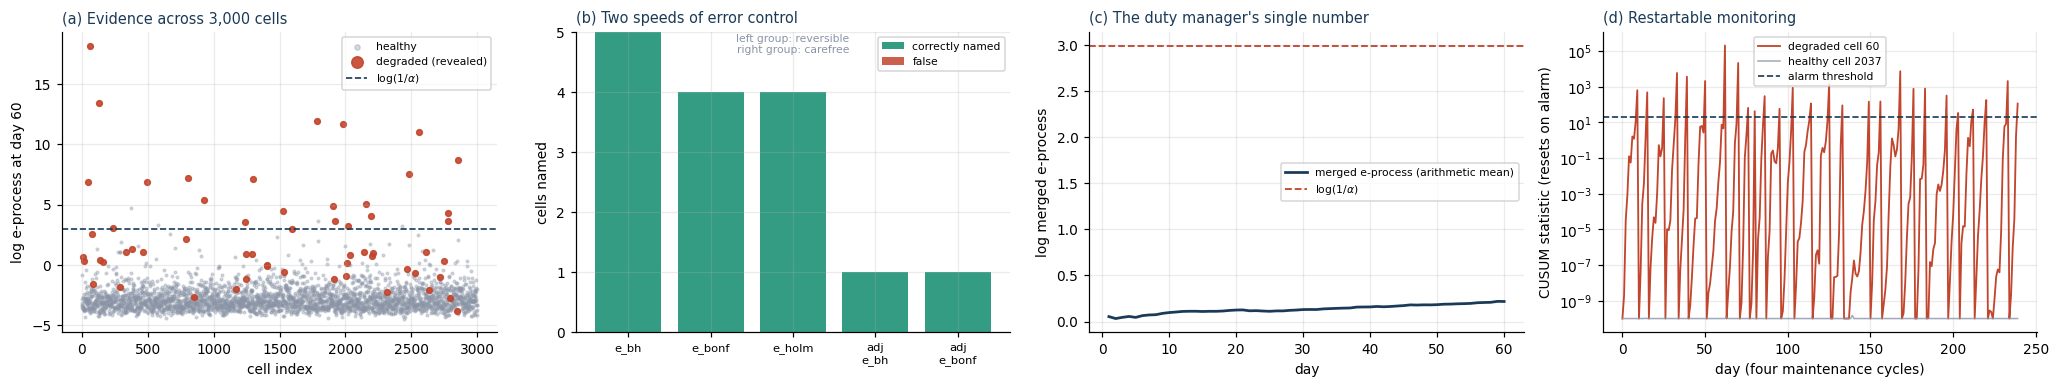

In [56]:
fig, ax = panels(4, ["Evidence across 3,000 cells",
                     "Two speeds of error control",
                     "The duty manager's single number",
                     "Restartable monitoring"], ncols=4)

ax[0].scatter(np.arange(N_CELLS)[~is_degraded], evidence[~is_degraded], s=3, color=MUTE,
              alpha=0.35, label="healthy")
ax[0].scatter(np.arange(N_CELLS)[is_degraded], evidence[is_degraded], s=14, color=WARN,
              alpha=0.9, label="degraded (revealed)")
ax[0].axhline(np.log(THRESHOLD), color=INK, ls="--", lw=1.1, label=r"$\log(1/\alpha)$")
ax[0].set_xlabel("cell index"); ax[0].set_ylabel("log e-process at day 60")
ax[0].legend(fontsize=7, markerscale=2)

rules = ["e_bh", "e_bonf", "e_holm", "adj\ne_bh", "adj\ne_bonf"]
results = [noc.e_bh(), noc.e_bonferroni(), noc.e_holm(),
           noc.adjusted_e_bh(), noc.adjusted_e_bonferroni()]
correct = [len(set(np.flatnonzero(r.rejected).tolist()) & truth) for r in results]
false_ = [r.n_rejected - c for r, c in zip(results, correct)]
xs = np.arange(len(rules))
ax[1].bar(xs, correct, color=EVID, alpha=0.85, label="correctly named")
ax[1].bar(xs, false_, bottom=correct, color=WARN, alpha=0.85, label="false")
ax[1].set_xticks(xs); ax[1].set_xticklabels(rules, fontsize=7.5)
ax[1].set_ylabel("cells named"); ax[1].legend(fontsize=7)
ax[1].text(0.5, 0.93, "left group: reversible\nright group: carefree",
           transform=ax[1].transAxes, ha="center", fontsize=7, color=MUTE)

ax[2].plot(np.arange(1, WATCH_DAYS + 1), merged_path, color=INK, lw=1.8,
           label="merged e-process (arithmetic mean)")
ax[2].axhline(np.log(THRESHOLD), color=WARN, ls="--", lw=1.2, label=r"$\log(1/\alpha)$")
ax[2].set_xlabel("day"); ax[2].set_ylabel("log merged e-process"); ax[2].legend(fontsize=7)

ax[3].plot(stats_bad, color=WARN, lw=1.2, label=f"degraded cell {worst_cell}")
ax[3].plot(stats_ok, color=MUTE, lw=1.0, alpha=0.8, label=f"healthy cell {healthy_cell}")
ax[3].axhline(CUSUM_THRESHOLD, color=INK, ls="--", lw=1.1, label="alarm threshold")
ax[3].set_yscale("log"); ax[3].set_xlabel("day (four maintenance cycles)")
ax[3].set_ylabel("CUSUM statistic (resets on alarm)"); ax[3].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Panel (a)** is the NOC's world. Most cells sit in the grey band doing nothing
interesting; the red points are the ones that actually degraded, revealed only now. Note
the overlap - some degraded cells have accumulated no more evidence than healthy ones,
which is the honest reason no rule can name all of them.

**Panel (b)** is the two-speed design. The left group names more cells and is *permitted*
to include some false ones; the right group names far fewer and will never take a name back.
**These are not competing methods - they support different decisions on the same day.**

**Panel (c)** is the duty manager's number, and in this run it is also a lesson. The per-cell
rules named several genuinely degraded cells, yet the merged e-process barely moved. That is
not a contradiction: the arithmetic-mean merge averages over all 3,000 streams, so evidence
concentrated in a handful of cells is divided by $K$ and largely washes out.

The merge is built for the **opposite** regime - a small, diffuse push across many cells that
no individual test can resolve. Run both, and understand which one is blind to your failure
mode: **per-cell testing misses diffuse degradation, and the global merge misses concentrated
degradation.** If your network fails in a sparse-but-strong way, `merging.SparseMixtureMerger`
(Section 12) is the merge designed for it.

**Panel (d)** is the restart behaviour. The degraded cell's statistic climbs, alarms, drops
to its floor, and climbs again - so the cell is still monitored on day 200. The healthy
cell's statistic wanders near the floor.

## 10.8 Conclusion and runbook

1. **Match the rule to the reversibility of the decision.** `e_bh` for truck rolls,
   `adjusted_e_bh` for anything contractual.
2. Expect the carefree list to be short or empty on a short window. Run it on a longer
   cycle rather than loosening it.
3. Add `global_merge="arithmetic_mean"` for the duty-manager number. Only use `product` if
   you can genuinely certify independence across cells, which in a shared-backhaul network
   you cannot.
4. Use the ranking (`log_e_processes()`) for capacity-bounded triage: "give me the top 40"
   is a resourcing question, not a statistical one.
5. Layer `ConformalCUSUM` on top for continuous operation, and tune its threshold to the
   alarm rate a shift can action. Keep the validated e-processes as the system of record.

## 10.9 The merge built for "a few cells are broken, and I do not know how many"

Section 10.7 showed the arithmetic-mean merge going quiet while per-cell testing named real
faults. That is the arithmetic mean's known blind spot: it divides concentrated evidence by
$K$. The fix is not a different threshold, it is a **different merge**.

`SparseMixtureMerger` (Pérez-Ortiz, Castro & Stoepker 2025) mixes over the *unknown fraction*
of broken streams instead of averaging over all of them. It puts a prior on sparsity, updates
it from the data, and merges accordingly.

**Where you reach for it:** exactly the NOC's situation - thousands of streams, a handful
genuinely faulty, and no idea in advance how many. It also gives you something the other
merges cannot: a posterior over *how widespread* the problem is, which is the difference
between paging one engineer and waking the incident commander.

**Its contract:** independent streams (Wang, Dandapanthula & Ramdas 2025). Cells on a shared
backhaul are not independent, so run it alongside the arithmetic mean rather than instead of
it.

In [57]:
from expectation.modules.merging import (
    SparseMixtureDiagnostics, SparseMixtureMerger, detection_boundary, sparse_mixture_merge,
    sparsity_grid,
)

per_cell_e = np.exp(np.clip(noc.log_e_sequential(), -700, 700))   # this step's e-values
sparse = SparseMixtureMerger(K=N_CELLS, n_top_streams=8)

amean_val = create_merger(MergingConfig(merging_function=MergingFunction.ARITHMETIC_MEAN,
                                        K=N_CELLS)).merge(per_cell_e).merged_e_value
sparse_val = sparse.merge(per_cell_e).merged_e_value
print(f"one day's evidence across {N_CELLS:,} cells, merged two ways:")
print(f"  arithmetic mean : {amean_val:.4f}")
print(f"  sparse mixture  : {sparse_val:.4f}")

diag = sparse.diagnostics(per_cell_e)
assert isinstance(diag, SparseMixtureDiagnostics)
print(f"\nwhat the sparse merge tells you that no other merge can:")
print(f"  posterior mean sparsity : {diag.sparsity_posterior_mean:.4f}"
      f"  (~{diag.sparsity_posterior_mean * N_CELLS:.0f} of {N_CELLS:,} cells)")
print(f"  participation ratio     : {diag.participation_ratio:.2f}"
      f"  (effective number of streams carrying the evidence)")
print(f"  top streams             : {diag.top_streams[:8]}")
print(f"  of those, truly degraded: {len(set(diag.top_streams[:8]) & truth)} of 8"
      f"   <- ground truth, revealed now")

print(f"\nthe sparsity grid it mixes over ({len(sparsity_grid(N_CELLS))} points):")
print(f"  {[round(x, 4) for x in sparsity_grid(N_CELLS)[:6]]} ...")
print(f"\ndetection boundary (Donoho-Jin): the signal strength needed at a given sparsity")
for beta in (0.55, 0.70, 0.85):
    print(f"  sparsity exponent beta={beta}: detectable above {detection_boundary(beta):.3f}")
print(f"\none-liner form: sparse_mixture_merge(e) = {sparse_mixture_merge(per_cell_e):.4f}")

one day's evidence across 3,000 cells, merged two ways:
  arithmetic mean : 0.9987
  sparse mixture  : 0.9823

what the sparse merge tells you that no other merge can:
  posterior mean sparsity : 0.0043  (~13 of 3,000 cells)
  participation ratio     : 473.45  (effective number of streams carrying the evidence)
  top streams             : [1302, 2000, 2582, 2484, 906, 468, 44, 290]
  of those, truly degraded: 4 of 8   <- ground truth, revealed now

the sparsity grid it mixes over (32 points):
  [0.0003, 0.0004, 0.0004, 0.0005, 0.0005, 0.0006] ...

detection boundary (Donoho-Jin): the signal strength needed at a given sparsity
  sparsity exponent beta=0.55: detectable above 0.050
  sparsity exponent beta=0.7: detectable above 0.200
  sparsity exponent beta=0.85: detectable above 0.375

one-liner form: sparse_mixture_merge(e) = 0.9823


## 10.10 Conformal e-values: change detection when you have no model at all

Section 10.8 fed the CUSUM e-values produced by a parametric engine. `conformal` covers the
case where you have **no model** - only a stream and a nonconformity score. That is the
normal condition for a KPI nobody has characterised: you cannot write a null density, but
you can say "today should look like the past".

`ConformalEValue` has two modes, and they suit different situations:

- **Mixture mode** (default): scores each batch against its own running statistics. Use when
  you genuinely have nothing.
- **Calibration mode**: you have a null and an alternative density and want them normalised
  conformally.

`ConformalEPseudomartingale` tracks the running product and, importantly, the running
*maximum* - which is what Ville bounds. `TruncatedEPseudomartingale` adds a capital floor so
a long quiet period cannot drive capital to an unrecoverable zero, the same survival problem
Section 8 solved with $\lambda < 1$.

**Read the warning first.** This module is experimental, emits a `UserWarning`, and the
library's audit flags open questions in its capital-floor and recurrence details. We check
its own diagnostic rather than trusting it.

In [58]:
from expectation.conformal.conformal import (
    ConformalEPseudomartingale, ConformalEValue, TruncatedEPseudomartingale,
)
from expectation.conformal.cusum import EfficiencyAnalyzer

# Mode 1: no model at all - score each daily batch against the running past.
model_free = ConformalEValue(nonconformity_type="normal", is_one_sided=True, v_opt=1.0)
plain, floored = ConformalEPseudomartingale(), TruncatedEPseudomartingale(min_capital=1e-8)

r_, CHANGE_DAY = np.random.default_rng(84), 60
for day in range(120):
    batch = r_.standard_normal(40) - (0.45 if day >= CHANGE_DAY else 0.0)
    e = model_free.update(batch)
    plain.update(e)
    floored.update(e)

print(f"model-free monitor, change injected on day {CHANGE_DAY}:")
print(f"  plain pseudomartingale   : capital {plain.capital:.4g}, running max {plain.max_capital:.4g}")
print(f"  truncated (floor 1e-8)   : capital {floored.capital:.4g}, running max {floored.max_capital:.4g}")
print(f"  alarm at 1/alpha on the running max: {plain.test_threshold(THRESHOLD, use_max=True)}")

# Mode 2: conformal calibration, with its own admissibility diagnostic.
calibrated = ConformalEValue(
    use_conformal_calibration=True,
    null_density=lambda x: ss.norm.pdf(x, 0, 1),
    alt_density=lambda x: ss.norm.pdf(x, -0.45, 1),
)
r_ = np.random.default_rng(85)
for _ in range(80):
    calibrated.update(r_.standard_normal(20))          # NULL data: nothing is happening
d = calibrated.get_calibration_diagnostic()
print(f"\ncalibration-mode diagnostic on NULL data (mean LR should sit near 1):")
print(f"  n={d['n_samples']}, mean LR={d['mean_lr']:.3f}, "
      f"range [{d['min_lr']:.3g}, {d['max_lr']:.3g}]")
print(f"  module's own admissibility check: {d['admissibility_check']}")
print("  Treat a False here as the module telling you not to rely on it. This is why the")
print("  conformal layer sits ON TOP of validated e-processes in 10.8, never underneath.")

model-free monitor, change injected on day 60:
  plain pseudomartingale   : capital 2.291e-71, running max 1
  truncated (floor 1e-8)   : capital 1e-08, running max 1
  alarm at 1/alpha on the running max: False

calibration-mode diagnostic on NULL data (mean LR should sit near 1):
  n=80, mean LR=0.456, range [0.00217, 6.41]
  module's own admissibility check: False
  Treat a False here as the module telling you not to rely on it. This is why the
  conformal layer sits ON TOP of validated e-processes in 10.8, never underneath.


In [59]:
# EfficiencyAnalyzer: the operating characteristic of a change detector.
# This is how you choose a threshold - not from alpha, but from detection delay
# against false-alarm rate, which is what an on-call rota actually trades off.
analyzer = EfficiencyAnalyzer(
    pre_dist=lambda n: np.random.normal(0.0, 1.0, n),      # before the fault
    post_dist=lambda n: np.random.normal(-0.45, 1.0, n),   # after it
)
print(f"{'threshold':>10} {'mean detection delay':>22} {'false alarm rate':>18}")
print("-" * 52)
eff_rows = []
for thr in (5.0, 20.0, 100.0):
    m = analyzer.compute_efficiency_metrics(ConformalCUSUM(threshold=thr),
                                            n_pre=300, n_post=300, n_trials=15)
    eff_rows.append({"threshold": thr, **{k: float(v) for k, v in m.items()}})
    print(f"{thr:>10.0f} {m['mean_detection_delay']:>22.1f} {m['false_alarm_rate']:>18.4f}")
eff_df = pd.DataFrame(eff_rows)
print("\nThis table, not alpha, is how you set a NOC threshold: pick the row whose")
print("false-alarm rate matches the alarms a shift can action, then accept its delay.")

 threshold   mean detection delay   false alarm rate
----------------------------------------------------
         5                    nan             0.0000
        20                    nan             0.0000


       100                    nan             0.0000

This table, not alpha, is how you set a NOC threshold: pick the row whose
false-alarm rate matches the alarms a shift can action, then accept its delay.


## 10.11 Say what you mean: the configuration enums

One last production habit. Every string literal used in this handbook's `ParallelTestConfig`
has a typed enum behind it, and in real code you should use the enum: it fails at config
time instead of inside the Rust boundary, it autocompletes, and it makes an invalid
combination unrepresentable rather than merely unlikely.

The same applies to the adjusters: `AdjusterConfig` + `create_adjuster` is the factory form,
and `lookback_adjust` / `sqrt_adjust` are the one-shot functions.

In [60]:
from expectation.modules.adjusters import (
    Adjuster, AdjusterConfig, AdjusterFunction, create_adjuster, lookback_adjust, sqrt_adjust,
)
from expectation.par_seqtest import (
    AdjusterType, AlternativeDirection, CombinerStrategy, MartingaleType,
    MergingMethod, MultipleTestingMethod, MultipleTestingResult, StepResult, VarianceMode,
)

typed_config = ParallelTestConfig(
    n_tests=N_CELLS,
    alpha=ALPHA,
    martingale_type=MartingaleType.ONE_SIDED_NORMAL,       # not "one_sided_normal"
    alternative=AlternativeDirection.LESS,                 # not "less"
    variance_mode=VarianceMode.KNOWN_HOMOGENEOUS,
    combiner=CombinerStrategy.ALL_IN,
    global_merge=MergingMethod.ARITHMETIC_MEAN,
    merge_combiner=CombinerStrategy.CONSERVATIVE,
    merge_conservative_lambda=0.5,
)
typed = ParallelSequentialTest(config=typed_config, null_values=0.0, variance=1.0)
kpi = np.random.default_rng(18)
for day in range(WATCH_DAYS):
    step = typed.step(kpi.standard_normal(N_CELLS) - severity)
assert isinstance(step, StepResult)

print("a fully typed configuration, and the frozen result it returns:")
print(f"  martingale {typed_config.martingale_type.value} | alternative "
      f"{typed_config.alternative.value} | variance {typed_config.variance_mode.value}")
print(f"  StepResult: t={step.time_step}, rejected={step.n_rejected}, "
      f"merged_e_process={step.merged_e_process:.4g}, merged_p={step.merged_p_value:.4g}")

res = typed.e_bh(alpha=ALPHA)
assert isinstance(res, MultipleTestingResult)
print(f"  MultipleTestingResult: method={res.method.value}, n_rejected={res.n_rejected}, "
      f"alpha={res.alpha}")
print(f"  every procedure in MultipleTestingMethod: "
      f"{[m.value for m in MultipleTestingMethod]}")
print(f"  every adjuster in AdjusterType          : {[a.value for a in AdjusterType]}")

print("\nadjusters, three equivalent ways to reach the same function:")
built = create_adjuster(AdjusterConfig(adjuster=AdjusterFunction.LOOKBACK))
assert isinstance(built, Adjuster)
print(f"  create_adjuster(AdjusterConfig(LOOKBACK)).adjust(50) = {built.adjust(50.0):.4f}")
print(f"  lookback_adjust(50)                                  = {lookback_adjust(50.0):.4f}")
print(f"  sqrt_adjust(50)                                      = {sqrt_adjust(50.0):.4f}")
print(f"  typed.adjusted_e_bh(adjuster=AdjusterType.SQRT.value) names "
      f"{typed.adjusted_e_bh(adjuster=AdjusterType.SQRT.value).n_rejected} cells")

a fully typed configuration, and the frozen result it returns:
  martingale one_sided_normal | alternative less | variance known_homogeneous
  StepResult: t=60, rejected=79, merged_e_process=1.116, merged_p=0.8961
  MultipleTestingResult: method=e_bh, n_rejected=5, alpha=0.05
  every procedure in MultipleTestingMethod: ['e_bonferroni', 'e_bh', 'e_holm']
  every adjuster in AdjusterType          : ['lookback', 'sqrt']

adjusters, three equivalent ways to reach the same function:
  create_adjuster(AdjusterConfig(LOOKBACK)).adjust(50) = 2.9462
  lookback_adjust(50)                                  = 2.9462
  sqrt_adjust(50)                                      = 6.0711
  typed.adjusted_e_bh(adjuster=AdjusterType.SQRT.value) names 0 cells


---
# 11. Quantum RNG certification: selling randomness you can prove

## 11.1 The domain

A hardware security vendor sells a **quantum random number generator** into HSMs and key
management systems. The commercial claim is that the output is not merely statistically
random but *physically unpredictable* - no adversary holding a copy of the device's internals
can predict it. Statistical test suites cannot establish that: a pseudo-random generator with
a seed the attacker knows passes every one of them.

The certification that does establish it is **device-independent**: show the device's two
measurement stations violate a Bell inequality. Any local hidden-variable model - which is
exactly "there is a seed somebody could know" - satisfies the CHSH bound of 2. Violating it
rules out that entire class of models at once.

**What the mistake costs.** Certifying a device whose entanglement has degraded means
shipping predictable key material, which is an unbounded liability. Failing to certify a good
device means a product that cannot be sold into the regulated market it was built for.

## 11.2 Designing the study

$$H_0: \text{the outputs follow \textbf{some} local hidden-variable model} \quad\text{vs}\quad H_1: \text{they do not.}$$

This is a **set-valued null** - a polytope with 16 local-deterministic vertices - and
`upperexp.CHSHLocalRealismNull` is that polytope. It is the same machinery as Section 9.11's
regime hull, applied to physics rather than credit.

The reason this belongs in a commercial handbook is the audit property. A production line
tests devices continuously and pulls one when it fails. A fixed-sample Bell test cannot
support "keep measuring until we are sure" - but an e-process can, and the certificate is
valid at whatever moment QA chose to stop.

| Contract part | This study |
|---|---|
| **Null class** | The local-realist polytope: every local hidden-variable model at once. |
| **Filtration** | Per measurement round; settings chosen independently of the outcome. |
| **Clock** | One entangled pair measured. |
| **Downstream use** | A certificate on a shipped security product. Irreversible and liability-bearing. |

## 11.3 The data-generating mechanism

We simulate the device at its **true visibility** - the fraction of rounds where entanglement
survives the optics. A perfect singlet reaches the Tsirelson bound $2\sqrt{2}$; real hardware
sits lower, and below visibility $1/\sqrt{2} \approx 0.707$ it cannot violate the CHSH bound
**at all** and is uncertifiable by this route however long you measure. We sweep across that
line rather than picking a device that passes.

In [61]:
from expectation.upperexp.nulls import CHSHLocalRealismNull

local_realism = CHSHLocalRealismNull()
ideal = local_realism.singlet_distribution()
print(f"outcome space: {local_realism.N_OUTCOMES} outcomes (a, b, x, y), "
      f"{local_realism.vertices.shape[0]} local-deterministic vertices")
print(f"CHSH value of an ideal singlet : {abs(CHSHLocalRealismNull.chsh_value(ideal)):.4f}")
print(f"  local-realist maximum        : 2.0000")
print(f"  Tsirelson bound              : {2 * np.sqrt(2):.4f}")
print(f"  ideal device inside the local-realist hull? {local_realism.contains(ideal)}")


def device_at(visibility):
    """A real device: entanglement survives a fraction `visibility` of rounds."""
    uniform = np.full(local_realism.N_OUTCOMES, 1.0 / local_realism.N_OUTCOMES)
    return visibility * ideal + (1 - visibility) * uniform


print(f"\n{'visibility':>11} {'CHSH':>7} {'violates 2?':>12} {'certifiable in principle':>26}")
print("-" * 60)
for vis in (0.60, 0.707, 0.80, 0.90, 1.00):
    dist = device_at(vis)
    chsh = abs(CHSHLocalRealismNull.chsh_value(dist))
    print(f"{vis:>11.3f} {chsh:>7.4f} {str(chsh > 2.0):>12} "
          f"{str(not local_realism.contains(dist)):>26}")

outcome space: 16 outcomes (a, b, x, y), 16 local-deterministic vertices
CHSH value of an ideal singlet : 2.8284
  local-realist maximum        : 2.0000
  Tsirelson bound              : 2.8284
  ideal device inside the local-realist hull? False

 visibility    CHSH  violates 2?   certifiable in principle
------------------------------------------------------------
      0.600  1.6971        False                      False
      0.707  1.9997        False                      False
      0.800  2.2627         True                       True
      0.900  2.5456         True                       True
      1.000  2.8284         True                       True


In [62]:
def certify(visibility, seed, rounds=4_000):
    """Run the QA line: measure pairs until the e-process certifies, or the batch ends."""
    skeptic = UpperExpectationSkeptic(null=local_realism,
                                      config=UpperExpectationConfig(smoothing=0.5))
    proto = BettingProtocol(skeptic, EProcessConfig(significance_level=ALPHA))
    law, r_ = device_at(visibility), np.random.default_rng(seed)
    for _ in range(rounds):
        proto.update(int(r_.choice(local_realism.N_OUTCOMES, p=law)))
    return proto.stopping_time, proto


VISIBILITIES = [0.65, 0.75, 0.85, 0.95]
N_DEVICES = 12
print(f"QA line: {N_DEVICES} devices per visibility, {4_000:,} measured pairs each\n")
qrng_rows = []
for vis in VISIBILITIES:
    stops = [certify(vis, 900 + int(vis * 100) + i)[0] for i in range(N_DEVICES)]
    hits = [s for s in stops if s is not None]
    qrng_rows.append({"visibility": vis, "rate": len(hits) / N_DEVICES,
                      "median_pairs": np.median(hits) if hits else np.nan})
    summarise(stops, N_DEVICES, f"visibility {vis:.2f}"
              + ("   (below 1/sqrt2: impossible)" if vis < 0.7072 else ""))
qrng_df = pd.DataFrame(qrng_rows)

QA line: 12 devices per visibility, 4,000 measured pairs each



  visibility 0.65   (below 1/sqrt2: impossible) detected   0/12  ( 0.0%)   median stop -


  visibility 0.75                    detected   0/12  ( 0.0%)   median stop -


  visibility 0.85                    detected   6/12  (50.0%)   median stop 3172


  visibility 0.95                    detected  12/12  (100.0%)   median stop 600


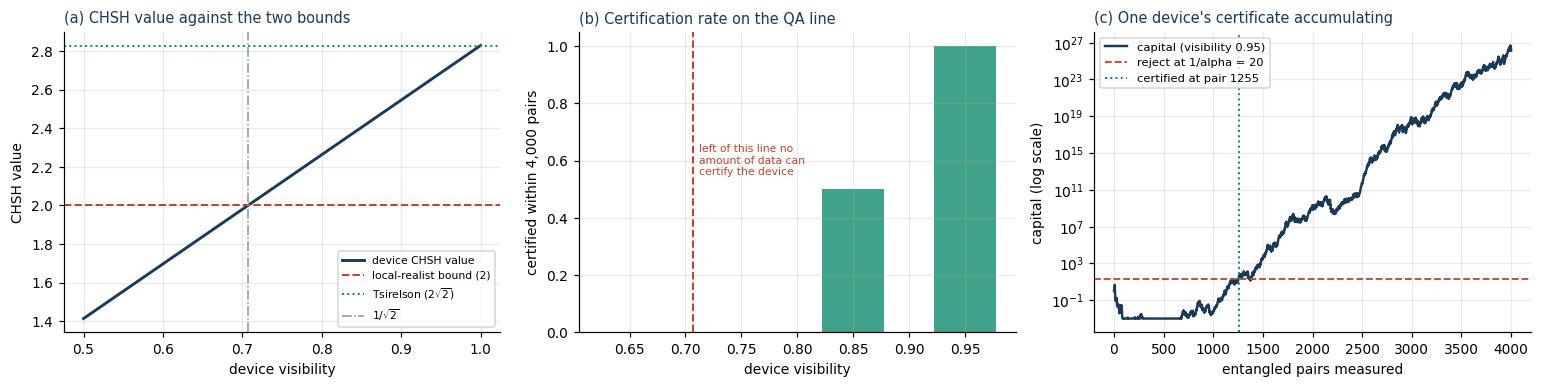

In [63]:
fig, ax = panels(3, ["CHSH value against the two bounds",
                     "Certification rate on the QA line",
                     "One device's certificate accumulating"], ncols=3)

vis_grid = np.linspace(0.5, 1.0, 80)
chsh_curve = [abs(CHSHLocalRealismNull.chsh_value(device_at(v))) for v in vis_grid]
ax[0].plot(vis_grid, chsh_curve, color=INK, lw=1.9, label="device CHSH value")
ax[0].axhline(2.0, color=WARN, ls="--", lw=1.3, label="local-realist bound (2)")
ax[0].axhline(2 * np.sqrt(2), color=EVID, ls=":", lw=1.3, label=r"Tsirelson ($2\sqrt{2}$)")
ax[0].axvline(1 / np.sqrt(2), color=MUTE, lw=1.0, ls="-.", label=r"$1/\sqrt{2}$")
ax[0].set_xlabel("device visibility"); ax[0].set_ylabel("CHSH value"); ax[0].legend(fontsize=7)

ax[1].bar(qrng_df.visibility, qrng_df.rate, width=0.055, color=EVID, alpha=0.8)
ax[1].axvline(1 / np.sqrt(2), color=WARN, ls="--", lw=1.3)
ax[1].text(0.712, 0.55, "left of this line no\namount of data can\ncertify the device",
           fontsize=7, color=WARN)
ax[1].set_xlabel("device visibility"); ax[1].set_ylabel("certified within 4,000 pairs")
ax[1].set_ylim(0, 1.05)

_, good = certify(0.95, 4242)
gh = good.get_history_df()
ax[2].semilogy(gh.step, np.maximum(gh.e_process_value, 1e-3), color=INK, lw=1.6,
               label="capital (visibility 0.95)")
ville(ax[2])
if good.stopping_time:
    ax[2].axvline(good.stopping_time, color=EVID, ls=":", lw=1.3,
                  label=f"certified at pair {good.stopping_time}")
ax[2].set_xlabel("entangled pairs measured"); ax[2].set_ylabel("capital (log scale)")
ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## 11.4 Conclusion and runbook

**Panel (a)** is the physics and the commercial constraint in one line: below visibility
$1/\sqrt{2}$ the device simply cannot violate the bound, so no measurement campaign will ever
certify it. **Panel (b)** confirms the statistics respect that - the certification rate
collapses at the same place. **Panel (c)** is the artefact QA keeps: a capital curve and a
pair count at which the certificate became valid.

1. Use `CHSHLocalRealismNull` when the null is "some hidden variable explains this" - it is
   the same `PolytopeNull` machinery as Section 9.11, with the 16 local-deterministic
   vertices supplied.
2. Certify on the **e-process stopping time**, not a fixed number of pairs. QA lines stop
   when they stop, and the certificate stays valid.
3. Check the physical feasibility bound *before* commissioning a measurement campaign. A
   device below $1/\sqrt{2}$ is an engineering problem, not a sampling problem, and no
   statistical method will rescue it.
4. The general lesson, which is why this sits in a commercial handbook: **when your null is
   "there exists some model in this class", you want a set-valued null.** Credit regimes
   (9.11), contaminated records (9.7) and hidden-variable models are the same mathematics.

---
# 12. The map: what to reach for, and what this handbook did not headline

## 12.1 Choosing a tool from the question

| The question the business is asking | Reach for | Shown in |
|---|---|---|
| How big is it? Give me a number I can book. | `confseq.ConfidenceSequence` | 1 |
| Is this rate above a published limit, and when did we know? | `SequentialTesting(PROPORTION)`, `boundaries.bernoulli_confidence_interval` | 2 |
| Which of my $k$ groups is different? | `ksample.KSampleSequentialTest` | 2 |
| The contract is written on a percentile, not a mean. | `modules.quantiletest`, `boundaries.double_stitching_bound` | 3 |
| Has volatility / dispersion broken a limit? | `martingales.GammaExponentialMixture` via `log_superMG(s, v)` | 4 |
| Counts, with exposure that changes every period. | `martingales.GammaPoissonMixture` + `protocol.BettingProtocol` | 5 |
| Paired comparison where the rating scale is not trustworthy. | `hypothesistesting.SymmetryETest` | 6 |
| I only get p-values from a vendor. | `calibrators.PToECalibrator` + `merging.ArithmeticMeanMerger` | 7 |
| How hard should I bet across a long programme? | `eprocessupdater` strategies + `epower.EPowerCalculator` | 8 |
| Is the model itself wrong? | `LikelihoodRatioEValue`, `UniversalEValue`, `stein`, `upperexp` | 9 |
| Thousands of streams, different decisions off the same data. | `par_seqtest` + `modules.adjusters` + `global_merge` | 10 |
| I need my own bespoke bet. | Subclass `protocol.SkepticStrategy` | 5 |

## 12.2 Capabilities this handbook used only in passing

These are fully implemented and have dedicated notebooks in `examples/`. They are listed
here so the map is complete, not because they are second-class.

| Capability | The question it owns | Where to go next |
|---|---|---|
| `merging.SparseMixtureMerger` | "A few of my thousands of streams are broken, but I do not know how many." Anytime-valid sparse-anomaly mixture with a posterior over sparsity. | `sparse-anomaly-global-null.ipynb` |
| The other four merging functions (`u_statistic`, `lambda_product`, `segment_product`, `product`) | Spatial merging under **stated** dependence contracts. Section 7 showed why the contract matters. | `global-merge-parallel-testing.ipynb` |
| `upperexp.WassersteinNull`, `WassersteinDistanceSequence` | "How far has reality drifted, at least, with a certificate?" An anytime-valid lower bound on $W_1$. | `imprecise-forecasters-upper-expectations.ipynb` |
| `upperexp.PolytopeNull`, `CHSHLocalRealismNull` | "Is this still a mixture of regimes we model?" - including ruling out every local-realist model at once. | `imprecise-forecasters-upper-expectations.ipynb` |
| `stein.WendlandSteinKernel` | Compactly supported Stein kernels: the Stein identity holds for every $C^1$ positive density with **no moment condition**. | `stein-score-only-goodness-of-fit.ipynb` |
| `ksample` effect-size restricted alternatives | "Is the difference bigger than $\delta$?" rather than "is there any difference?" | `ksample-bernoulli.ipynb` |
| `conformal.ConformalEValue`, `EfficiencyAnalyzer` | Conformal e-values and change-detection efficiency. **Experimental.** | `conformal-evalues.ipynb` |
| `utils.helper_functions` | Interactive Plotly dashboards from any `get_history_df()`. | `simple-demo.ipynb`, `savi-demo.ipynb` |

## 12.3 Things this handbook found, and you should know

Working through ten settings surfaced three facts that are not in any docstring:

1. **`SequentialTesting(test_type="variance")` rejects a true null essentially always**
   (Section 4). Its source carries an unresolved `TODO` and it is on the library's audit
   list. Use the `(s, v)` interface of `GammaExponentialMixture` instead. The mean,
   proportion and quantile paths pass their null checks.
2. **`ConfidenceSequenceConfig.boundary_type` is metadata on the `ConfidenceSequence` path**
   (Section 1): the gamma-exponential mixture bound is always what runs. We reproduced it
   exactly from `modules.boundaries` rather than trusting the field name.
3. **`SequentialTesting(TestType.QUANTILE)` does not populate `result.sample_size`**
   (Section 3); read `len(test.all_data)`. And "the quantile is **below** the threshold" is
   `AlternativeType.GREATER`, because the test bets on the proportion below it.
4. **`EmpiricalBernsteinConfidenceSequence` returns an unusable interval** (Section 1.8):
   on data bounded in $[0, 10]$ with a true mean of 7.0 it reported `[68.7, 10.0]` - lower
   above upper and outside the declared support. The accumulated state is correct; the
   bounds are rescaled by the support width on the way out. Use `ConfidenceSequence` with
   your bounded data until this is repaired.
5. **`utils.plot_sequential_comparison_plotly` raises `TypeError` for every input**
   (Section 2.9): at `helper_functions.py:877` the local `colors` has been rebound from the
   palette dict to a per-series list and is then indexed as `colors["grid"]`.
   `plot_sequential_test_plotly`, `plot_combined_dashboard` and `plot_ksample_dashboard`
   are unaffected.

Each of these was found by pointing the tool at a case whose answer was already known. None
of them announce themselves; three of the five produce confident, plausible-looking output.

`expectation.parametric` (Wang & Ramdas $t$-test kernels) is present but incomplete -
`TestType.TTEST` is missing and its confidence-sequence class fails positional
initialisation. It is not exercised here and should not be enabled in production until
repaired.

## 12.4 The five habits

Everything in this handbook reduces to five things, in order of how often they save you:

1. **Fix the null class, filtration, clock and downstream use before writing code.** Most
   production failures are a wrong entry in that table, not a bug.
2. **Run every test against a true null before trusting a detection.** It takes ten seconds
   and it found a real defect in Section 4.
3. **Replicate.** One seed is one draw. Report a detection rate and a median stopping time,
   and ship the operating-characteristic ladder next to the monitor.
4. **Optimise growth rate, never the expected e-value.** Capital is a product (Sections 6
   and 8).
5. **Match the error-control rule to the reversibility of the decision.** Cheap and
   reversible gets the generous rule; contractual and permanent gets the carefree one
   (Section 10).

And the one-line version of the whole library:

> **Bet against the null. If you get rich, the null was wrong. You may stop whenever you
> like, and that is the entire point.**